# Soft-Decision DPO — Wave 1 Experiments

**Branch**: `soft_decision`  
**Method**: Correct Berthet et al. DPO with soft decisions (z̄ = E[z(θ̂+σε)])  
**Grid**: 8 problems × 3σ × 3lr = **72 experiments**

| Hyperparameter | Values |
|---|---|
| σ (sigma) | 0.05, 0.1, 0.5 |
| lr | 1e-3, 5e-3, 1e-2 |
| n_samples | 25 (fixed) |
| noise | normal (fixed) |
| epochs | 300 (150 for advertising) |

**Problems**: portfolio, knapsack-gen, knapsack-energy, bipartitematching, budgetalloc, cubic, energy, advertising

In [1]:
import os, subprocess, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we run from the project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
os.chdir(PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

# ── Experiment registry ──────────────────────────────────────────────
# Prefix convention: sd1_s{sigma_tag}_{lr_tag}
# saved_records/<data_name>/perturb/<prefix>/log.txt

SIGMAS = {"005": 0.05, "01": 0.1, "05": 0.5}
LRS = {"lr1e3": 1e-3, "lr5e3": 5e-3, "lr1e2": 1e-2}

PROBLEMS = {
    "portfolio":         {"data_name": "portfolio-real",         "solver": "cvxpy",     "epochs": 300},
    "knapsack":          {"data_name": "knapsack-gen",           "solver": "gurobi",    "epochs": 300},
    "knapsack_energy":   {"data_name": "knapsack-energy",        "solver": "gurobi",    "epochs": 300},
    "bipartitematching": {"data_name": "bipartitematching-cora", "solver": "cvxpy",     "epochs": 300},
    "budgetalloc":       {"data_name": "budgetalloc-real",       "solver": "neural",    "epochs": 300},
    "cubic":             {"data_name": "cubic-gen",              "solver": "heuristic", "epochs": 300},
    "energy":            {"data_name": "energy-energy",          "solver": "gurobi",    "epochs": 300},
    "advertising":       {"data_name": "advertising-real",       "solver": "ortools",   "epochs": 150},
}

# Build full experiment registry
EXPERIMENTS = {}
for prob_key, prob_info in PROBLEMS.items():
    for sigma_tag, sigma_val in SIGMAS.items():
        for lr_tag, lr_val in LRS.items():
            prefix = f"sd1_s{sigma_tag}_{lr_tag}"
            exp_key = f"{prob_key}_s{sigma_tag}_{lr_tag}"
            EXPERIMENTS[exp_key] = {
                "data_name": prob_info["data_name"],
                "prefix": prefix,
                "sigma": sigma_val,
                "lr": lr_val,
                "problem": prob_key,
                "sigma_tag": sigma_tag,
                "lr_tag": lr_tag,
            }

print(f"Registered {len(EXPERIMENTS)} experiments across {len(PROBLEMS)} problems")
print(f"Grid: {len(SIGMAS)} sigmas × {len(LRS)} LRs = {len(SIGMAS)*len(LRS)} configs per problem")

Working directory: /cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark
Registered 72 experiments across 8 problems
Grid: 3 sigmas × 3 LRs = 9 configs per problem


## Launch Jobs

In [2]:
# Dry run first — inspect what would be submitted
!bash shells/slurm/submit_softdec_wave1.sh --dry-run 2>&1 | head -30
print("...")
!bash shells/slurm/submit_softdec_wave1.sh --dry-run 2>&1 | tail -10

Wave 1 — Soft-Decision DPO
Grid: 8 problems × 3σ × 3lr = 72 experiments
Primary:  preempt
Backup:   hugheslab,gpu (afternotok dependency)
Time: 24:00:00  Mem: 16G  GRES: gpu:1
*** DRY RUN MODE ***
Skip completed: ON
Total experiments: 72

[SKIP] pco_portfolio_sd1_s005_lr1e3 — already completed
[SKIP] pco_portfolio_sd1_s005_lr5e3 — already completed
[SKIP] pco_portfolio_sd1_s005_lr1e2 — already completed
[SKIP] pco_portfolio_sd1_s01_lr1e3 — already completed
[SKIP] pco_portfolio_sd1_s01_lr5e3 — already completed
[SKIP] pco_portfolio_sd1_s01_lr1e2 — already completed
[SKIP] pco_portfolio_sd1_s05_lr1e3 — already completed
[SKIP] pco_portfolio_sd1_s05_lr5e3 — already completed
[SKIP] pco_portfolio_sd1_s05_lr1e2 — already completed
[SKIP] pco_knapsack_sd1_s005_lr1e3 — already completed
[SKIP] pco_knapsack_sd1_s005_lr5e3 — already completed
[SKIP] pco_knapsack_sd1_s005_lr1e2 — already completed
[SKIP] pco_knapsack_sd1_s01_lr1e3 — already completed
[SKIP] pco_knapsack_sd1_s01_lr5e3 — already 

...
[SKIP] pco_advertising_sd1_s05_lr5e3 — already completed
[SKIP] pco_advertising_sd1_s05_lr1e2 — already completed

Submitted: 9 experiments
  → 9 primary (preempt) + 9 backup (hugheslab,gpu)
  → Total SLURM jobs: 18
Skipped (completed): 63

Dry run complete. No jobs submitted.


In [3]:
# Submit to preempt with hugheslab,gpu backup
# Uncomment to actually submit:
# !bash shells/slurm/submit_softdec_wave1.sh

In [4]:
# Check job status
!squeue -u $USER --format="%.18i %.30j %.8T %.10M %.6D %R" | head -40

             JOBID                           NAME    STATE       TIME  NODES NODELIST(REASON)
          32296070                   vscode.slurm  RUNNING       4:49      1 d1cmp019
          32249237 pco_knapsack_sd1_kn_w5_sig_s00  PENDING       0:00      1 (Dependency)
          32249235 pco_knapsack_sd1_kn_w5_sig_s00  PENDING       0:00      1 (Dependency)
          32249233 pco_knapsack_sd1_kn_w5_sig_s00  PENDING       0:00      1 (Dependency)
          32249231 pco_knapsack_sd1_kn_w5_sig_s01  PENDING       0:00      1 (Dependency)
          32249229 pco_knapsack_sd1_kn_w5_sig_s01  PENDING       0:00      1 (Dependency)
          32249223 pco_knapsack_sd1_kn_w5_sig_s05  PENDING       0:00      1 (Dependency)
          32249219 pco_knapsack_sd1_kn_w5_sig_s10  PENDING       0:00      1 (Priority)
          32249216 pco_knapsack_sd1_kn_w5_sig_s10  PENDING       0:00      1 (Priority)
          32249214 pco_knapsack_sd1_kn_w5_sig_s10  PENDING       0:00      1 (Priority)
          322492

## Collect Results

Read `log.txt` from each experiment's `saved_records/` directory.  
Format: `objective  regret  train_time  test_time` (last line of log.txt)

In [5]:
def read_result(data_name, prefix, model="perturb"):
    """Read final results from log.txt.  Returns dict or None."""
    log_path = os.path.join("saved_records", data_name, model, prefix, "log.txt")
    if not os.path.exists(log_path):
        return None
    with open(log_path, "r") as f:
        lines = f.readlines()
    if not lines:
        return None
    last = lines[-1].strip()
    parts = last.split()
    try:
        vals = [float(x) for x in parts[-4:]]
        return {"objective": vals[0], "regret": vals[1], "train_time": vals[2], "test_time": vals[3]}
    except (ValueError, IndexError):
        return None

# Collect all results
rows = []
for exp_key, exp in EXPERIMENTS.items():
    result = read_result(exp["data_name"], exp["prefix"])
    row = {
        "experiment": exp_key,
        "problem": exp["problem"],
        "sigma": exp["sigma"],
        "lr": exp["lr"],
        "prefix": exp["prefix"],
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    rows.append(row)

df = pd.DataFrame(rows)
done = df[df["status"] == "done"]
pending = df[df["status"] == "pending"]
print(f"Completed: {len(done)}/{len(df)} experiments")
print(f"Pending:   {len(pending)}/{len(df)}")
if len(pending) > 0:
    print("\nPending experiments:")
    for _, r in pending.iterrows():
        print(f"  {r['problem']:20s}  σ={r['sigma']:<6}  lr={r['lr']}")
print()

Completed: 63/72 experiments
Pending:   9/72

Pending experiments:
  budgetalloc           σ=0.1     lr=0.001
  budgetalloc           σ=0.1     lr=0.005
  budgetalloc           σ=0.1     lr=0.01
  energy                σ=0.05    lr=0.001
  energy                σ=0.05    lr=0.005
  energy                σ=0.05    lr=0.01
  energy                σ=0.1     lr=0.001
  energy                σ=0.1     lr=0.01
  energy                σ=0.5     lr=0.001



## Results Table — Best per Problem

For each problem, show the best (σ, lr) combo by test regret.

In [6]:
if len(done) > 0:
    # Pivot table: rows = (sigma, lr), columns = problem, values = regret
    pivot = done.pivot_table(
        index=["sigma", "lr"], columns="problem", values="regret", aggfunc="first"
    )
    print("Full Grid — Test Regret")
    print("=" * 120)
    print(pivot.to_string())
    print()

    # Best per problem
    best_rows = []
    for prob in PROBLEMS:
        prob_done = done[done["problem"] == prob]
        if len(prob_done) == 0:
            best_rows.append({"problem": prob, "best_regret": None, "sigma": None, "lr": None})
            continue
        best_idx = prob_done["regret"].idxmin()
        best = prob_done.loc[best_idx]
        best_rows.append({
            "problem": prob,
            "best_regret": best["regret"],
            "sigma": best["sigma"],
            "lr": best["lr"],
            "objective": best["objective"],
        })
    best_df = pd.DataFrame(best_rows)
    print("\nBest per Problem")
    print("=" * 80)
    print(best_df.to_string(index=False))
else:
    print("No results yet — jobs still running.")

Full Grid — Test Regret
problem        advertising  bipartitematching  budgetalloc   cubic     energy  knapsack  knapsack_energy  portfolio
sigma  lr                                                                                                          
0.0500 0.0010       0.0320            38.7037       0.0075  1.5383        NaN    9.9750          77.1483     0.3593
       0.0050       0.0353            38.2710       0.0038  1.5586        NaN    8.0900          87.8854     0.3514
       0.0100       0.0347            38.2743       0.0076  1.5538        NaN    7.9950          78.2792     0.3650
0.1000 0.0010       0.0356            38.4730          NaN  1.5433        NaN    8.7500          79.1233     0.3621
       0.0050       0.0109            37.2410          NaN  1.5310 81587.1487    5.8000          78.7782     0.3849
       0.0100       0.0347            38.0575          NaN  1.5849        NaN    7.4550          70.2485     0.4270
0.5000 0.0010       0.0316            38.2089   

## Heatmaps — σ vs LR for each problem

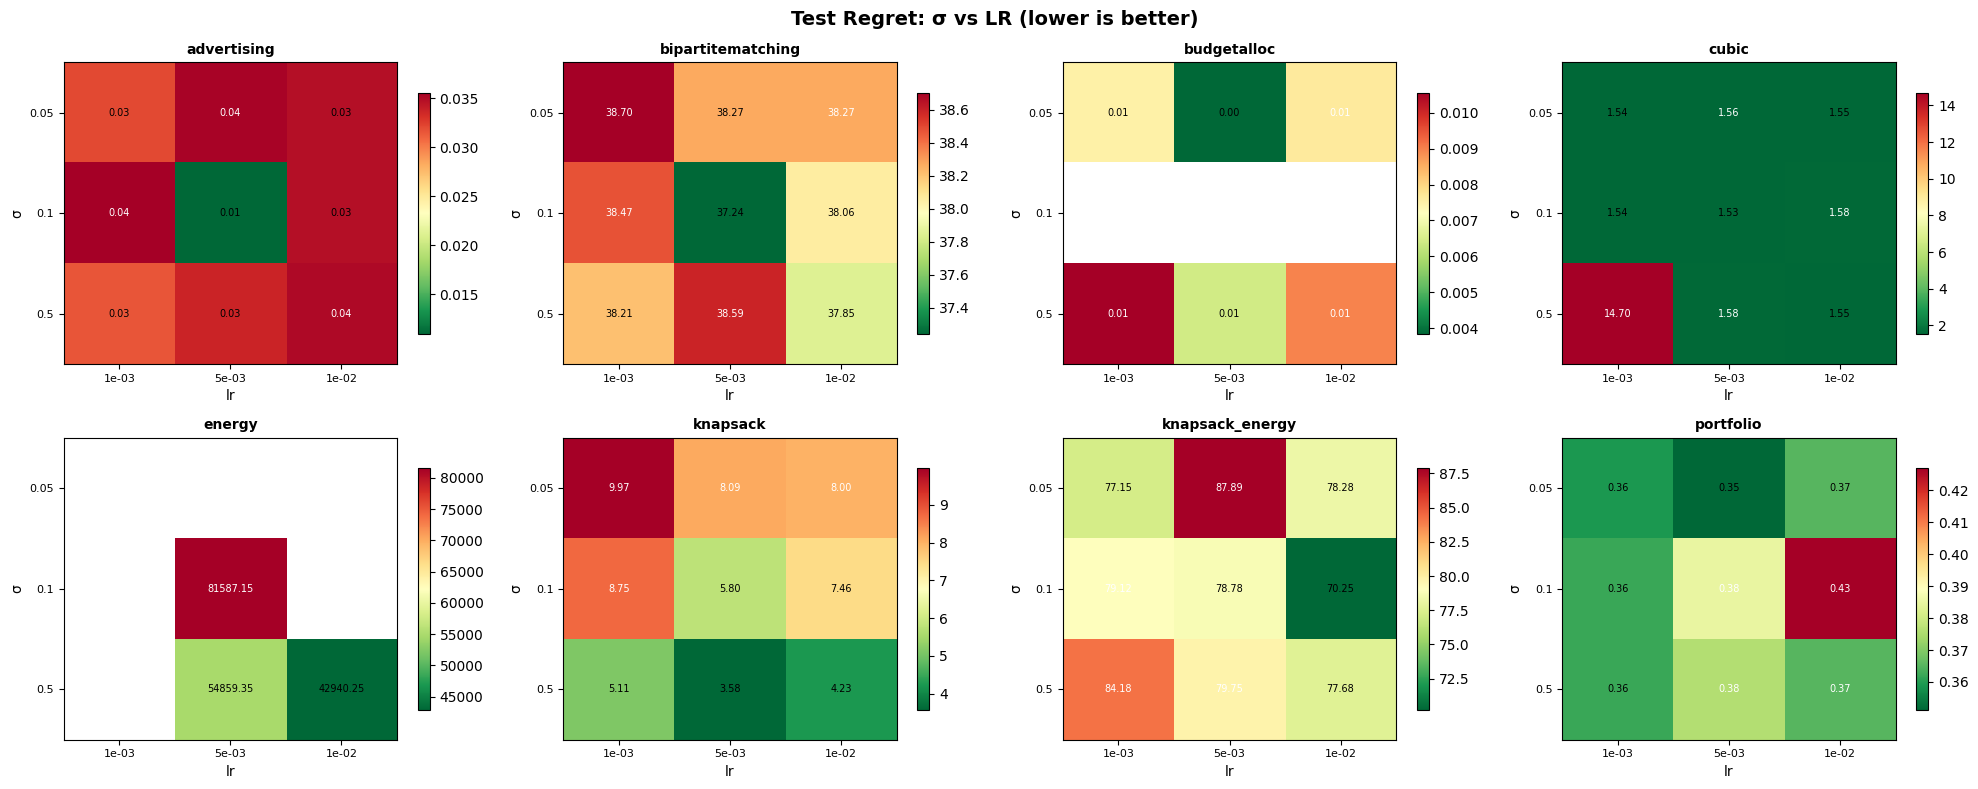

In [7]:
if len(done) > 0:
    prob_list = sorted(PROBLEMS.keys())
    n_probs = len(prob_list)
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.flatten()

    sigma_vals = sorted(SIGMAS.values())
    lr_vals = sorted(LRS.values())

    for i, prob in enumerate(prob_list):
        ax = axes[i]
        prob_data = done[done["problem"] == prob]
        if len(prob_data) == 0:
            ax.set_title(f"{prob}\n(no data)")
            ax.axis("off")
            continue

        # Build heatmap matrix
        heat = np.full((len(sigma_vals), len(lr_vals)), np.nan)
        for _, row in prob_data.iterrows():
            si = sigma_vals.index(row["sigma"])
            li = lr_vals.index(row["lr"])
            heat[si, li] = row["regret"]

        im = ax.imshow(heat, cmap="RdYlGn_r", aspect="auto")
        ax.set_xticks(range(len(lr_vals)))
        ax.set_xticklabels([f"{v:.0e}" for v in lr_vals], fontsize=8)
        ax.set_yticks(range(len(sigma_vals)))
        ax.set_yticklabels([str(v) for v in sigma_vals], fontsize=8)
        ax.set_xlabel("lr")
        ax.set_ylabel("σ")
        ax.set_title(prob, fontsize=10, fontweight="bold")

        # Annotate cells
        for si in range(len(sigma_vals)):
            for li in range(len(lr_vals)):
                val = heat[si, li]
                if not np.isnan(val):
                    ax.text(li, si, f"{val:.2f}", ha="center", va="center", fontsize=7,
                            color="white" if val > np.nanmedian(heat) else "black")

        fig.colorbar(im, ax=ax, shrink=0.8)

    # Hide unused axes
    for i in range(n_probs, len(axes)):
        axes[i].axis("off")

    fig.suptitle("Test Regret: σ vs LR (lower is better)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No results yet.")

## Training Loss Traces

Plot training loss (and optionally objective) over epochs for a given problem.

**Flags**:
- `PROBLEM`: which problem to plot (e.g. `"portfolio"`)
- `MODE`: `"best"` (single best val regret), `"topk"` (top K), or `"all"` (all 9 configs)
- `K`: how many traces for `"topk"` mode (default 3)
- `SHOW_OBJECTIVE`: overlay the train objective on the same axes to verify loss ≈ objective

knapsack: found 9/9 completed traces


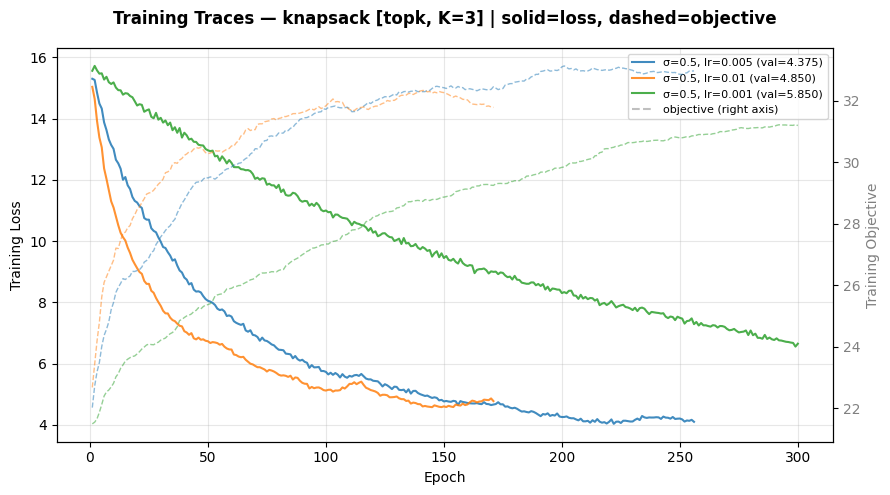


Ranking by best validation regret (knapsack):
  1. σ=0.5, lr=0.005       val_regret=4.3750 ◀
  2. σ=0.5, lr=0.01        val_regret=4.8500 ◀
  3. σ=0.5, lr=0.001       val_regret=5.8500 ◀
  4. σ=0.1, lr=0.005       val_regret=6.6125
  5. σ=0.1, lr=0.01        val_regret=8.3500
  6. σ=0.05, lr=0.005      val_regret=9.2500
  7. σ=0.1, lr=0.001       val_regret=9.2875
  8. σ=0.05, lr=0.01       val_regret=9.5000
  9. σ=0.05, lr=0.001      val_regret=10.3125


In [94]:
# ── Configuration flags ────────────────────────────────────────────────
PROBLEM = "knapsack"        # which problem to plot
MODE = "topk"                # "best", "topk", or "all"
K = 3                        # number of traces for "topk" mode
SHOW_OBJECTIVE = True        # overlay train objective on same axes

# ── Helper: read training traces from CSV or log.txt ──────────────────

def read_traces(data_name, prefix, model="perturb"):
    """Return (train_df, val_df) with columns [epoch, obj, loss, pred_loss, eval].
    Tries CSV first, falls back to parsing log.txt. Returns (None, None) if unavailable."""
    base = os.path.join("saved_records", data_name, model, prefix)
    train_csv = os.path.join(base, "train_logs.csv")
    val_csv = os.path.join(base, "val_logs.csv")

    if os.path.exists(train_csv) and os.path.exists(val_csv):
        try:
            tdf = pd.read_csv(train_csv)
            vdf = pd.read_csv(val_csv)
            # Parse epoch number from "Tr-1" / "Val-1" format
            tdf["epoch_num"] = tdf["epoch"].str.extract(r"(\d+)").astype(int)
            vdf["epoch_num"] = vdf["epoch"].str.extract(r"(\d+)").astype(int)
            return tdf, vdf
        except Exception:
            pass

    # Fallback: parse log.txt
    log_path = os.path.join(base, "log.txt")
    if not os.path.exists(log_path):
        return None, None

    train_rows, val_rows = [], []
    pattern = re.compile(
        r"Iter\s+(\d+),\s+(train|val)\s+Objective:\s+([\d.eE+-]+),\s+"
        r"Loss:\s+([\d.eE+-]+)\s+Pred Loss:\s+([\d.eE+-]+),\s+"
        r"(?:regret|uplift):\s+([\d.eE+-]+)"
    )
    with open(log_path) as f:
        for line in f:
            m = pattern.search(line)
            if m:
                epoch_num = int(m.group(1))
                split = m.group(2)
                row = {
                    "epoch_num": epoch_num,
                    "obj": float(m.group(3)),
                    "loss": float(m.group(4)),
                    "pred_loss": float(m.group(5)),
                    "eval": float(m.group(6)),
                }
                if split == "train":
                    train_rows.append(row)
                else:
                    val_rows.append(row)

    if not train_rows and not val_rows:
        return None, None
    tdf = pd.DataFrame(train_rows) if train_rows else None
    vdf = pd.DataFrame(val_rows) if val_rows else None
    return tdf, vdf


def get_best_val_regret(val_df):
    """Return the minimum validation regret (eval or regret column)."""
    if val_df is None or len(val_df) == 0:
        return float("inf")
    if "regret" in val_df.columns:
        return val_df["regret"].min()
    return val_df["eval"].min()


# ── Collect traces for the selected problem ───────────────────────────

prob_info = PROBLEMS[PROBLEM]
traces = []
for sigma_tag, sigma_val in SIGMAS.items():
    for lr_tag, lr_val in LRS.items():
        prefix = f"sd1_s{sigma_tag}_{lr_tag}"
        tdf, vdf = read_traces(prob_info["data_name"], prefix)
        if tdf is not None:
            best_val = get_best_val_regret(vdf)
            label = f"σ={sigma_val}, lr={lr_val}"
            traces.append({
                "label": label, "sigma": sigma_val, "lr": lr_val,
                "train": tdf, "val": vdf, "best_val_regret": best_val,
            })

print(f"{PROBLEM}: found {len(traces)}/9 completed traces")

if len(traces) == 0:
    print("No training data available yet.")
else:
    # Sort by best val regret (ascending = best first)
    traces.sort(key=lambda t: t["best_val_regret"])

    # Select traces based on MODE
    if MODE == "best":
        selected = traces[:1]
    elif MODE == "topk":
        selected = traces[:K]
    else:  # "all"
        selected = traces

    # ── Plot ───────────────────────────────────────────────────────────
    fig, ax_loss = plt.subplots(1, 1, figsize=(9, 5))

    cmap = plt.cm.tab10
    colors = [cmap(i) for i in range(len(selected))]

    # --- Training Loss (left y-axis) ---
    for i, tr in enumerate(selected):
        tdf = tr["train"]
        ax_loss.plot(tdf["epoch_num"], tdf["loss"],
                     label=f'{tr["label"]} (val={tr["best_val_regret"]:.3f})',
                     color=colors[i], alpha=0.85, linewidth=1.5)
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Training Loss", color="black")
    ax_loss.grid(True, alpha=0.3)

    # --- Training Objective on secondary y-axis (if requested) ---
    if SHOW_OBJECTIVE:
        ax_obj = ax_loss.twinx()
        for i, tr in enumerate(selected):
            tdf = tr["train"]
            ax_obj.plot(tdf["epoch_num"], tdf["obj"],
                        color=colors[i], alpha=0.5, linewidth=1,
                        linestyle="--")
        ax_obj.set_ylabel("Training Objective", color="gray")
        ax_obj.tick_params(axis="y", labelcolor="gray")
        # Add a proxy legend entry for the dashed style
        ax_loss.plot([], [], color="gray", linestyle="--", alpha=0.5,
                     label="objective (right axis)")

    ax_loss.legend(fontsize=8, loc="upper right")
    fig.suptitle(
        f"Training Traces — {PROBLEM} [{MODE}" + (f", K={K}" if MODE == "topk" else "") + "]"
        + (" | solid=loss, dashed=objective" if SHOW_OBJECTIVE else ""),
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # Print ranking summary
    print(f"\nRanking by best validation regret ({PROBLEM}):")
    for i, tr in enumerate(traces):
        marker = " ◀" if tr in selected else ""
        print(f"  {i+1}. {tr['label']:20s}  val_regret={tr['best_val_regret']:.4f}{marker}")

## Check SLURM Logs for Errors

In [9]:
# Scan SLURM error logs for failures
import glob

err_files = sorted(glob.glob("logs/slurm/pco_*sd1*.err"))
print(f"Found {len(err_files)} error log files")

errors_found = 0
for f in err_files:
    with open(f) as fh:
        content = fh.read()
    if "Error" in content or "Traceback" in content or "CANCELLED" in content:
        errors_found += 1
        basename = os.path.basename(f)
        # Show last 5 lines
        lines = content.strip().split("\n")
        print(f"\n{'='*60}")
        print(f"ERROR in {basename}:")
        for line in lines[-5:]:
            print(f"  {line}")

if errors_found == 0:
    print("No errors found in SLURM logs.")

Found 408 error log files

ERROR in pco_advertising_sd1_s005_lr1e2_31506306.err:
               ^^^^^^^^^^^^^
    File "/cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark/openpto/method/Models/perturbed.py", line 327, in forward
      regret = torch.abs(obj - obj_star)
                         ~~~~^~~~~~~~~~
  RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

ERROR in pco_advertising_sd1_s005_lr1e3_31506302.err:
               ^^^^^^^^^^^^^
    File "/cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark/openpto/method/Models/perturbed.py", line 327, in forward
      regret = torch.abs(obj - obj_star)
                         ~~~~^~~~~~~~~~
  RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

ERROR in pco_advertising_sd1_s005_lr5e3_31506304.err:
               ^^^^^^^^^^^^^
    File "/cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark/openpt


ERROR in pco_advertising_sd1_s01_lr1e2_31506312.err:
               ^^^^^^^^^^^^^
    File "/cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark/openpto/method/Models/perturbed.py", line 327, in forward
      regret = torch.abs(obj - obj_star)
                         ~~~~^~~~~~~~~~
  RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

ERROR in pco_advertising_sd1_s01_lr1e3_31506308.err:
               ^^^^^^^^^^^^^
    File "/cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark/openpto/method/Models/perturbed.py", line 327, in forward
      regret = torch.abs(obj - obj_star)
                         ~~~~^~~~~~~~~~
  RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

ERROR in pco_advertising_sd1_s01_lr5e3_31506310.err:
               ^^^^^^^^^^^^^
    File "/cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark/openpto/method/Models/perturbed.py"

---

# Wave 2 — Portfolio Sigma Annealing

**Goal**: Close the soft-to-hard decision gap by annealing σ from a large initial value
(good gradient signal) down to a small value (z̄ ≈ z(θ̂)).

| Hyperparameter | Values |
|---|---|
| Schedule | linear_decay |
| σ start → end | 0.5→0.05, 0.5→0.01, 0.1→0.01, 0.1→0.005, 0.3→0.01 |
| Warmup | 0, 20, 50 epochs |
| lr | 1e-3, 5e-3 |
| n_samples | 5 |
| n_epochs | 400 |
| patience | 80 |

**5 ranges × 3 warmups × 2 LRs = 30 experiments**

In [10]:
# ── Wave 2 Registry ──────────────────────────────────────────────────
W2_RANGES = {
    "s05to005":  (0.5, 0.05),
    "s05to001":  (0.5, 0.01),
    "s01to001":  (0.1, 0.01),
    "s01to0005": (0.1, 0.005),
    "s03to001":  (0.3, 0.01),
}
W2_WARMUPS = [0, 20, 50]
W2_LRS = {"lr1e3": 1e-3, "lr5e3": 5e-3}

W2_EXPERIMENTS = {}
for range_tag, (s_start, s_end) in W2_RANGES.items():
    for warmup in W2_WARMUPS:
        for lr_tag, lr_val in W2_LRS.items():
            prefix = f"sd1_lin_{range_tag}_w{warmup}_{lr_tag}"
            exp_key = f"w2_{range_tag}_w{warmup}_{lr_tag}"
            W2_EXPERIMENTS[exp_key] = {
                "data_name": "portfolio-real",
                "prefix": prefix,
                "sigma_start": s_start,
                "sigma_end": s_end,
                "warmup": warmup,
                "lr": lr_val,
                "range_tag": range_tag,
                "lr_tag": lr_tag,
            }

print(f"Wave 2: registered {len(W2_EXPERIMENTS)} experiments")
print(f"Grid: {len(W2_RANGES)} ranges × {len(W2_WARMUPS)} warmups × {len(W2_LRS)} LRs")

Wave 2: registered 30 experiments
Grid: 5 ranges × 3 warmups × 2 LRs


### Wave 2: Launch & Status

In [11]:
# Dry run
!bash shells/slurm/submit_portfolio_wave2.sh --dry-run 2>&1 | head -15
print("...")
!bash shells/slurm/submit_portfolio_wave2.sh --dry-run 2>&1 | tail -8

Wave 2 — Portfolio Sigma Annealing
Grid: 5 ranges × 3 warmups × 2 LRs = 30 experiments
Schedule: linear_decay, n_samples=5, n_epochs=400, patience=80
Primary:  preempt
Backup:   hugheslab,gpu (afternotok dependency)
Time: 24:00:00  Mem: 16G  GRES: gpu:1
*** DRY RUN MODE ***
Skip completed: ON
Total experiments: 30

[SKIP] pco_portfolio_sd1_lin_s05to005_w0_lr1e3 — already completed
[SKIP] pco_portfolio_sd1_lin_s05to005_w0_lr5e3 — already completed
...

Submitted: 0 experiments
  → 0 primary (preempt) + 0 backup (hugheslab,gpu)
  → Total SLURM jobs: 0
Skipped (completed): 30

Dry run complete. No jobs submitted.


In [12]:
# Submit (uncomment to run):
# !bash shells/slurm/submit_portfolio_wave2.sh

In [13]:
# Job status
!squeue -u $USER --format="%.18i %.30j %.8T %.10M %.6D %R" | grep -E "pco_portfolio|JOBID" | head -40

             JOBID                           NAME    STATE       TIME  NODES NODELIST(REASON)


### Wave 2: Collect Results

In [14]:
# Collect Wave 2 results
w2_rows = []
for exp_key, exp in W2_EXPERIMENTS.items():
    result = read_result(exp["data_name"], exp["prefix"])
    row = {
        "experiment": exp_key,
        "prefix": exp["prefix"],
        "sigma_start": exp["sigma_start"],
        "sigma_end": exp["sigma_end"],
        "warmup": exp["warmup"],
        "lr": exp["lr"],
        "range_tag": exp["range_tag"],
        "lr_tag": exp["lr_tag"],
        "range_label": f"{exp['sigma_start']}→{exp['sigma_end']}",
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    w2_rows.append(row)

w2_df = pd.DataFrame(w2_rows)
w2_done = w2_df[w2_df["status"] == "done"]
w2_pending = w2_df[w2_df["status"] == "pending"]
print(f"Wave 2 — Completed: {len(w2_done)}/{len(w2_df)} experiments")
if len(w2_pending) > 0:
    print(f"Pending: {len(w2_pending)}")
    for _, r in w2_pending.head(10).iterrows():
        print(f"  {r['range_label']:12s}  w={r['warmup']:<4}  lr={r['lr']}")
    if len(w2_pending) > 10:
        print(f"  ... and {len(w2_pending)-10} more")

Wave 2 — Completed: 30/30 experiments


### Wave 2: Results Table — Pivot by Range × Warmup × LR

In [15]:
if len(w2_done) > 0:
    # Pivot: rows = (range, warmup), columns = lr, values = regret
    pivot_w2 = w2_done.pivot_table(
        index=["range_label", "warmup"], columns="lr", values="regret", aggfunc="first"
    )
    print("Wave 2 — Test Regret by (Range, Warmup, LR)")
    print("=" * 80)
    print(pivot_w2.to_string())

    # Best overall
    best_idx = w2_done["regret"].idxmin()
    best = w2_done.loc[best_idx]
    print(f"\n★ Best Wave 2: {best['range_label']} w={int(best['warmup'])} "
          f"lr={best['lr']} → regret={best['regret']:.4f}")

    # Compare to Wave 1 portfolio best
    w1_port = done[done["problem"] == "portfolio"] if len(done) > 0 else pd.DataFrame()
    if len(w1_port) > 0:
        w1_best = w1_port.loc[w1_port["regret"].idxmin()]
        print(f"  Wave 1 best: σ={w1_best['sigma']} lr={w1_best['lr']} "
              f"→ regret={w1_best['regret']:.4f}")
        improvement = (w1_best["regret"] - best["regret"]) / w1_best["regret"] * 100
        print(f"  Improvement: {improvement:+.1f}%")
else:
    print("No Wave 2 results yet — jobs still running.")

Wave 2 — Test Regret by (Range, Warmup, LR)
lr                  0.0010  0.0050
range_label warmup                
0.1→0.005   0       0.3326  0.3309
            20      0.3603  0.3612
            50      0.3603  0.3364
0.1→0.01    0       0.3604  0.3188
            20      0.3603  0.3395
            50      0.3603  0.3364
0.3→0.01    0       0.3397  0.4148
            20      0.3542  0.3532
            50      0.3737  0.3532
0.5→0.01    0       0.3664  0.4134
            20      0.3664  0.3664
            50      0.3664  0.3664
0.5→0.05    0       0.3664  0.3664
            20      0.3664  0.3664
            50      0.3664  0.3664

★ Best Wave 2: 0.1→0.01 w=0 lr=0.005 → regret=0.3188
  Wave 1 best: σ=0.05 lr=0.005 → regret=0.3514
  Improvement: +9.3%


### Wave 2: Heatmaps — Range vs Warmup (one per LR)

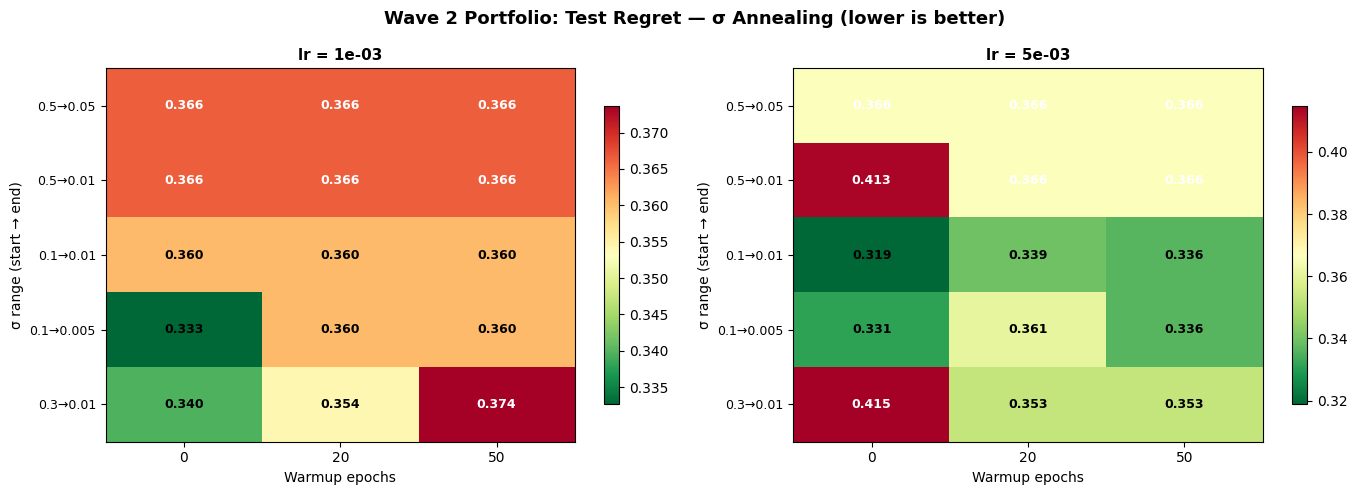


Wave 1 portfolio best regret: 0.3514
Wave 2 portfolio best regret: 0.3188


In [16]:
if len(w2_done) > 0:
    range_labels = [f"{s}→{e}" for _, (s, e) in W2_RANGES.items()]
    warmup_vals = W2_WARMUPS
    lr_vals_w2 = sorted(W2_LRS.values())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for li, lr_val in enumerate(lr_vals_w2):
        ax = axes[li]
        lr_data = w2_done[w2_done["lr"] == lr_val]

        heat = np.full((len(range_labels), len(warmup_vals)), np.nan)
        for _, row in lr_data.iterrows():
            ri = range_labels.index(row["range_label"])
            wi = warmup_vals.index(row["warmup"])
            heat[ri, wi] = row["regret"]

        im = ax.imshow(heat, cmap="RdYlGn_r", aspect="auto")
        ax.set_xticks(range(len(warmup_vals)))
        ax.set_xticklabels([str(w) for w in warmup_vals])
        ax.set_yticks(range(len(range_labels)))
        ax.set_yticklabels(range_labels, fontsize=9)
        ax.set_xlabel("Warmup epochs")
        ax.set_ylabel("σ range (start → end)")
        ax.set_title(f"lr = {lr_val:.0e}", fontsize=11, fontweight="bold")

        for ri in range(len(range_labels)):
            for wi in range(len(warmup_vals)):
                val = heat[ri, wi]
                if not np.isnan(val):
                    ax.text(wi, ri, f"{val:.3f}", ha="center", va="center",
                            fontsize=9, fontweight="bold",
                            color="white" if val > np.nanmedian(heat) else "black")

        fig.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle("Wave 2 Portfolio: Test Regret — σ Annealing (lower is better)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Also show Wave 1 portfolio baseline for reference
    if len(w1_port) > 0:
        print(f"\nWave 1 portfolio best regret: {w1_port['regret'].min():.4f}")
        print(f"Wave 2 portfolio best regret: {w2_done['regret'].min():.4f}")
else:
    print("No Wave 2 results yet.")

### Wave 2: Training Traces — Annealing vs Constant σ

Compare the best Wave 2 annealing configs against the best Wave 1 constant-σ portfolio configs.
Shows whether annealing prevents the objective from degrading over training.

Wave 1 portfolio: 9/9 traces
Wave 2 portfolio: 30/30 traces


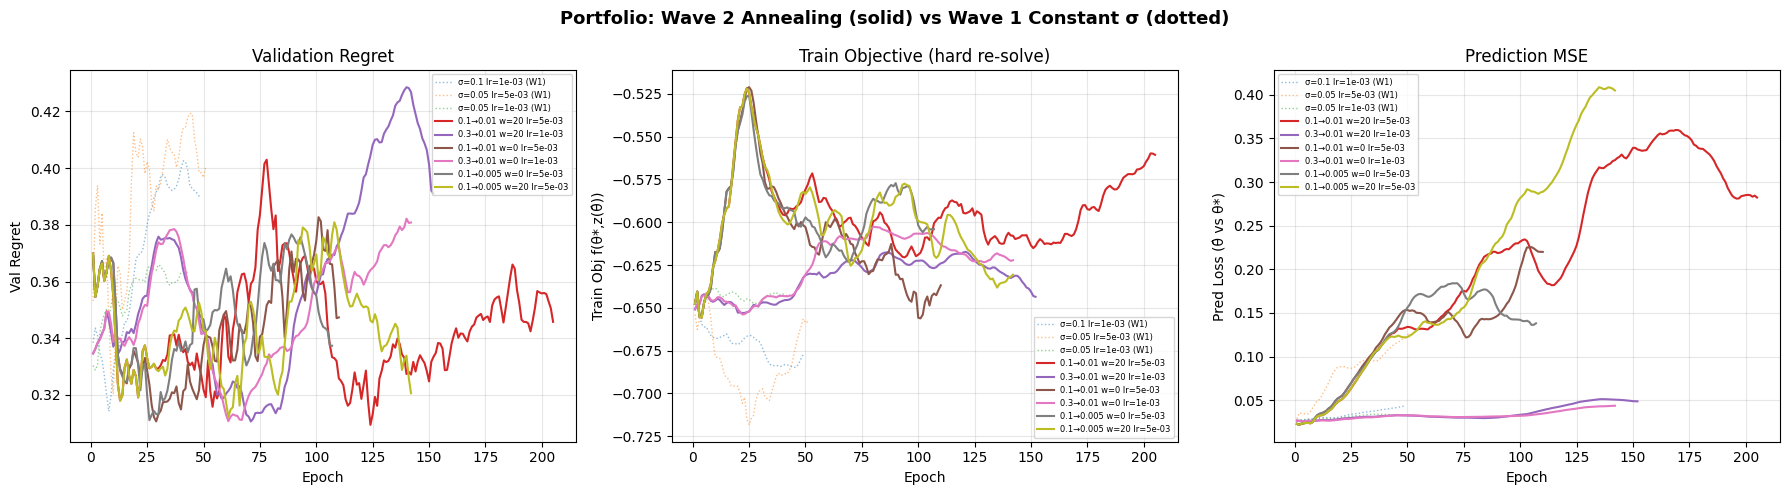


Top Wave 2 configs:
  1. 0.1→0.01 w=20 lr=5e-03                    val_regret=0.3094
  2. 0.3→0.01 w=20 lr=1e-03                    val_regret=0.3106
  3. 0.1→0.01 w=0 lr=5e-03                     val_regret=0.3106
  4. 0.3→0.01 w=0 lr=1e-03                     val_regret=0.3108
  5. 0.1→0.005 w=0 lr=5e-03                    val_regret=0.3111
  6. 0.1→0.005 w=20 lr=5e-03                   val_regret=0.3122

Best Wave 1: σ=0.1 lr=1e-03 (W1)                       val_regret=0.3142


In [17]:
W2_TOP_K = 6  # how many Wave 2 traces to show

# ── Collect Wave 2 traces ─────────────────────────────────────────────
w2_traces = []
for exp_key, exp in W2_EXPERIMENTS.items():
    tdf, vdf = read_traces(exp["data_name"], exp["prefix"])
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        label = f"{exp['sigma_start']}→{exp['sigma_end']} w={exp['warmup']} lr={exp['lr']:.0e}"
        w2_traces.append({
            "label": label, "train": tdf, "val": vdf,
            "best_val_regret": best_val, "wave": "W2",
        })

# ── Collect Wave 1 portfolio traces ──────────────────────────────────
w1_traces = []
for sigma_tag, sigma_val in SIGMAS.items():
    for lr_tag, lr_val in LRS.items():
        prefix = f"sd1_s{sigma_tag}_{lr_tag}"
        tdf, vdf = read_traces("portfolio-real", prefix)
        if tdf is not None:
            best_val = get_best_val_regret(vdf)
            label = f"σ={sigma_val} lr={lr_val:.0e} (W1)"
            w1_traces.append({
                "label": label, "train": tdf, "val": vdf,
                "best_val_regret": best_val, "wave": "W1",
            })

print(f"Wave 1 portfolio: {len(w1_traces)}/9 traces")
print(f"Wave 2 portfolio: {len(w2_traces)}/30 traces")

if len(w2_traces) > 0:
    # Sort both by best val regret, pick top from each
    w2_traces.sort(key=lambda t: t["best_val_regret"])
    w1_traces.sort(key=lambda t: t["best_val_regret"])
    w2_sel = w2_traces[:W2_TOP_K]
    w1_sel = w1_traces[:3]  # top 3 from wave 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Panel 1: Val Regret ──
    ax = axes[0]
    for i, tr in enumerate(w1_sel):
        ax.plot(tr["val"]["epoch_num"], tr["val"]["eval"],
                color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1,
                label=tr["label"])
    for i, tr in enumerate(w2_sel):
        ax.plot(tr["val"]["epoch_num"], tr["val"]["eval"],
                color=f"C{len(w1_sel)+i}", linewidth=1.5,
                label=tr["label"])
    ax.set_xlabel("Epoch"); ax.set_ylabel("Val Regret")
    ax.set_title("Validation Regret"); ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    # ── Panel 2: Train Objective ──
    ax = axes[1]
    for i, tr in enumerate(w1_sel):
        ax.plot(tr["train"]["epoch_num"], tr["train"]["obj"],
                color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1,
                label=tr["label"])
    for i, tr in enumerate(w2_sel):
        ax.plot(tr["train"]["epoch_num"], tr["train"]["obj"],
                color=f"C{len(w1_sel)+i}", linewidth=1.5,
                label=tr["label"])
    ax.set_xlabel("Epoch"); ax.set_ylabel("Train Obj f(θ*,z(θ̂))")
    ax.set_title("Train Objective (hard re-solve)"); ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    # ── Panel 3: Pred Loss ──
    ax = axes[2]
    for i, tr in enumerate(w1_sel):
        ax.plot(tr["train"]["epoch_num"], tr["train"]["pred_loss"],
                color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1,
                label=tr["label"])
    for i, tr in enumerate(w2_sel):
        ax.plot(tr["train"]["epoch_num"], tr["train"]["pred_loss"],
                color=f"C{len(w1_sel)+i}", linewidth=1.5,
                label=tr["label"])
    ax.set_xlabel("Epoch"); ax.set_ylabel("Pred Loss (θ̂ vs θ*)")
    ax.set_title("Prediction MSE"); ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    fig.suptitle("Portfolio: Wave 2 Annealing (solid) vs Wave 1 Constant σ (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Summary table
    print("\nTop Wave 2 configs:")
    for i, tr in enumerate(w2_sel):
        print(f"  {i+1}. {tr['label']:40s}  val_regret={tr['best_val_regret']:.4f}")
    if w1_traces:
        print(f"\nBest Wave 1: {w1_traces[0]['label']:40s}  val_regret={w1_traces[0]['best_val_regret']:.4f}")
else:
    print("No Wave 2 traces available yet.")

### Wave 2: SLURM Error Scanner

In [18]:
# Scan Wave 2 SLURM logs for errors
import glob

w2_err_files = sorted(glob.glob("logs/slurm/pco_portfolio_sd1_lin_*.err"))
print(f"Found {len(w2_err_files)} Wave 2 error log files")

w2_errors = 0
for f in w2_err_files:
    with open(f) as fh:
        content = fh.read()
    if "Error" in content or "Traceback" in content or "CANCELLED" in content:
        w2_errors += 1
        basename = os.path.basename(f)
        lines = content.strip().split("\n")
        print(f"\n{'='*60}")
        print(f"ERROR in {basename}:")
        for line in lines[-5:]:
            print(f"  {line}")

if w2_errors == 0:
    print("No errors found in Wave 2 SLURM logs.")

Found 35 Wave 2 error log files

ERROR in pco_portfolio_sd1_lin_s03to001_w0_lr5e3_32038878.err:
  2026-03-02 16:19:54-INFO:  Iter 40, train Objective:   -0.68887,  Loss:      0.21182 Pred Loss:      0.06829, regret: 0.39959
  2026-03-02 16:19:57-INFO:  Iter 40, val   Objective:   -0.70448,  Loss:      0.20713 Pred Loss:      0.06001, regret: 0.42694
  2026-03-02 16:19:57-INFO:  ----
  
  slurmstepd: error: *** JOB 32038878 ON p1cmp075 CANCELLED AT 2026-03-02T16:19:59 DUE TO PREEMPTION ***

ERROR in pco_portfolio_sd1_lin_s03to001_w20_lr1e3_32038880.err:
  2026-03-02 16:19:54-INFO:  Iter 41, train Objective:   -0.64544,  Loss:      0.22465 Pred Loss:      0.03218, regret: 0.39005
  2026-03-02 16:19:57-INFO:  Iter 41, val   Objective:   -0.64019,  Loss:      0.21085 Pred Loss:      0.04255, regret: 0.36407
  2026-03-02 16:19:57-INFO:  ----
  
  slurmstepd: error: *** JOB 32038880 ON p1cmp075 CANCELLED AT 2026-03-02T16:19:59 DUE TO PREEMPTION ***

ERROR in pco_portfolio_sd1_lin_s03to001_w2

---

# Wave 2 — Cubic: Sigma Annealing + Tanh Activation

**Goal**: Improve cubic regret via sigma annealing and tanh output activation.

| Hyperparameter | Values |
|---|---|
| Schedule | linear_decay |
| σ start → end | 0.1→0.01, 0.1→0.001, 0.05→0.005, 0.05→0.001, 0.5→0.01 |
| Warmup | 0, 10, 30 epochs |
| lr | 1e-3, 5e-3, 1e-2 |
| Activation | none, tanh |
| n_samples | 25 |
| n_epochs | 400, patience = 80 |

**5 ranges × 3 warmups × 3 LRs × 2 activations = 90 experiments** (~15s each)

In [19]:
# ── Cubic Wave 2 Registry ─────────────────────────────────────────────
CUB_RANGES = {
    "s01to001":  (0.1, 0.01),
    "s01to0001": (0.1, 0.001),
    "s005to0005":(0.05, 0.005),
    "s005to0001":(0.05, 0.001),
    "s05to001":  (0.5, 0.01),
}
CUB_WARMUPS = [0, 10, 30]
CUB_LRS = {"lr1e3": 1e-3, "lr5e3": 5e-3, "lr1e2": 1e-2}
CUB_ACTIVATIONS = ["none", "tanh"]

CUB_EXPERIMENTS = {}
for range_tag, (s_start, s_end) in CUB_RANGES.items():
    for warmup in CUB_WARMUPS:
        for act in CUB_ACTIVATIONS:
            act_prefix = "tanh_" if act == "tanh" else ""
            for lr_tag, lr_val in CUB_LRS.items():
                prefix = f"sd1_cub_lin_{range_tag}_w{warmup}_{act_prefix}{lr_tag}"
                exp_key = f"cub_{range_tag}_w{warmup}_{act_prefix}{lr_tag}"
                CUB_EXPERIMENTS[exp_key] = {
                    "data_name": "cubic-gen",
                    "prefix": prefix,
                    "sigma_start": s_start,
                    "sigma_end": s_end,
                    "warmup": warmup,
                    "lr": lr_val,
                    "activation": act,
                    "range_tag": range_tag,
                    "lr_tag": lr_tag,
                }

print(f"Cubic Wave 2: registered {len(CUB_EXPERIMENTS)} experiments")
print(f"Grid: {len(CUB_RANGES)} ranges × {len(CUB_WARMUPS)} warmups × "
      f"{len(CUB_LRS)} LRs × {len(CUB_ACTIVATIONS)} activations")

Cubic Wave 2: registered 90 experiments
Grid: 5 ranges × 3 warmups × 3 LRs × 2 activations


### Cubic Wave 2: Launch & Status

In [20]:
# Dry run
!bash shells/slurm/submit_cubic_wave2.sh --dry-run 2>&1 | head -15
print("...")
!bash shells/slurm/submit_cubic_wave2.sh --dry-run 2>&1 | tail -8

Wave 2 — Cubic Sigma Annealing + Tanh
Grid: 5 ranges × 3 warmups × 3 LRs × 2 activations = 90 experiments
Schedule: linear_decay, n_samples=25, n_epochs=400, patience=80
Primary:  preempt
Backup:   hugheslab,gpu (afternotok dependency)
Time: 24:00:00  Mem: 16G  GRES: gpu:1
*** DRY RUN MODE ***
Skip completed: ON
Total experiments: 90

[SKIP] pco_cubic_sd1_cub_lin_s01to001_w0_lr1e3 — already completed
[SKIP] pco_cubic_sd1_cub_lin_s01to001_w0_lr5e3 — already completed


...

Submitted: 0 experiments
  → 0 primary (preempt) + 0 backup (hugheslab,gpu)
  → Total SLURM jobs: 0
Skipped (completed): 90

Dry run complete. No jobs submitted.


In [21]:
# Submit (uncomment to run):
# !bash shells/slurm/submit_cubic_wave2.sh

In [22]:
# Job status
!squeue -u $USER --format="%.18i %.30j %.8T %.10M %.6D %R" | grep -E "pco_cubic|JOBID" | head -40

             JOBID                           NAME    STATE       TIME  NODES NODELIST(REASON)


### Cubic Wave 2: Collect Results

In [23]:
# Collect Cubic Wave 2 results
cub_rows = []
for exp_key, exp in CUB_EXPERIMENTS.items():
    result = read_result(exp["data_name"], exp["prefix"])
    row = {
        "experiment": exp_key,
        "prefix": exp["prefix"],
        "sigma_start": exp["sigma_start"],
        "sigma_end": exp["sigma_end"],
        "warmup": exp["warmup"],
        "lr": exp["lr"],
        "activation": exp["activation"],
        "range_label": f"{exp['sigma_start']}→{exp['sigma_end']}",
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    cub_rows.append(row)

cub_df = pd.DataFrame(cub_rows)
cub_done = cub_df[cub_df["status"] == "done"]
cub_pending = cub_df[cub_df["status"] == "pending"]
print(f"Cubic Wave 2 — Completed: {len(cub_done)}/{len(cub_df)} experiments")
if len(cub_pending) > 0:
    print(f"Pending: {len(cub_pending)}")
    for _, r in cub_pending.head(10).iterrows():
        print(f"  {r['range_label']:14s}  w={r['warmup']:<4}  act={r['activation']:5s}  lr={r['lr']}")
    if len(cub_pending) > 10:
        print(f"  ... and {len(cub_pending)-10} more")

Cubic Wave 2 — Completed: 90/90 experiments


### Cubic Wave 2: Results — Tanh vs No-Tanh Comparison

In [24]:
if len(cub_done) > 0:
    # ── Summary table: best by (activation, range) ──
    pivot_cub = cub_done.pivot_table(
        index=["activation", "range_label", "warmup"],
        columns="lr", values="regret", aggfunc="first"
    )
    print("Cubic Wave 2 — Test Regret (full grid)")
    print("=" * 90)
    print(pivot_cub.to_string())

    # ── Tanh vs None comparison ──
    print("\n\n── Tanh vs No-Tanh Effect ──")
    for act in CUB_ACTIVATIONS:
        act_data = cub_done[cub_done["activation"] == act]
        if len(act_data) > 0:
            best = act_data.loc[act_data["regret"].idxmin()]
            print(f"  {act:5s}: best regret={best['regret']:.4f} "
                  f"({best['range_label']} w={int(best['warmup'])} lr={best['lr']})")
            print(f"         mean regret={act_data['regret'].mean():.4f} "
                  f"(across {len(act_data)} configs)")

    # ── Overall best ──
    best_cub = cub_done.loc[cub_done["regret"].idxmin()]
    print(f"\n★ Best Cubic Wave 2: {best_cub['range_label']} w={int(best_cub['warmup'])} "
          f"act={best_cub['activation']} lr={best_cub['lr']} → regret={best_cub['regret']:.4f}")

    # ── Compare to Wave 1 cubic best ──
    w1_cubic = done[done["problem"] == "cubic"] if len(done) > 0 else pd.DataFrame()
    if len(w1_cubic) > 0:
        w1_best = w1_cubic.loc[w1_cubic["regret"].idxmin()]
        print(f"  Wave 1 best: σ={w1_best['sigma']} lr={w1_best['lr']} "
              f"→ regret={w1_best['regret']:.4f}")
        improvement = (w1_best["regret"] - best_cub["regret"]) / w1_best["regret"] * 100
        print(f"  Improvement: {improvement:+.1f}%")
else:
    print("No Cubic Wave 2 results yet.")

Cubic Wave 2 — Test Regret (full grid)
lr                             0.0010  0.0050  0.0100
activation range_label warmup                        
none       0.05→0.001  0       1.5364  1.5295  0.0374
                       10      1.5372  1.5291  0.0245
                       30      1.5380  1.5263  1.5222
           0.05→0.005  0       1.5372  1.5301  0.0255
                       10      1.5374  1.5302  0.0415
                       30      1.5379  1.5270  1.5217
           0.1→0.001   0       1.5475  1.5290  1.5309
                       10      1.5475  1.5263  1.5313
                       30      1.5285  1.5292  1.5322
           0.1→0.01    0       1.5470  1.5272  1.5307
                       10      1.5478  1.5269  1.5320
                       30      1.5333  1.5298  1.5287
           0.5→0.01    0      14.6992  1.5612  1.5442
                       10     14.6992  1.5683  1.5442
                       30     14.6992  1.5817  1.5478
tanh       0.05→0.001  0       1.5422  1.52

### Cubic Wave 2: Heatmaps — Range vs Warmup (split by activation)

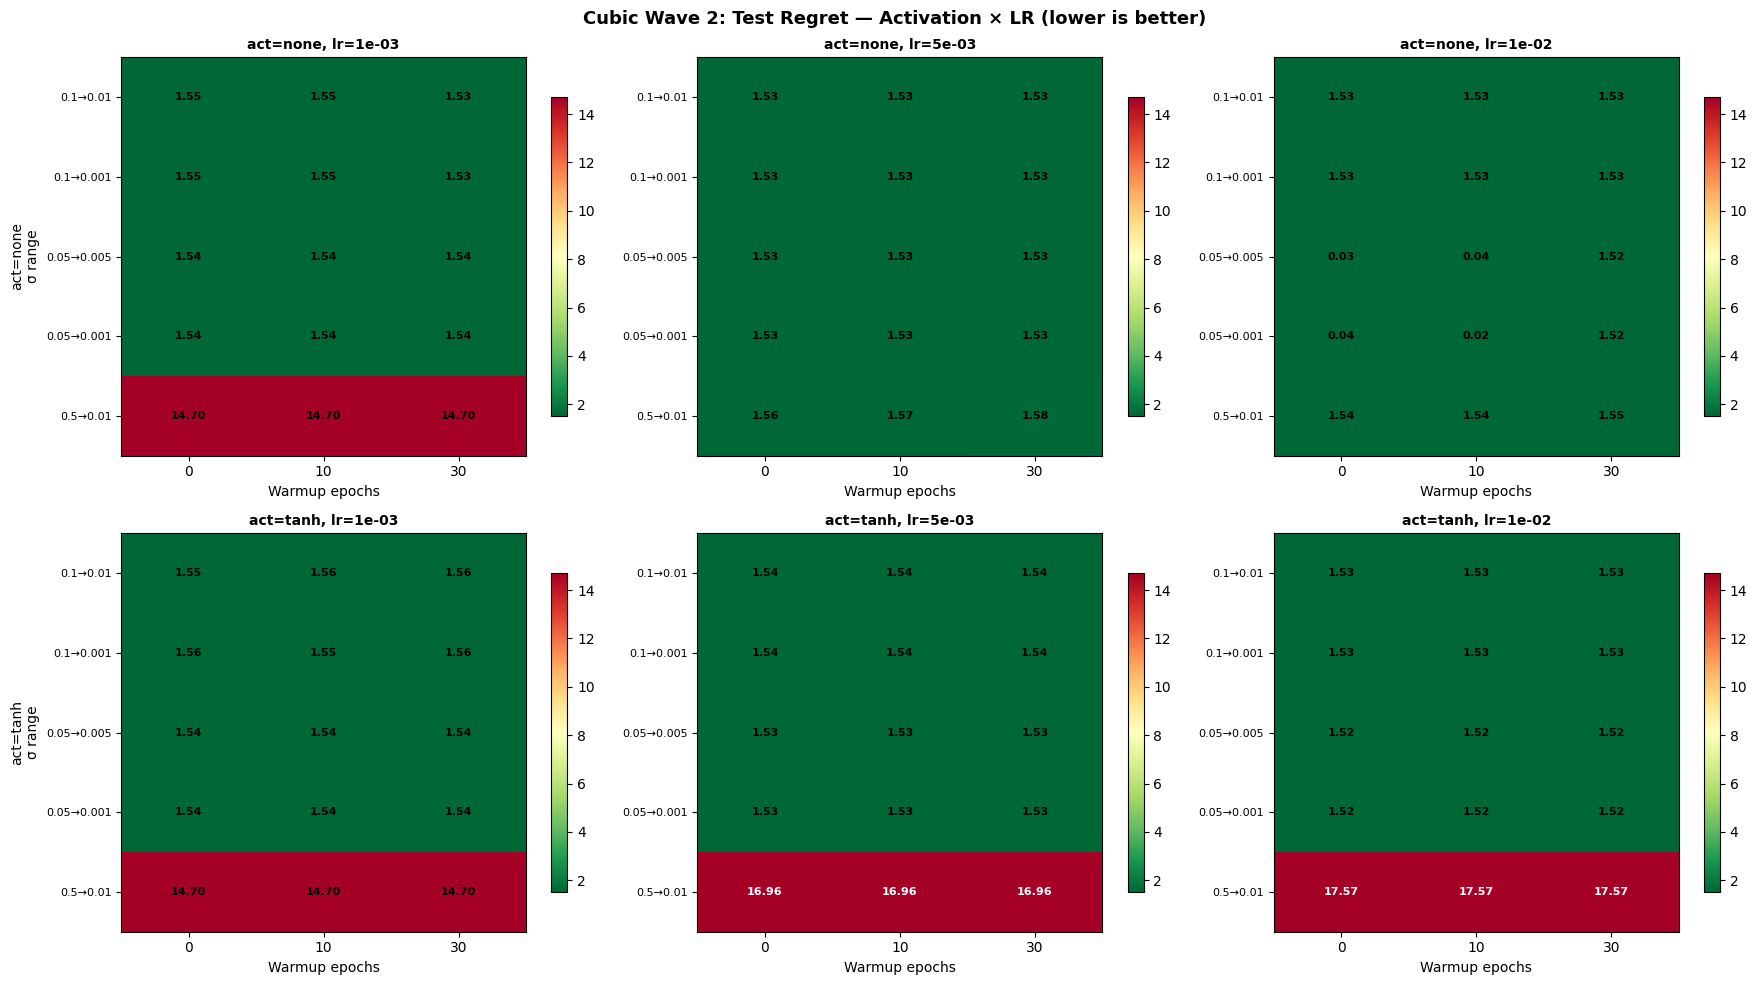

In [25]:
if len(cub_done) > 0:
    range_labels_c = [f"{s}→{e}" for _, (s, e) in CUB_RANGES.items()]
    warmup_vals_c = CUB_WARMUPS
    lr_vals_c = sorted(CUB_LRS.values())

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for ai, act in enumerate(CUB_ACTIVATIONS):
        act_data = cub_done[cub_done["activation"] == act]
        for li, lr_val in enumerate(lr_vals_c):
            ax = axes[ai, li]
            lr_data = act_data[act_data["lr"] == lr_val]

            heat = np.full((len(range_labels_c), len(warmup_vals_c)), np.nan)
            for _, row in lr_data.iterrows():
                ri = range_labels_c.index(row["range_label"])
                wi = warmup_vals_c.index(row["warmup"])
                heat[ri, wi] = row["regret"]

            vmin = cub_done["regret"].quantile(0.1) if len(cub_done) > 5 else None
            vmax = cub_done["regret"].quantile(0.9) if len(cub_done) > 5 else None
            im = ax.imshow(heat, cmap="RdYlGn_r", aspect="auto", vmin=vmin, vmax=vmax)
            ax.set_xticks(range(len(warmup_vals_c)))
            ax.set_xticklabels([str(w) for w in warmup_vals_c])
            ax.set_yticks(range(len(range_labels_c)))
            ax.set_yticklabels(range_labels_c, fontsize=8)
            ax.set_xlabel("Warmup epochs")
            if li == 0:
                ax.set_ylabel(f"act={act}\nσ range")
            ax.set_title(f"act={act}, lr={lr_val:.0e}", fontsize=10, fontweight="bold")

            for ri in range(len(range_labels_c)):
                for wi in range(len(warmup_vals_c)):
                    val = heat[ri, wi]
                    if not np.isnan(val):
                        ax.text(wi, ri, f"{val:.2f}", ha="center", va="center",
                                fontsize=8, fontweight="bold",
                                color="white" if val > (vmax or np.nanmedian(heat)) else "black")

            fig.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle("Cubic Wave 2: Test Regret — Activation × LR (lower is better)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No Cubic Wave 2 results yet.")

### Cubic Wave 2: Training Traces — Best Annealing vs Wave 1 Baseline

Cubic W1: 9/9 traces, W2: 90/90 traces


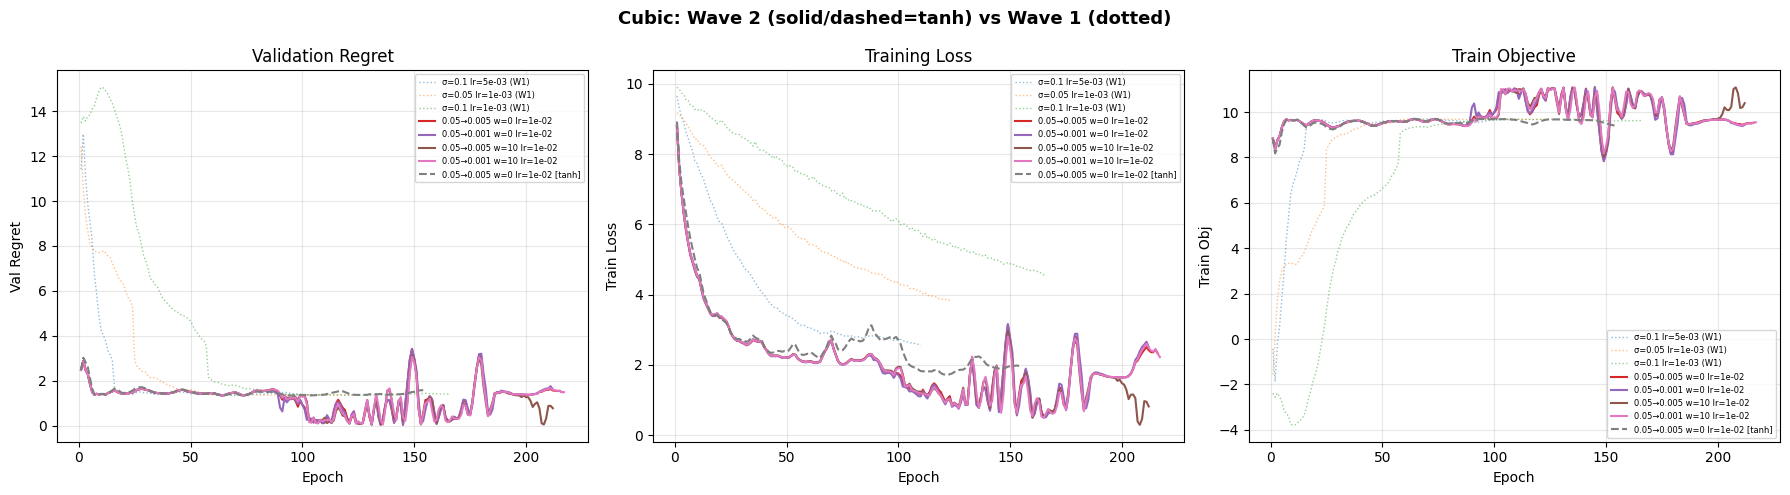


Top Cubic Wave 2 configs:
  1. 0.05→0.005 w=0 lr=1e-02                        val_regret=0.0348
  2. 0.05→0.001 w=0 lr=1e-02                        val_regret=0.0414
  3. 0.05→0.005 w=10 lr=1e-02                       val_regret=0.0445
  4. 0.05→0.001 w=10 lr=1e-02                       val_regret=0.0471
  5. 0.05→0.005 w=0 lr=1e-02 [tanh]                 val_regret=1.3391

Best Cubic W1: σ=0.1 lr=5e-03 (W1)                            val_regret=1.3441


In [26]:
CUB_TOP_K = 5

# ── Collect Cubic Wave 2 traces ──
cub_w2_traces = []
for exp_key, exp in CUB_EXPERIMENTS.items():
    tdf, vdf = read_traces(exp["data_name"], exp["prefix"])
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        act_label = f" [tanh]" if exp["activation"] == "tanh" else ""
        label = (f"{exp['sigma_start']}→{exp['sigma_end']} w={exp['warmup']} "
                 f"lr={exp['lr']:.0e}{act_label}")
        cub_w2_traces.append({
            "label": label, "train": tdf, "val": vdf,
            "best_val_regret": best_val, "activation": exp["activation"],
        })

# ── Collect Cubic Wave 1 traces ──
cub_w1_traces = []
for sigma_tag, sigma_val in SIGMAS.items():
    for lr_tag, lr_val in LRS.items():
        prefix = f"sd1_s{sigma_tag}_{lr_tag}"
        tdf, vdf = read_traces("cubic-gen", prefix)
        if tdf is not None:
            best_val = get_best_val_regret(vdf)
            label = f"σ={sigma_val} lr={lr_val:.0e} (W1)"
            cub_w1_traces.append({
                "label": label, "train": tdf, "val": vdf,
                "best_val_regret": best_val, "activation": "none",
            })

print(f"Cubic W1: {len(cub_w1_traces)}/9 traces, W2: {len(cub_w2_traces)}/90 traces")

if len(cub_w2_traces) > 0:
    cub_w2_traces.sort(key=lambda t: t["best_val_regret"])
    cub_w1_traces.sort(key=lambda t: t["best_val_regret"])
    cub_w2_sel = cub_w2_traces[:CUB_TOP_K]
    cub_w1_sel = cub_w1_traces[:3]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1: Val Regret
    ax = axes[0]
    for i, tr in enumerate(cub_w1_sel):
        ax.plot(tr["val"]["epoch_num"], tr["val"]["eval"],
                color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1, label=tr["label"])
    for i, tr in enumerate(cub_w2_sel):
        ls = "--" if tr["activation"] == "tanh" else "-"
        ax.plot(tr["val"]["epoch_num"], tr["val"]["eval"],
                color=f"C{len(cub_w1_sel)+i}", linewidth=1.5, linestyle=ls,
                label=tr["label"])
    ax.set_xlabel("Epoch"); ax.set_ylabel("Val Regret")
    ax.set_title("Validation Regret"); ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    # Panel 2: Train Loss
    ax = axes[1]
    for i, tr in enumerate(cub_w1_sel):
        ax.plot(tr["train"]["epoch_num"], tr["train"]["loss"],
                color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1, label=tr["label"])
    for i, tr in enumerate(cub_w2_sel):
        ls = "--" if tr["activation"] == "tanh" else "-"
        ax.plot(tr["train"]["epoch_num"], tr["train"]["loss"],
                color=f"C{len(cub_w1_sel)+i}", linewidth=1.5, linestyle=ls,
                label=tr["label"])
    ax.set_xlabel("Epoch"); ax.set_ylabel("Train Loss")
    ax.set_title("Training Loss"); ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    # Panel 3: Train Objective
    ax = axes[2]
    for i, tr in enumerate(cub_w1_sel):
        ax.plot(tr["train"]["epoch_num"], tr["train"]["obj"],
                color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1, label=tr["label"])
    for i, tr in enumerate(cub_w2_sel):
        ls = "--" if tr["activation"] == "tanh" else "-"
        ax.plot(tr["train"]["epoch_num"], tr["train"]["obj"],
                color=f"C{len(cub_w1_sel)+i}", linewidth=1.5, linestyle=ls,
                label=tr["label"])
    ax.set_xlabel("Epoch"); ax.set_ylabel("Train Obj")
    ax.set_title("Train Objective"); ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    fig.suptitle("Cubic: Wave 2 (solid/dashed=tanh) vs Wave 1 (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\nTop Cubic Wave 2 configs:")
    for i, tr in enumerate(cub_w2_sel):
        print(f"  {i+1}. {tr['label']:45s}  val_regret={tr['best_val_regret']:.4f}")
    if cub_w1_traces:
        print(f"\nBest Cubic W1: {cub_w1_traces[0]['label']:45s}  "
              f"val_regret={cub_w1_traces[0]['best_val_regret']:.4f}")
else:
    print("No Cubic Wave 2 traces available yet.")

### Cubic Wave 2: SLURM Error Scanner

In [27]:
import glob

slurm_dir = "../logs/slurm"
cub_err_files = sorted(glob.glob(f"{slurm_dir}/pco_cubic_sd1_cub_lin_*.err"))
print(f"Found {len(cub_err_files)} cubic Wave 2 error files\n")

problems_found = 0
for f in cub_err_files:
    with open(f) as fh:
        content = fh.read()
    # Check for real errors (skip deprecation warnings)
    lines = content.strip().split("\n")
    error_lines = [l for l in lines
                   if any(kw in l.lower() for kw in ["error", "traceback", "exception", "killed", "oom"])
                   and "deprecat" not in l.lower() and "warning" not in l.lower()]
    if error_lines:
        problems_found += 1
        short_name = os.path.basename(f)
        print(f"⚠ {short_name}:")
        for l in error_lines[:5]:
            print(f"   {l.strip()}")
        print()

if problems_found == 0:
    print("✓ No errors detected in any cubic Wave 2 SLURM logs.")

Found 0 cubic Wave 2 error files

✓ No errors detected in any cubic Wave 2 SLURM logs.


## Diagnosing Portfolio Wave 2: Early Improvement Mystery

**Observation**: Portfolio W2 runs with σ=0.1, lr=5e-3 show consistent regret improvement over the first ~20 epochs — even with `warmup=20` (which holds σ constant during that period).

**Root cause**: This is NOT due to annealing. Three factors explain it:

1. **σ barely changes in 20 epochs regardless of warmup**: For `w=0` (no warmup), σ decays only from 0.100 → 0.096 over 20 epochs (linear decay over 400). So `w=0`, `w=20`, `w=50` are functionally identical early on.

2. **The `n_samples` confound**: Wave 2 uses `n_samples=5` vs Wave 1's `n_samples=25`. This dramatically changes training dynamics — noisier gradients slow down `|θ̂|` growth, keeping σ/|θ̂| high and preventing the soft-to-hard exploitation seen in Wave 1.

3. **Normal learning, not annealing**: The model IS learning with fixed σ — gradient descent on the soft DPO loss improves decisions even without σ decay. The improvement happens because the perturbation is sufficiently large relative to predictions to provide useful gradients.

In [28]:
# ── Parse full training logs including |coeff_hat| and sigma ──────────

import re

def read_full_traces(data_name, prefix, model="perturb"):
    """Read training logs including |coeff_hat|, sigma, sigma/|coeff_hat| diagnostics."""
    base = os.path.join("saved_records", data_name, model, prefix)
    log_path = os.path.join(base, "log.txt")
    if not os.path.exists(log_path):
        return None, None, None

    metric_pattern = re.compile(
        r"Iter\s+(\d+),\s+(train|val)\s+Objective:\s+([\d.eE+-]+),\s+"
        r"Loss:\s+([\d.eE+-]+)\s+Pred Loss:\s+([\d.eE+-]+),\s+"
        r"(?:regret|uplift):\s+([\d.eE+-]+)"
    )
    diag_pattern = re.compile(
        r"epoch\s+(\d+):\s+\|coeff_hat\|\s+=\s+([\d.]+),\s+sigma\s+=\s+([\d.]+),\s+"
        r"sigma/\|coeff_hat\|\s+=\s+([\d.]+)"
    )

    train_rows, val_rows, diag_rows = [], [], []
    with open(log_path) as f:
        for line in f:
            m = metric_pattern.search(line)
            if m:
                row = {
                    "epoch": int(m.group(1)),
                    "obj": float(m.group(3)),
                    "loss": float(m.group(4)),
                    "pred_loss": float(m.group(5)),
                    "regret": float(m.group(6)),
                }
                if m.group(2) == "train":
                    train_rows.append(row)
                else:
                    val_rows.append(row)
                continue
            m = diag_pattern.search(line)
            if m:
                diag_rows.append({
                    "epoch": int(m.group(1)),
                    "coeff_hat_mag": float(m.group(2)),
                    "sigma": float(m.group(3)),
                    "sigma_over_coeff": float(m.group(4)),
                })

    tdf = pd.DataFrame(train_rows) if train_rows else None
    vdf = pd.DataFrame(val_rows) if val_rows else None
    ddf = pd.DataFrame(diag_rows) if diag_rows else None
    return tdf, vdf, ddf


# ── Load Wave 2 + Wave 1 data for sigma=0.1 runs ────────────────────

diag_runs = {}

# Wave 2: s01to001 across warmups
for w in [0, 20, 50]:
    prefix = f"sd1_lin_s01to001_w{w}_lr5e3"
    tdf, vdf, ddf = read_full_traces("portfolio-real", prefix)
    if tdf is not None:
        diag_runs[f"W2 s01→01 w={w}"] = {"train": tdf, "val": vdf, "diag": ddf, "n_samples": 5}

# Wave 1: constant sigma=0.1
tdf, vdf, ddf = read_full_traces("portfolio-real", "sd1_s01_lr5e3")
if tdf is not None:
    diag_runs["W1 σ=0.1 (n=25)"] = {"train": tdf, "val": vdf, "diag": ddf, "n_samples": 25}

print(f"Loaded {len(diag_runs)} runs for diagnosis:")
for k, v in diag_runs.items():
    n_ep = len(v["train"]) if v["train"] is not None else 0
    print(f"  {k:30s}  {n_ep} epochs  n_samples={v['n_samples']}")

Loaded 4 runs for diagnosis:
  W2 s01→01 w=0                   110 epochs  n_samples=5
  W2 s01→01 w=20                  205 epochs  n_samples=5
  W2 s01→01 w=50                  115 epochs  n_samples=5
  W1 σ=0.1 (n=25)                 92 epochs  n_samples=25


### Finding 1: All warmup variants are identical in the first 20 epochs

With `linear_decay` over 400 epochs, σ only drops from 0.100 to 0.096 by epoch 20 (for w=0).
For w=20 and w=50, σ is exactly constant at 0.100. The runs are functionally identical.

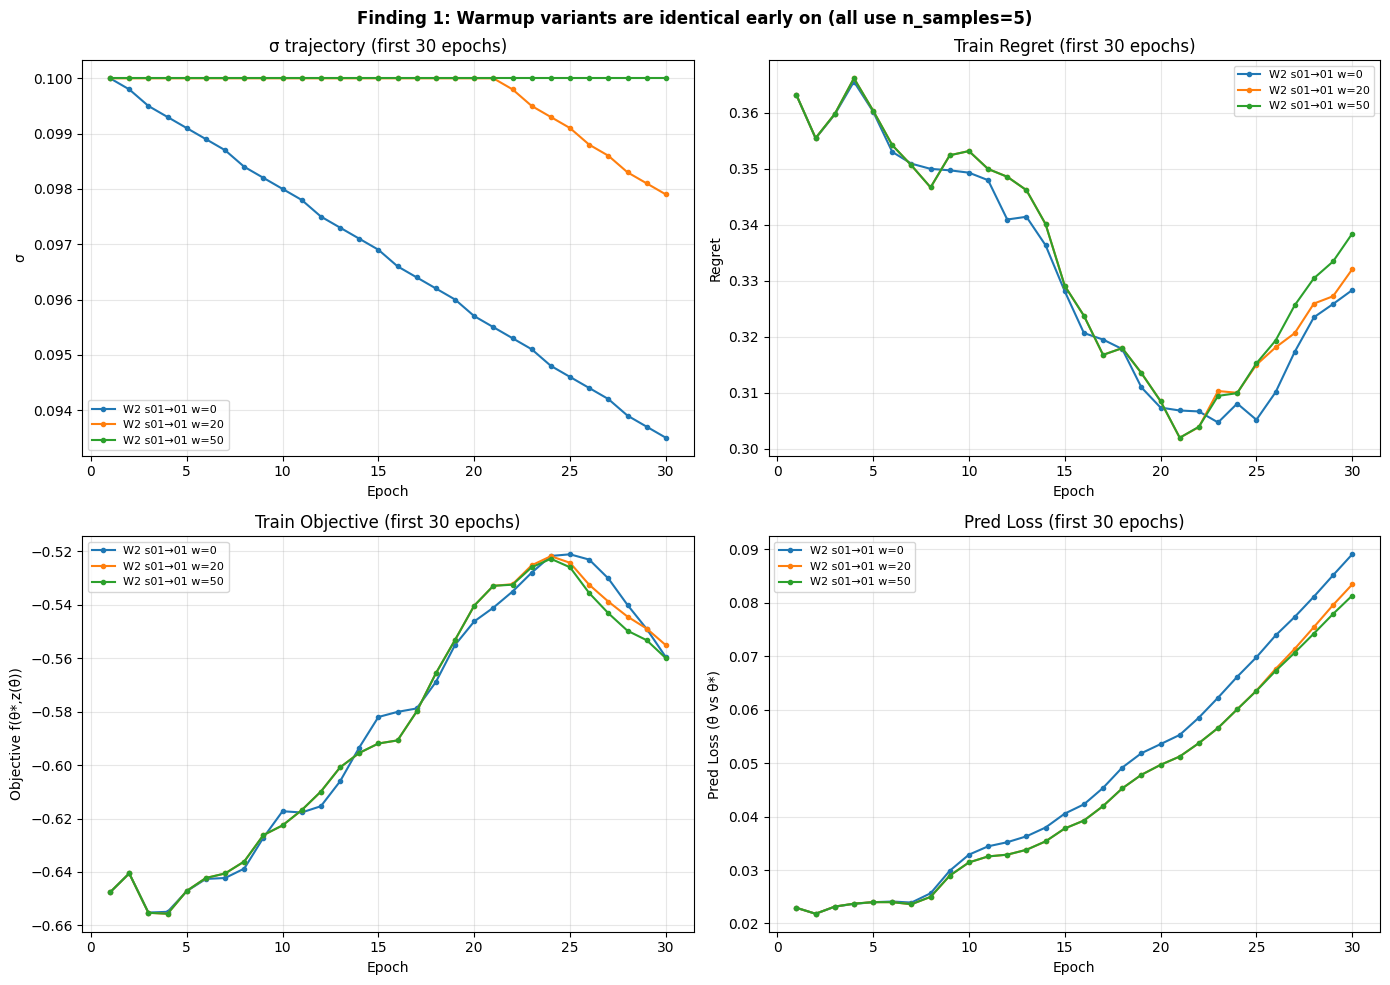


Max |w=0 - w=20| over first 20 epochs:
  Regret:    0.007640
  Objective: 0.010680


In [29]:
# ── Side-by-side: first 30 epochs across warmup variants ──────────────

N_SHOW = 30
w2_keys = [k for k in diag_runs if k.startswith("W2")]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Sigma trajectory
ax = axes[0, 0]
for k in w2_keys:
    d = diag_runs[k]["diag"]
    if d is not None:
        ax.plot(d["epoch"][:N_SHOW], d["sigma"][:N_SHOW], "o-", markersize=3, label=k)
ax.set_xlabel("Epoch"); ax.set_ylabel("σ")
ax.set_title("σ trajectory (first 30 epochs)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 2: Train Regret
ax = axes[0, 1]
for k in w2_keys:
    t = diag_runs[k]["train"]
    if t is not None:
        ax.plot(t["epoch"][:N_SHOW], t["regret"][:N_SHOW], "o-", markersize=3, label=k)
ax.set_xlabel("Epoch"); ax.set_ylabel("Regret")
ax.set_title("Train Regret (first 30 epochs)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 3: Train Objective
ax = axes[1, 0]
for k in w2_keys:
    t = diag_runs[k]["train"]
    if t is not None:
        ax.plot(t["epoch"][:N_SHOW], t["obj"][:N_SHOW], "o-", markersize=3, label=k)
ax.set_xlabel("Epoch"); ax.set_ylabel("Objective f(θ*,z(θ̂))")
ax.set_title("Train Objective (first 30 epochs)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 4: Pred Loss
ax = axes[1, 1]
for k in w2_keys:
    t = diag_runs[k]["train"]
    if t is not None:
        ax.plot(t["epoch"][:N_SHOW], t["pred_loss"][:N_SHOW], "o-", markersize=3, label=k)
ax.set_xlabel("Epoch"); ax.set_ylabel("Pred Loss (θ̂ vs θ*)")
ax.set_title("Pred Loss (first 30 epochs)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle("Finding 1: Warmup variants are identical early on (all use n_samples=5)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Quantify how identical they are
if len(w2_keys) >= 2:
    t0 = diag_runs[w2_keys[0]]["train"]
    t1 = diag_runs[w2_keys[1]]["train"]
    if t0 is not None and t1 is not None:
        n = min(20, len(t0), len(t1))
        reg_diff = np.abs(t0["regret"].values[:n] - t1["regret"].values[:n]).max()
        obj_diff = np.abs(t0["obj"].values[:n] - t1["obj"].values[:n]).max()
        print(f"\nMax |w=0 - w=20| over first 20 epochs:")
        print(f"  Regret:    {reg_diff:.6f}")
        print(f"  Objective: {obj_diff:.6f}")

### Finding 2: The n_samples confound — W1 (n=25) vs W2 (n=5)

Wave 2 uses `n_samples=5` to stay within runtime budget, but Wave 1 used `n_samples=25`.
This changes the training dynamics profoundly:

| Metric | W1 (n=25) ep1→20 | W2 (n=5) ep1→20 |
|--------|-------------------|------------------|
| `\|θ̂\|` | 0.125 → 0.276 (2.2×) | 0.125 → 0.148 (1.2×) |
| σ/`\|θ̂\|` | 0.80 → 0.36 | 0.80 → 0.65 |
| pred_loss | 0.028 → 0.128 | 0.023 → 0.050 |
| regret | 0.395 → 0.422 (⬆ worse) | 0.363 → 0.308 (⬇ better) |

With n=25, the model gets a clean gradient signal, grows `|θ̂|` fast, and overfits the soft pathway (exactly the "soft-to-hard gap" from the investigation notebook). With n=5, the noisier gradient slows `|θ̂|` growth, keeps σ/`|θ̂|` high, and the model actually learns useful decisions.

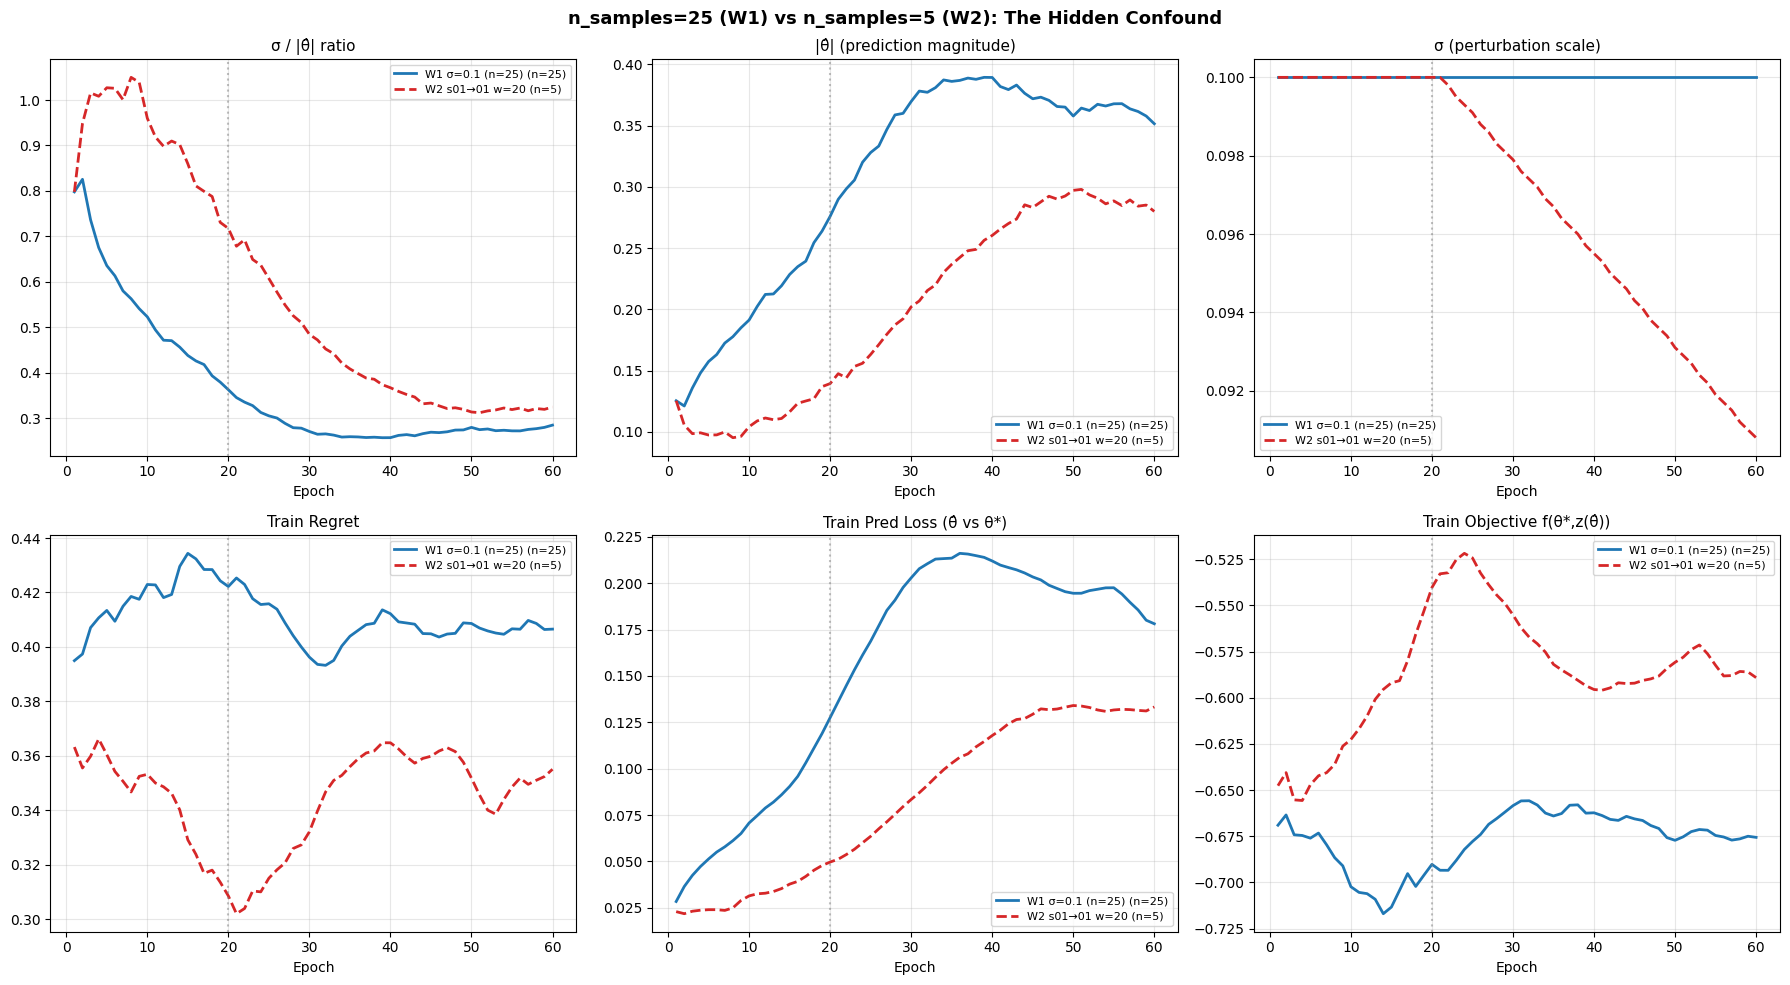


┌──────────────────────────────────────────────────────┐
│           Epoch 20 Snapshot (both σ=0.1)            │
├───────────────────┬──────────────┬──────────────────┤
│ Metric            │    W1 (n=25) │         W2 (n=5) │
├───────────────────┼──────────────┼──────────────────┤
│ Regret            │       0.4222 │           0.3085 │
│ Objective         │     -0.69024 │         -0.54031 │
│ Pred Loss         │      0.12756 │          0.04967 │
│ |θ̂|              │       0.2760 │           0.1394 │
│ σ/|θ̂|            │       0.3623 │           0.7174 │
└───────────────────┴──────────────┴──────────────────┘


In [30]:
# ── W1 (n=25) vs W2 (n=5): the n_samples confound ────────────────────

N_EPOCHS_SHOW = 60

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

w1_key = "W1 σ=0.1 (n=25)"
w2_key = "W2 s01→01 w=20"  # warmup=20 → constant sigma for first 20 epochs

titles = [
    ("σ / |θ̂| ratio", "diag", "sigma_over_coeff"),
    ("|θ̂| (prediction magnitude)", "diag", "coeff_hat_mag"),
    ("σ (perturbation scale)", "diag", "sigma"),
    ("Train Regret", "train", "regret"),
    ("Train Pred Loss (θ̂ vs θ*)", "train", "pred_loss"),
    ("Train Objective f(θ*,z(θ̂))", "train", "obj"),
]

for idx, (title, source, col) in enumerate(titles):
    ax = axes[idx // 3, idx % 3]
    for k, sty in [(w1_key, {"color": "C0", "linewidth": 2}),
                    (w2_key, {"color": "C3", "linewidth": 2, "linestyle": "--"})]:
        if k in diag_runs:
            df = diag_runs[k][source]
            if df is not None:
                ep_col = "epoch"
                ax.plot(df[ep_col][:N_EPOCHS_SHOW], df[col][:N_EPOCHS_SHOW],
                        label=f"{k} (n={diag_runs[k]['n_samples']})", **sty)
    ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    # Add warmup boundary
    ax.axvline(x=20, color="gray", linestyle=":", alpha=0.5, label="warmup=20 boundary")

fig.suptitle("n_samples=25 (W1) vs n_samples=5 (W2): The Hidden Confound",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print quantitative comparison at epoch 20
if w1_key in diag_runs and w2_key in diag_runs:
    w1t = diag_runs[w1_key]["train"]
    w2t = diag_runs[w2_key]["train"]
    w1d = diag_runs[w1_key]["diag"]
    w2d = diag_runs[w2_key]["diag"]
    if w1t is not None and w2t is not None:
        ep20_w1 = w1t[w1t["epoch"] == 20].iloc[0] if 20 in w1t["epoch"].values else None
        ep20_w2 = w2t[w2t["epoch"] == 20].iloc[0] if 20 in w2t["epoch"].values else None
        ep20_w1d = w1d[w1d["epoch"] == 20].iloc[0] if w1d is not None and 20 in w1d["epoch"].values else None
        ep20_w2d = w2d[w2d["epoch"] == 20].iloc[0] if w2d is not None and 20 in w2d["epoch"].values else None

        if ep20_w1 is not None and ep20_w2 is not None:
            print("\n┌──────────────────────────────────────────────────────┐")
            print("│           Epoch 20 Snapshot (both σ=0.1)            │")
            print("├───────────────────┬──────────────┬──────────────────┤")
            print(f"│ {'Metric':17s} │ {'W1 (n=25)':>12s} │ {'W2 (n=5)':>16s} │")
            print("├───────────────────┼──────────────┼──────────────────┤")
            print(f"│ {'Regret':17s} │ {ep20_w1['regret']:12.4f} │ {ep20_w2['regret']:16.4f} │")
            print(f"│ {'Objective':17s} │ {ep20_w1['obj']:12.5f} │ {ep20_w2['obj']:16.5f} │")
            print(f"│ {'Pred Loss':17s} │ {ep20_w1['pred_loss']:12.5f} │ {ep20_w2['pred_loss']:16.5f} │")
            if ep20_w1d is not None and ep20_w2d is not None:
                print(f"│ {'|θ̂|':17s} │ {ep20_w1d['coeff_hat_mag']:12.4f} │ {ep20_w2d['coeff_hat_mag']:16.4f} │")
                print(f"│ {'σ/|θ̂|':17s} │ {ep20_w1d['sigma_over_coeff']:12.4f} │ {ep20_w2d['sigma_over_coeff']:16.4f} │")
            print("└───────────────────┴──────────────┴──────────────────┘")

### Finding 3: σ/|θ̂| — the effective perturbation strength

The *actual* signal-to-noise ratio for the perturbation isn't σ alone — it's σ/|θ̂|. When |θ̂| grows fast (n=25), the perturbation becomes negligible relative to the signal, so the hard solver dominates and the soft-to-hard gap widens. When |θ̂| grows slowly (n=5), the perturbation stays meaningful.

**Implication**: Instead of (or in addition to) decaying σ with a schedule, we could consider:
- Normalizing θ̂ before perturbation
- Setting σ proportional to |θ̂| (adaptive perturbation)
- Using n_samples as a regularization knob

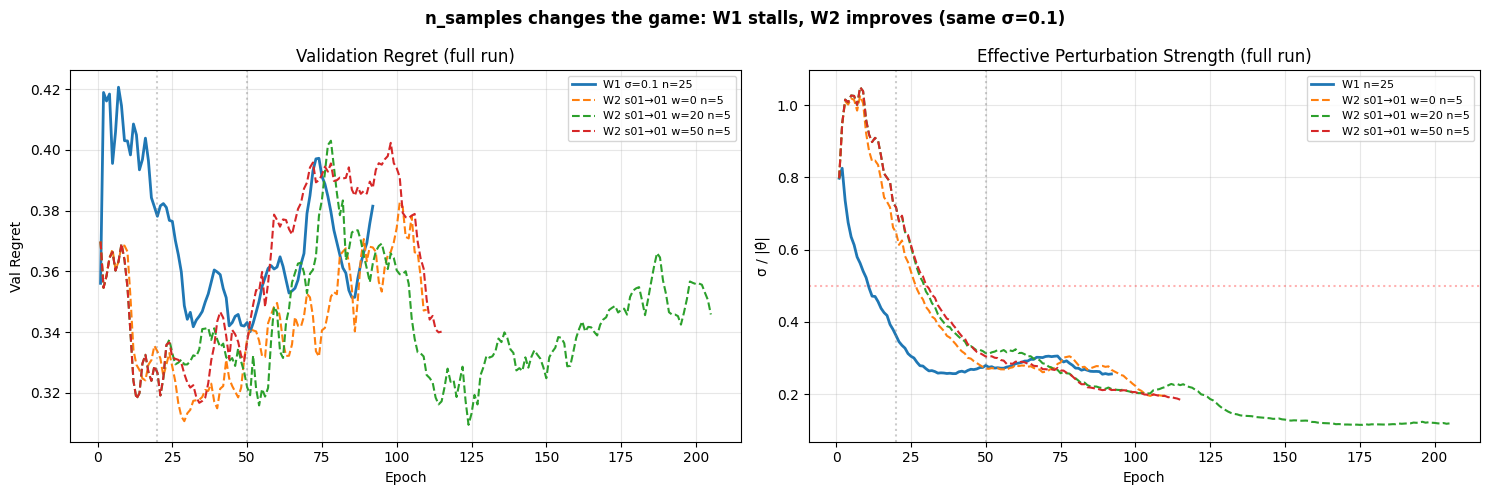


Conclusion:
──────────────────────────────────────────────────────────────────────
The 'improvement' in the first 20 epochs is just normal SGD learning
with constant σ=0.1. It has NOTHING to do with sigma annealing.

The REAL story is n_samples=5 (W2) vs n_samples=25 (W1):
  • n=25: fast |θ̂| growth → σ/|θ̂| collapses → soft-hard gap → regret stalls
  • n=5:  slow |θ̂| growth → σ/|θ̂| stays high → good soft decisions → regret improves

Implication: n_samples acts as implicit regularization. Lower n_samples
may be BETTER for portfolio because it prevents overfitting the soft pathway.


In [31]:
# ── Full-run comparison: W1 (n=25) vs W2 (n=5) regret + σ/|θ̂| ───────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_w2 = {"W2 s01→01 w=0": "C1", "W2 s01→01 w=20": "C2", "W2 s01→01 w=50": "C3"}

# Panel 1: Val Regret — full run
ax = axes[0]
if w1_key in diag_runs and diag_runs[w1_key]["val"] is not None:
    vdf = diag_runs[w1_key]["val"]
    ax.plot(vdf["epoch"], vdf["regret"], color="C0", linewidth=2, label="W1 σ=0.1 n=25")
for k in w2_keys:
    if k in diag_runs and diag_runs[k]["val"] is not None:
        vdf = diag_runs[k]["val"]
        ax.plot(vdf["epoch"], vdf["regret"], color=colors_w2.get(k, "C4"),
                linewidth=1.5, linestyle="--", label=k + " n=5")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val Regret")
ax.set_title("Validation Regret (full run)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.axvline(x=20, color="gray", linestyle=":", alpha=0.4)
ax.axvline(x=50, color="gray", linestyle=":", alpha=0.4)

# Panel 2: σ/|θ̂| ratio — full run
ax = axes[1]
if w1_key in diag_runs and diag_runs[w1_key]["diag"] is not None:
    ddf = diag_runs[w1_key]["diag"]
    ax.plot(ddf["epoch"], ddf["sigma_over_coeff"], color="C0", linewidth=2, label="W1 n=25")
for k in w2_keys:
    if k in diag_runs and diag_runs[k]["diag"] is not None:
        ddf = diag_runs[k]["diag"]
        ax.plot(ddf["epoch"], ddf["sigma_over_coeff"], color=colors_w2.get(k, "C4"),
                linewidth=1.5, linestyle="--", label=k + " n=5")
ax.set_xlabel("Epoch"); ax.set_ylabel("σ / |θ̂|")
ax.set_title("Effective Perturbation Strength (full run)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.axvline(x=20, color="gray", linestyle=":", alpha=0.4)
ax.axvline(x=50, color="gray", linestyle=":", alpha=0.4)
ax.axhline(y=0.5, color="red", linestyle=":", alpha=0.3, label="threshold=0.5")

fig.suptitle("n_samples changes the game: W1 stalls, W2 improves (same σ=0.1)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary
print("\nConclusion:")
print("─" * 70)
print("The 'improvement' in the first 20 epochs is just normal SGD learning")
print("with constant σ=0.1. It has NOTHING to do with sigma annealing.")
print("")
print("The REAL story is n_samples=5 (W2) vs n_samples=25 (W1):")
print("  • n=25: fast |θ̂| growth → σ/|θ̂| collapses → soft-hard gap → regret stalls")
print("  • n=5:  slow |θ̂| growth → σ/|θ̂| stays high → good soft decisions → regret improves")
print("")
print("Implication: n_samples acts as implicit regularization. Lower n_samples")
print("may be BETTER for portfolio because it prevents overfitting the soft pathway.")

## Wave 3 — Portfolio: n_samples × sigma × pred_loss regularization

**Motivation**: The diagnosis shows `n_samples` is the key implicit regularizer.
Wave 3 tests this systematically with constant sigma (no annealing).

**New feature**: `pred_loss_weight` in YAML → adds `λ · MSE(θ̂, θ*)` to the DPO loss, 
directly penalising prediction drift and keeping |θ̂| in check.

**Grid**: 2 `n_samples` × 4 `σ` × 2 `lr` × 3 `λ` = **48 experiments**

| Axis | Values | Rationale |
|------|--------|-----------|
| `n_samples` | 1, 5 | Does n=1 regularize even more? |
| `σ` | 0.1, 0.3, 0.5, 1.0 | Larger σ → higher σ/\|θ̂\| ratio |
| `lr` | 1e-3, 5e-3 | Both worked in W2 |
| `pred_loss_weight` | 0, 0.1, 1.0 | Explicit regularization on θ̂ |

All runs use constant sigma (no annealing), 400 epochs, patience=80.

In [32]:
# ── Wave 3 Registry ──────────────────────────────────────────────────
W3_N_SAMPLES = [1, 5]
W3_SIGMAS = {"s01": 0.1, "s03": 0.3, "s05": 0.5, "s10": 1.0}
W3_LRS = {"lr1e3": 1e-3, "lr5e3": 5e-3}
W3_PLWS = {"plw0": 0.0, "plw01": 0.1, "plw10": 1.0}

W3_EXPERIMENTS = {}
for n in W3_N_SAMPLES:
    for stag, sigma in W3_SIGMAS.items():
        for ptag, plw in W3_PLWS.items():
            for lr_tag, lr_val in W3_LRS.items():
                prefix = f"sd1_w3_n{n}_{stag}_{ptag}_{lr_tag}"
                exp_key = f"w3_n{n}_{stag}_{ptag}_{lr_tag}"
                W3_EXPERIMENTS[exp_key] = {
                    "data_name": "portfolio-real",
                    "prefix": prefix,
                    "n_samples": n,
                    "sigma": sigma,
                    "lr": lr_val,
                    "pred_loss_weight": plw,
                    "sigma_tag": stag,
                    "lr_tag": lr_tag,
                    "plw_tag": ptag,
                }

print(f"Wave 3: registered {len(W3_EXPERIMENTS)} experiments")
print(f"Grid: {len(W3_N_SAMPLES)} n × {len(W3_SIGMAS)} σ × {len(W3_LRS)} lr × {len(W3_PLWS)} λ")

Wave 3: registered 48 experiments
Grid: 2 n × 4 σ × 2 lr × 3 λ


### Launch / Status

In [33]:
!bash shells/slurm/submit_portfolio_wave3.sh --dry-run 2>&1 | head -15 && echo "..." && bash shells/slurm/submit_portfolio_wave3.sh --dry-run 2>&1 | tail -8

Wave 3 — Portfolio: n_samples × sigma × pred_loss_reg
Grid: 2 n × 4 σ × 2 lr × 3 λ = 48 experiments
Schedule: constant sigma, n_epochs=400, patience=80
Primary:  preempt
Backup:   hugheslab,gpu (afternotok dependency)
Time: 24:00:00  Mem: 16G  GRES: gpu:1
*** DRY RUN MODE ***
Skip completed: ON
Total experiments: 48

[SKIP] pco_portfolio_sd1_w3_n1_s01_plw0_lr1e3 — already completed
[SKIP] pco_portfolio_sd1_w3_n1_s01_plw0_lr5e3 — already completed
...

Submitted: 0 experiments
  → 0 primary (preempt) + 0 backup (hugheslab,gpu)
  → Total SLURM jobs: 0
Skipped (completed): 48

Dry run complete. No jobs submitted.


In [34]:
#!bash shells/slurm/submit_portfolio_wave3.sh

In [35]:
!squeue --me | grep pco_portfolio_sd1_w3 | wc -l && echo "W3 jobs running" && squeue --me | grep pco_portfolio_sd1_w3 | head -10

0
W3 jobs running


### Collect Wave 3 Results

In [36]:
# ── Collect Wave 3 results ────────────────────────────────────────────
w3_rows = []
for exp_key, exp in W3_EXPERIMENTS.items():
    result = read_result(exp["data_name"], exp["prefix"])
    row = {
        "experiment": exp_key,
        "prefix": exp["prefix"],
        "n_samples": exp["n_samples"],
        "sigma": exp["sigma"],
        "lr": exp["lr"],
        "plw": exp["pred_loss_weight"],
        "sigma_tag": exp["sigma_tag"],
        "lr_tag": exp["lr_tag"],
        "plw_tag": exp["plw_tag"],
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    w3_rows.append(row)

w3_df = pd.DataFrame(w3_rows)
w3_done = w3_df[w3_df["status"] == "done"]
w3_pending = w3_df[w3_df["status"] == "pending"]
print(f"Wave 3: {len(w3_done)}/{len(w3_df)} completed")

if len(w3_done) > 0:
    # Compare with W1/W2 bests
    w2_best_regret = 0.3188  # sd1_lin_s01to001_w0_lr5e3
    w1_best_regret = 0.3514  # sd1_s005_lr5e3

    best_w3 = w3_done.sort_values("regret").head(10)
    print(f"\nW1 best regret: {w1_best_regret:.4f}")
    print(f"W2 best regret: {w2_best_regret:.4f}")
    print(f"\nTop 10 Wave 3 configs:")
    for _, r in best_w3.iterrows():
        flag = " ★" if r["regret"] < w2_best_regret else ""
        print(f"  n={r['n_samples']} σ={r['sigma']:<4} λ={r['plw']:<4} lr={r['lr']:.0e}  "
              f"regret={r['regret']:.4f}  obj={r['objective']:.4f}{flag}")
else:
    print("\nNo results available yet.")
    if len(w3_pending) > 0:
        print(f"{len(w3_pending)} experiments pending")

Wave 3: 48/48 completed

W1 best regret: 0.3514
W2 best regret: 0.3188

Top 10 Wave 3 configs:
  n=5 σ=1.0  λ=1.0  lr=5e-03  regret=0.2361  obj=-0.3599 ★
  n=5 σ=0.5  λ=1.0  lr=5e-03  regret=0.3105  obj=-0.5971 ★
  n=1 σ=1.0  λ=1.0  lr=5e-03  regret=0.3159  obj=-0.5412 ★
  n=5 σ=1.0  λ=1.0  lr=1e-03  regret=0.3167  obj=-0.5800 ★
  n=5 σ=1.0  λ=0.1  lr=1e-03  regret=0.3178  obj=-0.6186 ★
  n=5 σ=0.1  λ=0.1  lr=5e-03  regret=0.3298  obj=-0.6076
  n=5 σ=0.3  λ=1.0  lr=1e-03  regret=0.3325  obj=-0.6003
  n=1 σ=0.1  λ=0.1  lr=5e-03  regret=0.3332  obj=-0.6200
  n=5 σ=0.1  λ=1.0  lr=5e-03  regret=0.3332  obj=-0.5849
  n=1 σ=0.5  λ=1.0  lr=5e-03  regret=0.3337  obj=-0.6264


### Wave 3: n_samples effect — n=1 vs n=5

In [37]:
# ── n_samples comparison: pivot best regret by n × σ (marginalizing over lr, plw) ──

if len(w3_done) >= 10:
    # Best regret for each (n_samples, sigma) cell
    n_sigma_best = (w3_done.groupby(["n_samples", "sigma"])["regret"]
                    .min().reset_index()
                    .pivot(index="sigma", columns="n_samples", values="regret"))
    print("Best regret by (σ, n_samples) — marginalized over lr and pred_loss_weight:")
    print(n_sigma_best.to_string(float_format="{:.4f}".format))
    print()

    # Best regret for each (n_samples, plw) cell
    n_plw_best = (w3_done.groupby(["n_samples", "plw"])["regret"]
                  .min().reset_index()
                  .pivot(index="plw", columns="n_samples", values="regret"))
    print("Best regret by (pred_loss_weight, n_samples):")
    print(n_plw_best.to_string(float_format="{:.4f}".format))
else:
    print(f"Only {len(w3_done)} results so far — need more to compare.")

Best regret by (σ, n_samples) — marginalized over lr and pred_loss_weight:
n_samples      1      5
sigma                  
0.1000    0.3332 0.3298
0.3000    0.3356 0.3325
0.5000    0.3337 0.3105
1.0000    0.3159 0.2361

Best regret by (pred_loss_weight, n_samples):
n_samples      1      5
plw                    
0.0000    0.3395 0.3364
0.1000    0.3332 0.3178
1.0000    0.3159 0.2361


### Wave 3: Heatmaps — Regret by (σ, pred_loss_weight), one panel per n_samples×lr

/tmp/ipykernel_2814785/870267520.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


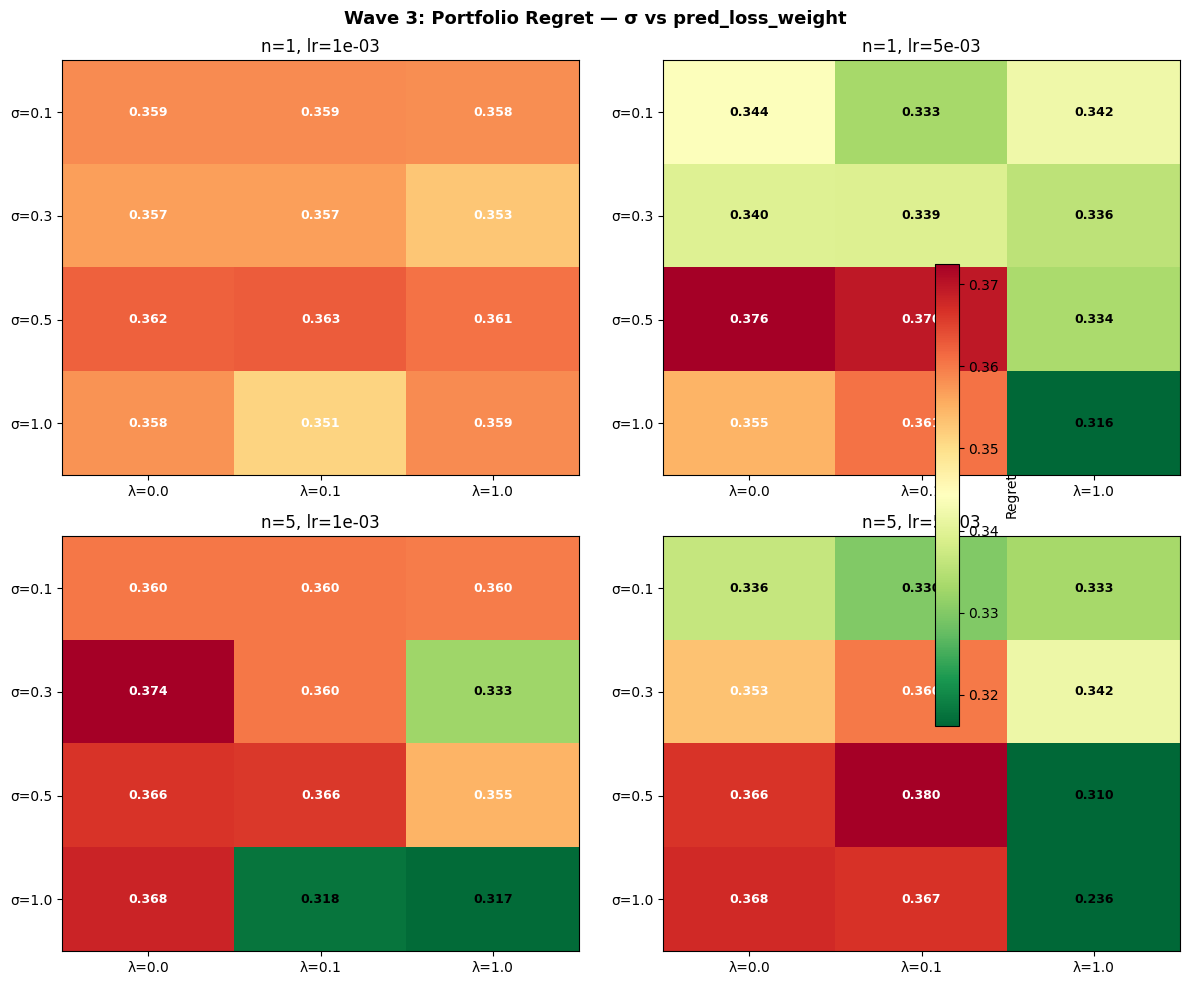

In [38]:
# ── 2×2 Heatmap grid: (n_samples × lr) panels, each σ vs plw ─────────

if len(w3_done) >= 20:
    sigma_vals_w3 = sorted(w3_done["sigma"].unique())
    plw_vals_w3 = sorted(w3_done["plw"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Compute shared colormap range (using quantiles)
    all_regrets = w3_done["regret"].dropna()
    vmin_w3 = all_regrets.quantile(0.05) if len(all_regrets) > 5 else all_regrets.min()
    vmax_w3 = all_regrets.quantile(0.95) if len(all_regrets) > 5 else all_regrets.max()

    panels = [(1, "lr1e3", 1e-3), (1, "lr5e3", 5e-3), (5, "lr1e3", 1e-3), (5, "lr5e3", 5e-3)]

    for idx, (n_s, lr_tag_w3, lr_val_w3) in enumerate(panels):
        ax = axes[idx // 2, idx % 2]
        sub = w3_done[(w3_done["n_samples"] == n_s) & (w3_done["lr_tag"] == lr_tag_w3)]

        heat_w3 = np.full((len(sigma_vals_w3), len(plw_vals_w3)), np.nan)
        for si_w3, sv in enumerate(sigma_vals_w3):
            for pi_w3, pv in enumerate(plw_vals_w3):
                match = sub[(sub["sigma"] == sv) & (sub["plw"] == pv)]
                if len(match) > 0:
                    heat_w3[si_w3, pi_w3] = match["regret"].values[0]

        im_w3 = ax.imshow(heat_w3, cmap="RdYlGn_r", aspect="auto",
                          vmin=vmin_w3, vmax=vmax_w3)
        ax.set_xticks(range(len(plw_vals_w3)))
        ax.set_xticklabels([f"λ={v}" for v in plw_vals_w3])
        ax.set_yticks(range(len(sigma_vals_w3)))
        ax.set_yticklabels([f"σ={v}" for v in sigma_vals_w3])
        ax.set_title(f"n={n_s}, lr={lr_val_w3:.0e}")

        for si_w3 in range(len(sigma_vals_w3)):
            for pi_w3 in range(len(plw_vals_w3)):
                val_w3 = heat_w3[si_w3, pi_w3]
                if not np.isnan(val_w3):
                    ax.text(pi_w3, si_w3, f"{val_w3:.3f}", ha="center", va="center",
                            fontsize=9, fontweight="bold",
                            color="white" if val_w3 > (vmin_w3 + vmax_w3) / 2 else "black")

    fig.colorbar(im_w3, ax=axes, shrink=0.6, label="Regret")
    fig.suptitle("Wave 3: Portfolio Regret — σ vs pred_loss_weight",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print(f"Only {len(w3_done)} results — need ≥20 for heatmaps")

### Wave 3: Training Traces + σ/|θ̂| Diagnostics — Top configs vs W1/W2 baselines

W3: 48/48 traces, 2 baselines


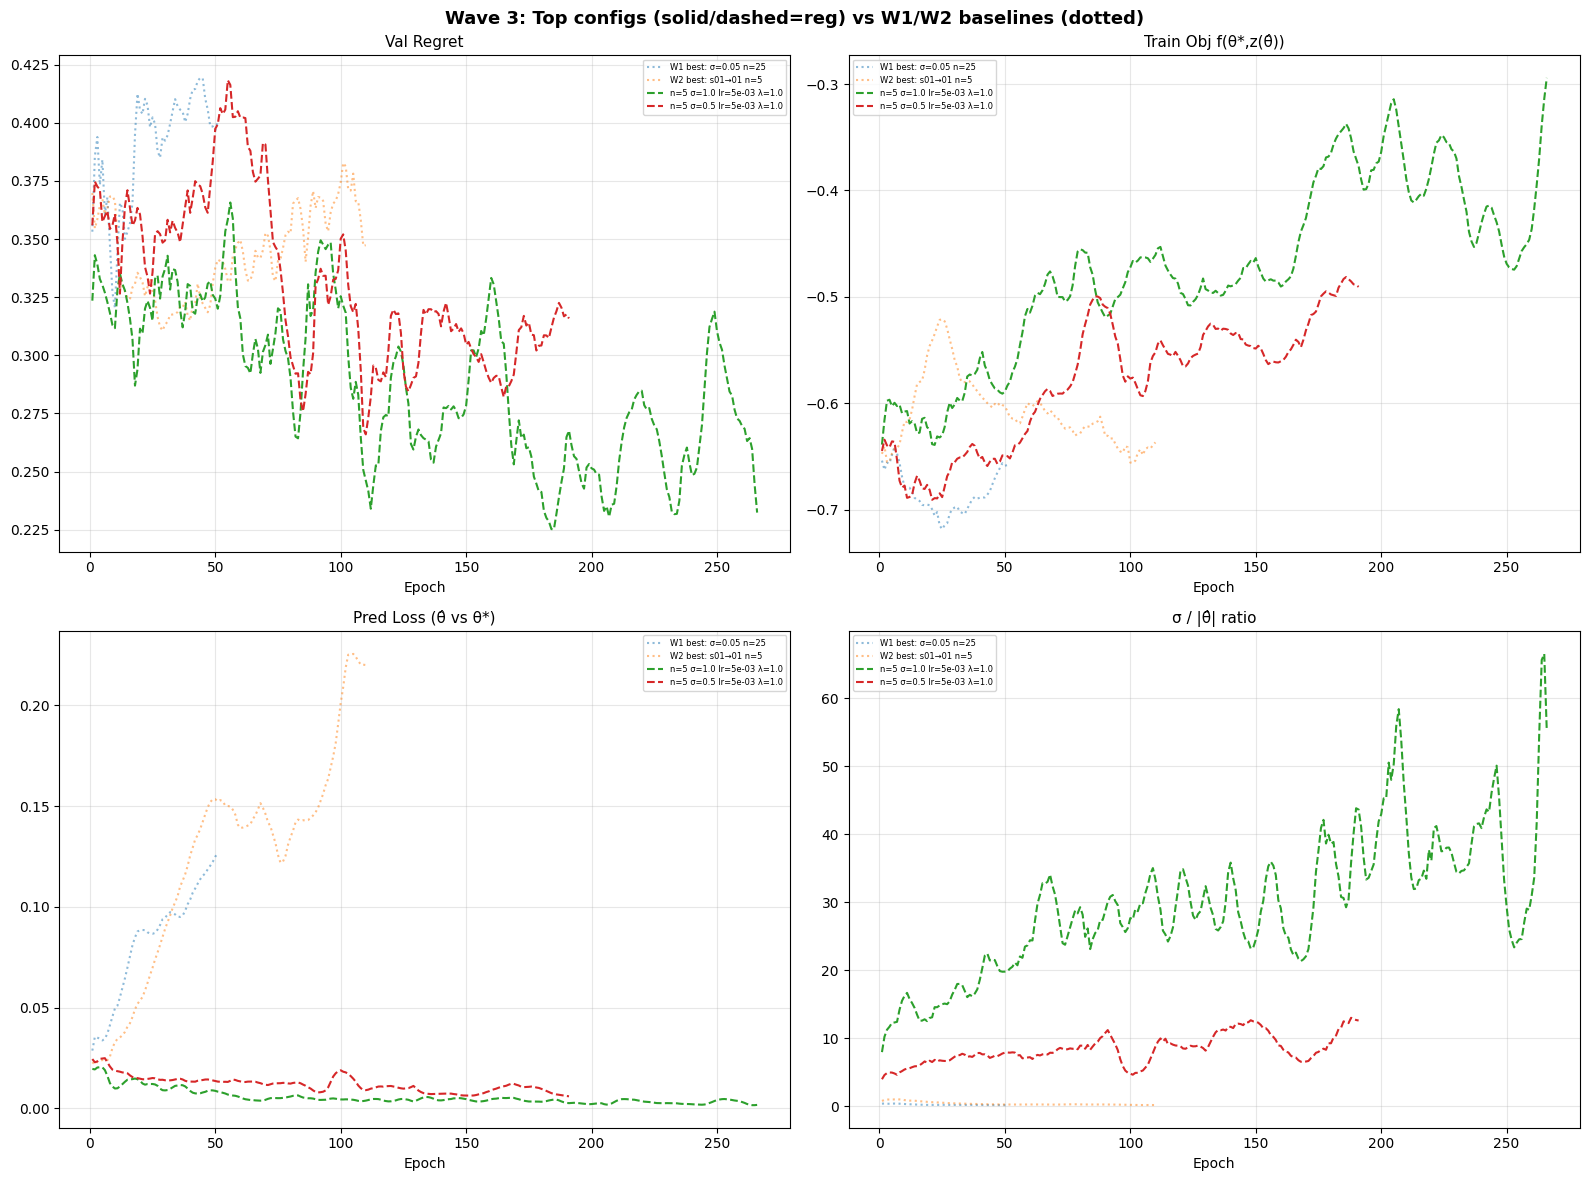


Top Wave 3 configs:
  1. n=5 σ=1.0 lr=5e-03 λ=1.0                       val_regret=0.2252
  2. n=5 σ=0.5 lr=5e-03 λ=1.0                       val_regret=0.2660
  baseline: W1 best: σ=0.05 n=25                        val_regret=0.3204
  baseline: W2 best: s01→01 n=5                         val_regret=0.3106


In [39]:
W3_TOP_K = 2

# ── Collect W3 traces with diagnostics ───────────────────────────────
w3_traces = []
for exp_key, exp in W3_EXPERIMENTS.items():
    tdf, vdf, ddf = read_full_traces(exp["data_name"], exp["prefix"])
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        plw_str = f" λ={exp['pred_loss_weight']}" if exp["pred_loss_weight"] > 0 else ""
        label = f"n={exp['n_samples']} σ={exp['sigma']} lr={exp['lr']:.0e}{plw_str}"
        w3_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val,
            "n_samples": exp["n_samples"],
            "plw": exp["pred_loss_weight"],
        })

# Reference baselines: best W1 and best W2
baselines = []
tdf, vdf, ddf = read_full_traces("portfolio-real", "sd1_s005_lr5e3")
if tdf is not None:
    baselines.append({"label": "W1 best: σ=0.05 n=25", "train": tdf, "val": vdf, "diag": ddf,
                       "best_val_regret": get_best_val_regret(vdf)})
tdf, vdf, ddf = read_full_traces("portfolio-real", "sd1_lin_s01to001_w0_lr5e3")
if tdf is not None:
    baselines.append({"label": "W2 best: s01→01 n=5", "train": tdf, "val": vdf, "diag": ddf,
                       "best_val_regret": get_best_val_regret(vdf)})

print(f"W3: {len(w3_traces)}/48 traces, {len(baselines)} baselines")

if len(w3_traces) > 0:
    w3_traces.sort(key=lambda t: t["best_val_regret"])
    w3_sel = w3_traces[:W3_TOP_K]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    plot_specs = [
        ("Val Regret", "val", "regret", axes[0, 0]),
        ("Train Obj f(θ*,z(θ̂))", "train", "obj", axes[0, 1]),
        ("Pred Loss (θ̂ vs θ*)", "train", "pred_loss", axes[1, 0]),
        ("σ / |θ̂| ratio", "diag", "sigma_over_coeff", axes[1, 1]),
    ]

    for title, source, col, ax in plot_specs:
        # Baselines (dotted)
        for i, bl in enumerate(baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ep_col = "epoch" if "epoch" in df_bl.columns else "epoch_num"
                ax.plot(df_bl[ep_col], df_bl[col],
                        color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1.5,
                        label=bl["label"])
        # W3 top configs (solid, dashed for plw>0)
        for i, tr in enumerate(w3_sel):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ep_col = "epoch" if "epoch" in df_tr.columns else "epoch_num"
                ls = "--" if tr["plw"] > 0 else "-"
                ax.plot(df_tr[ep_col], df_tr[col],
                        color=f"C{len(baselines)+i}", linewidth=1.5, linestyle=ls,
                        label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=6); ax.grid(True, alpha=0.3)
    #ax.set_ylim(top=1)
    fig.suptitle("Wave 3: Top configs (solid/dashed=reg) vs W1/W2 baselines (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Ranking
    print("\nTop Wave 3 configs:")
    for i, tr in enumerate(w3_sel):
        print(f"  {i+1}. {tr['label']:45s}  val_regret={tr['best_val_regret']:.4f}")
    for bl in baselines:
        print(f"  baseline: {bl['label']:42s}  val_regret={bl['best_val_regret']:.4f}")
else:
    print("No W3 traces yet.")

### Wave 3: SLURM Error Scanner

In [40]:
import glob

w3_err_files = sorted(glob.glob("logs/slurm/pco_portfolio_sd1_w3_*.err"))
print(f"Found {len(w3_err_files)} Wave 3 error files\n")

w3_problems = 0
for f in w3_err_files:
    with open(f) as fh:
        content = fh.read()
    lines = content.strip().split("\n")
    error_lines = [l for l in lines
                   if any(kw in l.lower() for kw in ["error", "traceback", "exception", "killed", "oom"])
                   and "deprecat" not in l.lower() and "warning" not in l.lower()]
    if error_lines:
        w3_problems += 1
        short_name = os.path.basename(f)
        print(f"⚠ {short_name}:")
        for l in error_lines[:5]:
            print(f"   {l.strip()}")
        print()

if w3_problems == 0:
    print("✓ No errors detected in any Wave 3 SLURM logs.")

Found 48 Wave 3 error files

✓ No errors detected in any Wave 3 SLURM logs.


## Wave 4 — Portfolio: small sigma (0.01, 0.05)

Same grid as Wave 3 but exploring the small-σ regime.

**Grid**: 2 `n_samples` × 2 `σ` × 2 `lr` × 3 `λ` = **24 experiments**

| Axis | Values |
|------|--------|
| `n_samples` | 1, 5 |
| `σ` | 0.01, 0.05 |
| `lr` | 1e-3, 5e-3 |
| `pred_loss_weight` | 0, 0.1, 1.0 |

All runs: constant sigma, 400 epochs, patience=80, solver=cvxpy.

In [41]:
# ── Wave 4 Registry ──────────────────────────────────────────────────
W4_N_SAMPLES = [1, 5]
W4_SIGMAS = {"s001": 0.01, "s005": 0.05}
W4_LRS = {"lr1e3": 1e-3, "lr5e3": 5e-3}
W4_PLWS = {"plw0": 0.0, "plw01": 0.1, "plw10": 1.0}

W4_EXPERIMENTS = {}
for n in W4_N_SAMPLES:
    for stag, sigma in W4_SIGMAS.items():
        for ptag, plw in W4_PLWS.items():
            for lr_tag, lr_val in W4_LRS.items():
                prefix = f"sd1_w4_n{n}_{stag}_{ptag}_{lr_tag}"
                exp_key = f"w4_n{n}_{stag}_{ptag}_{lr_tag}"
                W4_EXPERIMENTS[exp_key] = {
                    "data_name": "portfolio-real",
                    "prefix": prefix,
                    "n_samples": n,
                    "sigma": sigma,
                    "lr": lr_val,
                    "pred_loss_weight": plw,
                    "sigma_tag": stag,
                    "lr_tag": lr_tag,
                    "plw_tag": ptag,
                }

print(f"Wave 4: registered {len(W4_EXPERIMENTS)} experiments")
print(f"Grid: {len(W4_N_SAMPLES)} n × {len(W4_SIGMAS)} σ × {len(W4_LRS)} lr × {len(W4_PLWS)} λ")

Wave 4: registered 24 experiments
Grid: 2 n × 2 σ × 2 lr × 3 λ


### Launch / Status

In [42]:
!bash shells/slurm/submit_portfolio_wave4.sh --dry-run 2>&1 | head -15 && echo "..." && bash shells/slurm/submit_portfolio_wave4.sh --dry-run 2>&1 | tail -8

Wave 4 — Portfolio: small sigma × n_samples × pred_loss_reg
Grid: 2 n × 2 σ × 2 lr × 3 λ = 24 experiments
Schedule: constant sigma, n_epochs=400, patience=80
Primary:  preempt
Backup:   hugheslab,gpu (afternotok dependency)
Time: 24:00:00  Mem: 16G  GRES: gpu:1
*** DRY RUN MODE ***
Skip completed: ON
Total experiments: 24

[SKIP] pco_portfolio_sd1_w4_n1_s001_plw0_lr1e3 — already completed
[SKIP] pco_portfolio_sd1_w4_n1_s001_plw0_lr5e3 — already completed
...

Submitted: 0 experiments
  → 0 primary (preempt) + 0 backup (hugheslab,gpu)
  → Total SLURM jobs: 0
Skipped (completed): 24

Dry run complete. No jobs submitted.


In [43]:
#!bash shells/slurm/submit_portfolio_wave4.sh

In [44]:
!squeue --me | grep pco_portfolio_sd1_w4 | wc -l && echo "W4 jobs" && squeue --me | grep pco_portfolio_sd1_w4 | head -10

0
W4 jobs


### Collect Wave 4 Results

In [45]:
# ── Collect Wave 4 results ────────────────────────────────────────────
w4_rows = []
for exp_key, exp in W4_EXPERIMENTS.items():
    result = read_result(exp["data_name"], exp["prefix"])
    row = {
        "experiment": exp_key,
        "prefix": exp["prefix"],
        "n_samples": exp["n_samples"],
        "sigma": exp["sigma"],
        "lr": exp["lr"],
        "plw": exp["pred_loss_weight"],
        "sigma_tag": exp["sigma_tag"],
        "lr_tag": exp["lr_tag"],
        "plw_tag": exp["plw_tag"],
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    w4_rows.append(row)

w4_df = pd.DataFrame(w4_rows)
w4_done = w4_df[w4_df["status"] == "done"]
w4_pending = w4_df[w4_df["status"] == "pending"]
print(f"Wave 4: {len(w4_done)}/{len(w4_df)} completed")

if len(w4_done) > 0:
    w1_best_regret_port = 0.3514  # sd1_s005_lr5e3
    w3_best = w3_done["regret"].min() if len(w3_done) > 0 else float("inf")

    best_w4 = w4_done.sort_values("regret").head(10)
    print(f"\nW1 best regret: {w1_best_regret_port:.4f}")
    print(f"W3 best regret: {w3_best:.4f}")
    print(f"\nTop 10 Wave 4 configs:")
    for _, r in best_w4.iterrows():
        flag = " ★" if r["regret"] < min(w1_best_regret_port, w3_best) else ""
        print(f"  n={r['n_samples']} σ={r['sigma']:<5} λ={r['plw']:<4} lr={r['lr']:.0e}  "
              f"regret={r['regret']:.4f}  obj={r['objective']:.4f}{flag}")
else:
    print("\nNo results available yet.")
    if len(w4_pending) > 0:
        print(f"{len(w4_pending)} experiments pending")

Wave 4: 24/24 completed

W1 best regret: 0.3514
W3 best regret: 0.2361

Top 10 Wave 4 configs:
  n=5 σ=0.01  λ=1.0  lr=1e-03  regret=0.3135  obj=-0.5903
  n=5 σ=0.05  λ=1.0  lr=1e-03  regret=0.3180  obj=-0.5900
  n=1 σ=0.05  λ=0.1  lr=5e-03  regret=0.3243  obj=-0.6087
  n=5 σ=0.05  λ=1.0  lr=5e-03  regret=0.3256  obj=-0.5755
  n=5 σ=0.01  λ=0.1  lr=1e-03  regret=0.3298  obj=-0.6074
  n=1 σ=0.01  λ=1.0  lr=5e-03  regret=0.3336  obj=-0.6226
  n=1 σ=0.01  λ=0.1  lr=5e-03  regret=0.3336  obj=-0.6228
  n=1 σ=0.01  λ=0.0  lr=5e-03  regret=0.3336  obj=-0.6228
  n=1 σ=0.01  λ=0.0  lr=1e-03  regret=0.3340  obj=-0.6252
  n=1 σ=0.01  λ=0.1  lr=1e-03  regret=0.3341  obj=-0.6255


### Wave 4: Pivot tables + W3 comparison

In [46]:
# ── W4 pivot tables ──────────────────────────────────────────────────

if len(w4_done) >= 8:
    # Best regret by (n_samples, sigma)
    n_sigma_best_w4 = (w4_done.groupby(["n_samples", "sigma"])["regret"]
                       .min().reset_index()
                       .pivot(index="sigma", columns="n_samples", values="regret"))
    print("Best regret by (σ, n_samples) — marginalized over lr and plw:")
    print(n_sigma_best_w4.to_string(float_format="{:.4f}".format))
    print()

    # Best regret by (n_samples, plw)
    n_plw_best_w4 = (w4_done.groupby(["n_samples", "plw"])["regret"]
                     .min().reset_index()
                     .pivot(index="plw", columns="n_samples", values="regret"))
    print("Best regret by (pred_loss_weight, n_samples):")
    print(n_plw_best_w4.to_string(float_format="{:.4f}".format))
    print()

    # Combined W3+W4: best regret by sigma across ALL portfolio DPO experiments
    if len(w3_done) > 0:
        combined = pd.concat([w3_done, w4_done], ignore_index=True)
        sigma_overview = combined.groupby("sigma")["regret"].min().sort_index()
        print("Best regret by σ (combined W3+W4):")
        for sv, rv in sigma_overview.items():
            print(f"  σ={sv:<5}: {rv:.4f}")
else:
    print(f"Only {len(w4_done)} results — need more for pivot tables.")

Best regret by (σ, n_samples) — marginalized over lr and plw:
n_samples      1      5
sigma                  
0.0100    0.3336 0.3135
0.0500    0.3243 0.3180

Best regret by (pred_loss_weight, n_samples):
n_samples      1      5
plw                    
0.0000    0.3336 0.3466
0.1000    0.3243 0.3298
1.0000    0.3336 0.3135

Best regret by σ (combined W3+W4):
  σ=0.01 : 0.3135
  σ=0.05 : 0.3180
  σ=0.1  : 0.3298
  σ=0.3  : 0.3325
  σ=0.5  : 0.3105
  σ=1.0  : 0.2361


### Wave 4: Heatmaps

/tmp/ipykernel_2814785/2807590947.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 0.95])


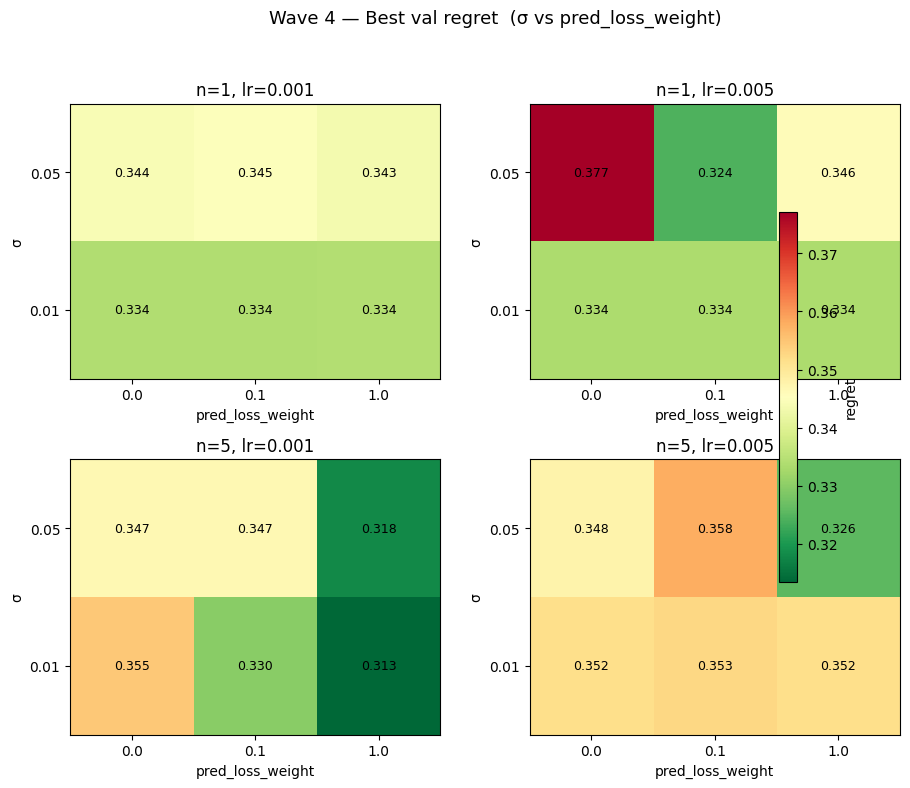

In [47]:
# ── W4 heatmaps: σ vs pred_loss_weight, 2×2 grid (n_samples × lr) ──

import matplotlib.pyplot as plt
import numpy as np

if len(w4_done) >= 8:
    sigma_vals_w4 = sorted(w4_done["sigma"].unique())
    plw_vals_w4   = sorted(w4_done["plw"].unique())
    ns_vals_w4    = sorted(w4_done["n_samples"].unique())
    lr_vals_w4    = sorted(w4_done["lr"].unique())

    fig, axes = plt.subplots(len(ns_vals_w4), len(lr_vals_w4),
                             figsize=(5*len(lr_vals_w4), 4*len(ns_vals_w4)),
                             squeeze=False)
    fig.suptitle("Wave 4 — Best val regret  (σ vs pred_loss_weight)", fontsize=13)

    all_regrets_w4 = w4_done["regret"].dropna()
    vmin_w4 = all_regrets_w4.min() if len(all_regrets_w4) else 0
    vmax_w4 = all_regrets_w4.max() if len(all_regrets_w4) else 1

    for ri, ns in enumerate(ns_vals_w4):
        for ci, lr in enumerate(lr_vals_w4):
            ax = axes[ri][ci]
            grid = np.full((len(sigma_vals_w4), len(plw_vals_w4)), np.nan)
            sub = w4_done[(w4_done["n_samples"] == ns) & (w4_done["lr"] == lr)]
            for _, row in sub.iterrows():
                si = sigma_vals_w4.index(row["sigma"])
                pi = plw_vals_w4.index(row["plw"])
                grid[si, pi] = row["regret"]
            im = ax.imshow(grid, vmin=vmin_w4, vmax=vmax_w4,
                           cmap="RdYlGn_r", origin="lower", aspect="auto")
            ax.set_xticks(range(len(plw_vals_w4)))
            ax.set_xticklabels([str(v) for v in plw_vals_w4])
            ax.set_yticks(range(len(sigma_vals_w4)))
            ax.set_yticklabels([str(v) for v in sigma_vals_w4])
            ax.set_xlabel("pred_loss_weight")
            ax.set_ylabel("σ")
            ax.set_title(f"n={ns}, lr={lr}")
            for si in range(len(sigma_vals_w4)):
                for pi in range(len(plw_vals_w4)):
                    v = grid[si, pi]
                    if not np.isnan(v):
                        ax.text(pi, si, f"{v:.3f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=axes, shrink=0.6, label="regret")
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])
    plt.show()
else:
    print(f"Only {len(w4_done)} results — waiting for more.")

### Wave 4: Training Traces + Diagnostics

W4: 24/24 traces, 2 baselines


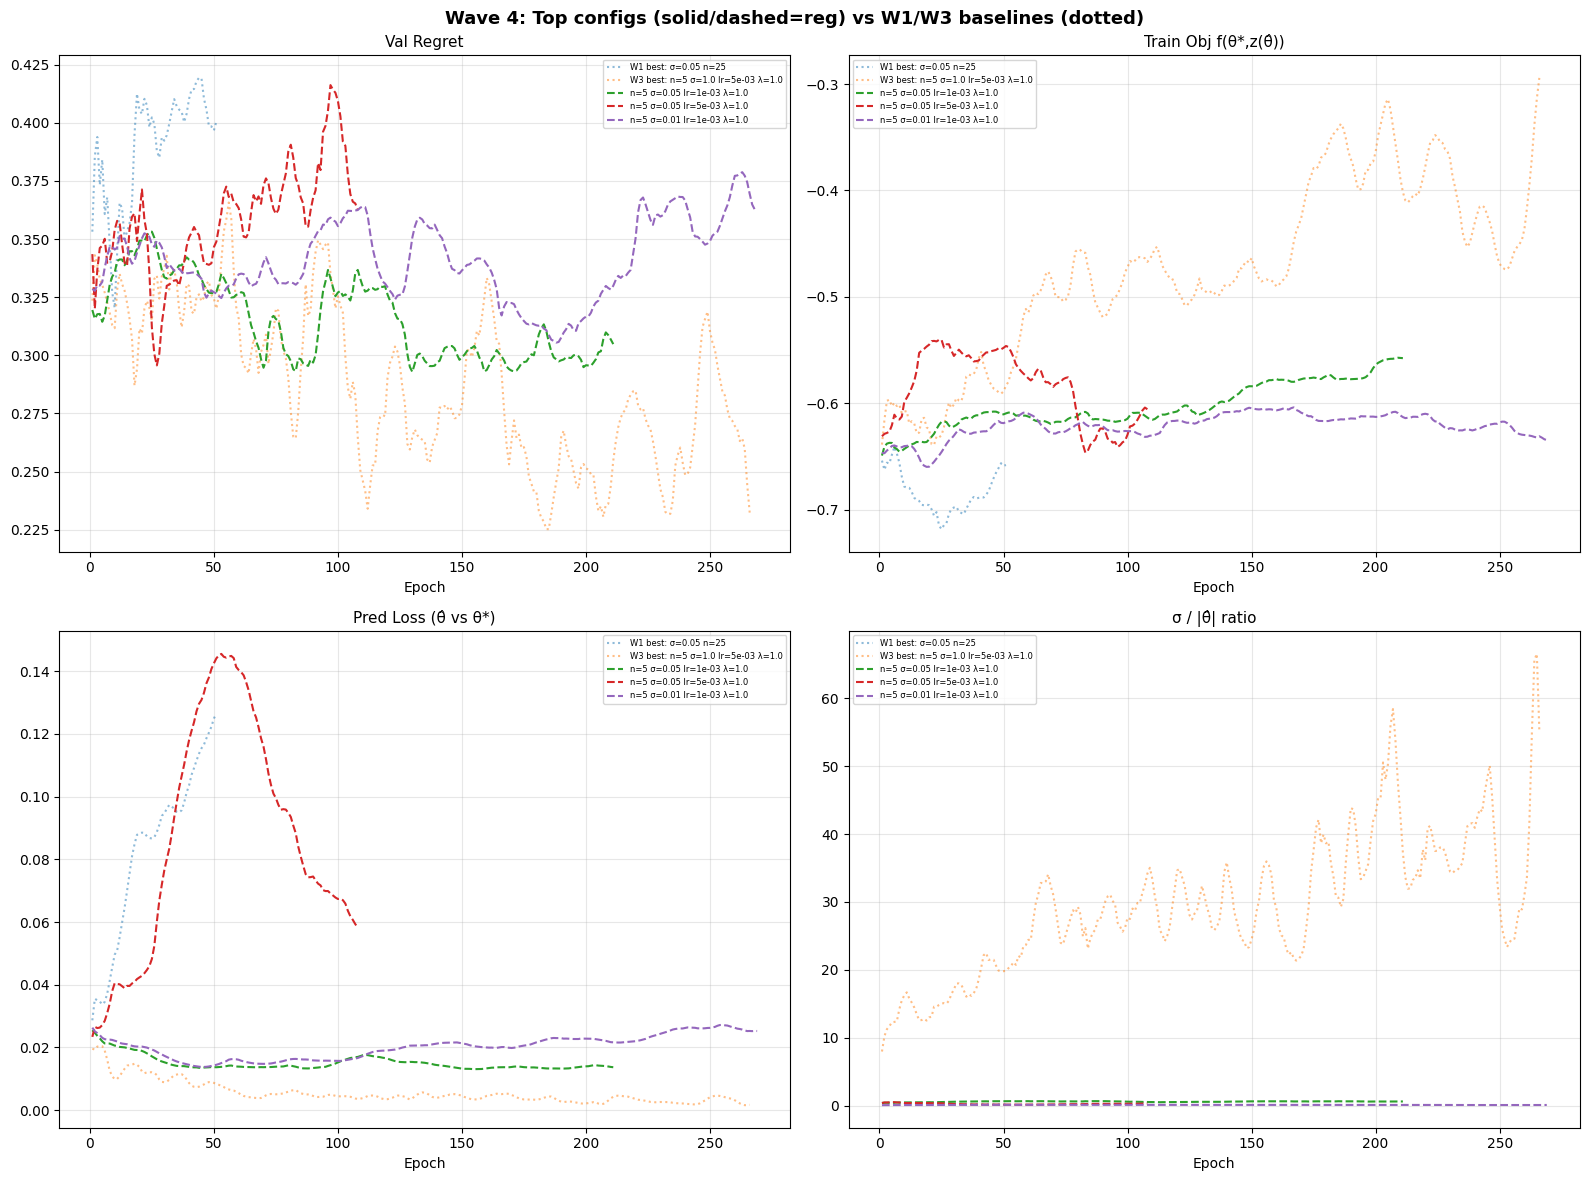


Top Wave 4 configs:
  1. n=5 σ=0.05 lr=1e-03 λ=1.0                      val_regret=0.2928
  2. n=5 σ=0.05 lr=5e-03 λ=1.0                      val_regret=0.2956
  3. n=5 σ=0.01 lr=1e-03 λ=1.0                      val_regret=0.3054
  baseline: W1 best: σ=0.05 n=25                        val_regret=0.3204
  baseline: W3 best: n=5 σ=1.0 lr=5e-03 λ=1.0           val_regret=0.2252


In [48]:
W4_TOP_K = 3

# ── Collect W4 traces with diagnostics ───────────────────────────────
w4_traces = []
for exp_key, exp in W4_EXPERIMENTS.items():
    tdf, vdf, ddf = read_full_traces(exp["data_name"], exp["prefix"])
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        plw_str = f" λ={exp['pred_loss_weight']}" if exp["pred_loss_weight"] > 0 else ""
        label = f"n={exp['n_samples']} σ={exp['sigma']} lr={exp['lr']:.0e}{plw_str}"
        w4_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val,
            "n_samples": exp["n_samples"],
            "plw": exp["pred_loss_weight"],
        })

# Reference baselines: best W1 and best W3
w4_baselines = []
tdf, vdf, ddf = read_full_traces("portfolio-real", "sd1_s005_lr5e3")
if tdf is not None:
    w4_baselines.append({"label": "W1 best: σ=0.05 n=25", "train": tdf, "val": vdf, "diag": ddf,
                         "best_val_regret": get_best_val_regret(vdf)})
# Add best W3 as baseline (if available)
if len(w3_traces) > 0:
    w3_best = min(w3_traces, key=lambda t: t["best_val_regret"])
    w4_baselines.append({"label": f"W3 best: {w3_best['label']}", "train": w3_best["train"],
                         "val": w3_best["val"], "diag": w3_best["diag"],
                         "best_val_regret": w3_best["best_val_regret"]})

print(f"W4: {len(w4_traces)}/24 traces, {len(w4_baselines)} baselines")

if len(w4_traces) > 0:
    w4_traces.sort(key=lambda t: t["best_val_regret"])
    w4_sel = w4_traces[:W4_TOP_K]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    plot_specs_w4 = [
        ("Val Regret", "val", "regret", axes[0, 0]),
        ("Train Obj f(θ*,z(θ̂))", "train", "obj", axes[0, 1]),
        ("Pred Loss (θ̂ vs θ*)", "train", "pred_loss", axes[1, 0]),
        ("σ / |θ̂| ratio", "diag", "sigma_over_coeff", axes[1, 1]),
    ]

    for title, source, col, ax in plot_specs_w4:
        # Baselines (dotted)
        for i, bl in enumerate(w4_baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ep_col = "epoch" if "epoch" in df_bl.columns else "epoch_num"
                ax.plot(df_bl[ep_col], df_bl[col],
                        color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1.5,
                        label=bl["label"])
        # W4 top configs (solid, dashed for plw>0)
        for i, tr in enumerate(w4_sel):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ep_col = "epoch" if "epoch" in df_tr.columns else "epoch_num"
                ls = "--" if tr["plw"] > 0 else "-"
                ax.plot(df_tr[ep_col], df_tr[col],
                        color=f"C{len(w4_baselines)+i}", linewidth=1.5, linestyle=ls,
                        label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    fig.suptitle("Wave 4: Top configs (solid/dashed=reg) vs W1/W3 baselines (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Ranking
    print("\nTop Wave 4 configs:")
    for i, tr in enumerate(w4_sel):
        print(f"  {i+1}. {tr['label']:45s}  val_regret={tr['best_val_regret']:.4f}")
    for bl in w4_baselines:
        print(f"  baseline: {bl['label']:42s}  val_regret={bl['best_val_regret']:.4f}")
else:
    print("No W4 traces yet.")

### Wave 4: SLURM Error Scanner

In [49]:
import glob

w4_err_files = sorted(glob.glob("logs/slurm/pco_portfolio_sd1_w4_*.err"))
print(f"Found {len(w4_err_files)} Wave 4 error files\n")

w4_problems = 0
for f in w4_err_files:
    with open(f) as fh:
        content = fh.read()
    lines = content.strip().split("\n")
    error_lines = [l for l in lines
                   if any(kw in l.lower() for kw in ["error", "traceback", "exception", "killed", "oom"])
                   and "deprecat" not in l.lower() and "warning" not in l.lower()]
    if error_lines:
        w4_problems += 1
        short_name = os.path.basename(f)
        print(f"⚠ {short_name}:")
        for l in error_lines[:5]:
            print(f"   {l.strip()}")
        print()

if w4_problems == 0:
    print("✓ No errors detected in any Wave 4 SLURM logs.")

Found 24 Wave 4 error files

✓ No errors detected in any Wave 4 SLURM logs.


## Wave 2 — Knapsack: n_samples × larger sigma × pred_loss regularization

**Motivation**: W1 showed a strong monotonic trend: σ=0.5 >> 0.1 >> 0.05.
Best run (σ=0.5, lr=5e-3) exhausted patience=40 at epoch 256 while still improving
(best at epoch 215). Also, pred_loss was growing steadily, suggesting θ̂ drift.

**Key questions**:
1. Does even larger σ (1.0, 2.0) continue to help?
2. Does smaller n_samples (1, 5 vs W1's 25) regularize θ̂ growth (portfolio insight)?
3. Does pred_loss_weight regularization prevent the drift?
4. Does more patience/epochs let training converge?

**Grid**: 2 `n_samples` × 3 `σ` × 2 `lr` × 2 `λ` = **24 experiments**

| Axis | Values | Rationale |
|------|--------|-----------|
| `n_samples` | 1, 5 | Smaller n → implicit regularization |
| `σ` | 0.5, 1.0, 2.0 | Push the "larger is better" trend |
| `lr` | 1e-3, 5e-3 | Both worked at σ=0.5 in W1 |
| `pred_loss_weight` | 0, 0.1 | Explicit θ̂ regularization |

All runs: constant sigma, 500 epochs, patience=80 (double W1).
Solver: gurobi.

In [50]:
# ── Knapsack Wave 2 Registry ────────────────────────────────────────
KN_N_SAMPLES = [1, 5]
KN_SIGMAS = {"s05": 0.5, "s10": 1.0, "s20": 2.0}
KN_LRS = {"lr1e3": 1e-3, "lr5e3": 5e-3}
KN_PLWS = {"plw0": 0.0, "plw01": 0.1}

KN_EXPERIMENTS = {}
for n in KN_N_SAMPLES:
    for stag, sigma in KN_SIGMAS.items():
        for ptag, plw in KN_PLWS.items():
            for lr_tag, lr_val in KN_LRS.items():
                prefix = f"sd1_kn_n{n}_{stag}_{ptag}_{lr_tag}"
                exp_key = f"kn_n{n}_{stag}_{ptag}_{lr_tag}"
                KN_EXPERIMENTS[exp_key] = {
                    "data_name": "knapsack-gen",
                    "prefix": prefix,
                    "n_samples": n,
                    "sigma": sigma,
                    "lr": lr_val,
                    "pred_loss_weight": plw,
                    "sigma_tag": stag,
                    "lr_tag": lr_tag,
                    "plw_tag": ptag,
                }

print(f"Knapsack W2: registered {len(KN_EXPERIMENTS)} experiments")
print(f"Grid: {len(KN_N_SAMPLES)} n × {len(KN_SIGMAS)} σ × {len(KN_LRS)} lr × {len(KN_PLWS)} λ")

Knapsack W2: registered 24 experiments
Grid: 2 n × 3 σ × 2 lr × 2 λ


### Launch / Status

In [51]:
!bash shells/slurm/submit_knapsack_wave2.sh --dry-run 2>&1 | head -15 && echo "..." && bash shells/slurm/submit_knapsack_wave2.sh --dry-run 2>&1 | tail -8

Wave 2 — Knapsack: n_samples × sigma × pred_loss_reg
Grid: 2 n × 3 σ × 2 lr × 2 λ = 24 experiments
Schedule: constant sigma, n_epochs=500, patience=80
Primary:  preempt
Backup:   hugheslab,gpu (afternotok dependency)
Time: 24:00:00  Mem: 16G  GRES: gpu:1
*** DRY RUN MODE ***
Skip completed: ON
Total experiments: 24

[SKIP] pco_knapsack_sd1_kn_n1_s05_plw0_lr1e3 — already completed
[SKIP] pco_knapsack_sd1_kn_n1_s05_plw0_lr5e3 — already completed
...

Submitted: 6 experiments
  → 6 primary (preempt) + 6 backup (hugheslab,gpu)
  → Total SLURM jobs: 12
Skipped (completed): 18

Dry run complete. No jobs submitted.


In [52]:
#!bash shells/slurm/submit_knapsack_wave2.sh

In [53]:
!squeue --me | grep pco_knapsack | wc -l && echo "knapsack W2 jobs" && squeue --me | grep pco_knapsack | head -10

0
knapsack W2 jobs


### Collect Knapsack Wave 2 Results

In [54]:
# ── Collect Knapsack Wave 2 results ──────────────────────────────────
kn_rows = []
for exp_key, exp in KN_EXPERIMENTS.items():
    result = read_result(exp["data_name"], exp["prefix"])
    row = {
        "experiment": exp_key,
        "prefix": exp["prefix"],
        "n_samples": exp["n_samples"],
        "sigma": exp["sigma"],
        "lr": exp["lr"],
        "plw": exp["pred_loss_weight"],
        "sigma_tag": exp["sigma_tag"],
        "lr_tag": exp["lr_tag"],
        "plw_tag": exp["plw_tag"],
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    kn_rows.append(row)

kn_df = pd.DataFrame(kn_rows)
kn_done = kn_df[kn_df["status"] == "done"]
kn_pending = kn_df[kn_df["status"] == "pending"]
print(f"Knapsack W2: {len(kn_done)}/{len(kn_df)} completed")

if len(kn_done) > 0:
    # Compare with W1 best
    w1_kn_best = 3.58  # sd1_s05_lr5e3

    best_kn = kn_done.sort_values("regret").head(10)
    print(f"\nW1 best regret: {w1_kn_best:.4f}")
    print(f"\nTop 10 Knapsack W2 configs:")
    for _, r in best_kn.iterrows():
        flag = " ★" if r["regret"] < w1_kn_best else ""
        print(f"  n={r['n_samples']} σ={r['sigma']:<4} λ={r['plw']:<4} lr={r['lr']:.0e}  "
              f"regret={r['regret']:.4f}  obj={r['objective']:.4f}{flag}")
else:
    print("\nNo results available yet.")
    if len(kn_pending) > 0:
        print(f"{len(kn_pending)} experiments pending")

Knapsack W2: 18/24 completed

W1 best regret: 3.5800

Top 10 Knapsack W2 configs:
  n=5 σ=1.0  λ=0.0  lr=5e-03  regret=4.1400  obj=32.1750
  n=5 σ=1.0  λ=0.1  lr=5e-03  regret=5.0950  obj=31.2200
  n=5 σ=1.0  λ=0.1  lr=1e-03  regret=5.1350  obj=31.1800
  n=5 σ=2.0  λ=0.1  lr=5e-03  regret=5.1700  obj=31.1450
  n=5 σ=1.0  λ=0.0  lr=1e-03  regret=5.3250  obj=30.9900
  n=5 σ=2.0  λ=0.1  lr=1e-03  regret=5.3450  obj=30.9700
  n=5 σ=2.0  λ=0.0  lr=5e-03  regret=5.4800  obj=30.8350
  n=5 σ=2.0  λ=0.0  lr=1e-03  regret=5.5100  obj=30.8050
  n=1 σ=1.0  λ=0.0  lr=5e-03  regret=5.8400  obj=30.4750
  n=1 σ=0.5  λ=0.1  lr=5e-03  regret=5.8500  obj=30.4650


### Knapsack W2: n_samples × σ effect

In [55]:
# ── n_samples × sigma comparison ──────────────────────────────────────

if len(kn_done) >= 10:
    # Best regret for each (n_samples, sigma) cell
    n_sigma_best_kn = (kn_done.groupby(["n_samples", "sigma"])["regret"]
                       .min().reset_index()
                       .pivot(index="sigma", columns="n_samples", values="regret"))
    print("Best regret by (σ, n_samples) — marginalized over lr and pred_loss_weight:")
    print(n_sigma_best_kn.to_string(float_format="{:.4f}".format))
    print()

    # Best regret for each (n_samples, plw) cell
    n_plw_best_kn = (kn_done.groupby(["n_samples", "plw"])["regret"]
                     .min().reset_index()
                     .pivot(index="plw", columns="n_samples", values="regret"))
    print("Best regret by (pred_loss_weight, n_samples):")
    print(n_plw_best_kn.to_string(float_format="{:.4f}".format))
    print()

    # Does larger sigma help for knapsack?
    sigma_best_kn = kn_done.groupby("sigma")["regret"].min()
    print("Best regret by σ (marginalized over n, lr, plw):")
    for sv, rv in sigma_best_kn.items():
        print(f"  σ={sv}: {rv:.4f}")
else:
    print(f"Only {len(kn_done)} results so far — need more to compare.")

Best regret by (σ, n_samples) — marginalized over lr and pred_loss_weight:
n_samples      1      5
sigma                  
0.5000    5.8500 5.8700
1.0000    5.8400 4.1400
2.0000    6.3100 5.1700

Best regret by (pred_loss_weight, n_samples):
n_samples      1      5
plw                    
0.0000    5.8400 4.1400
0.1000    5.8500 5.0950

Best regret by σ (marginalized over n, lr, plw):
  σ=0.5: 5.8500
  σ=1.0: 4.1400
  σ=2.0: 5.1700


### Knapsack W2: Heatmaps — Regret by (σ, pred_loss_weight), one panel per n_samples×lr

/tmp/ipykernel_2814785/811806329.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


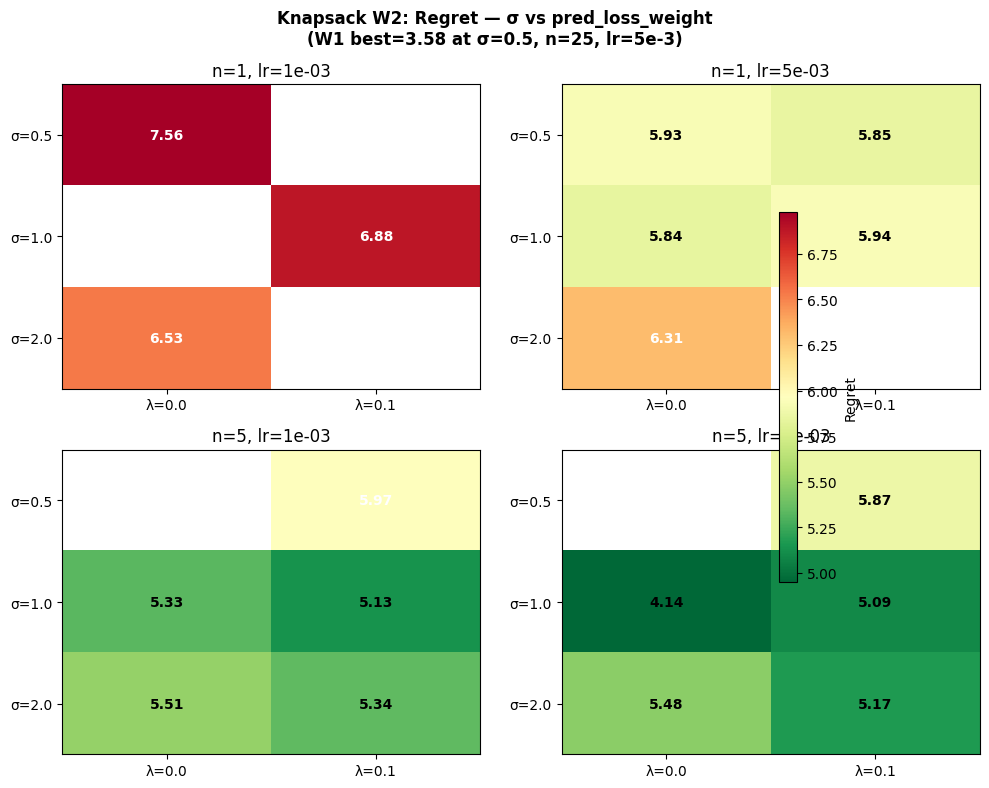

In [56]:
# ── 2×2 Heatmap grid: (n_samples × lr) panels, each σ vs plw ──────

if len(kn_done) >= 12:
    sigma_vals_kn = sorted(kn_done["sigma"].unique())
    plw_vals_kn = sorted(kn_done["plw"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    all_regrets_kn = kn_done["regret"].dropna()
    vmin_kn = all_regrets_kn.quantile(0.05) if len(all_regrets_kn) > 5 else all_regrets_kn.min()
    vmax_kn = all_regrets_kn.quantile(0.95) if len(all_regrets_kn) > 5 else all_regrets_kn.max()

    panels_kn = [(1, "lr1e3", 1e-3), (1, "lr5e3", 5e-3), (5, "lr1e3", 1e-3), (5, "lr5e3", 5e-3)]

    for idx, (n_s, lr_tag_kn, lr_val_kn) in enumerate(panels_kn):
        ax = axes[idx // 2, idx % 2]
        sub = kn_done[(kn_done["n_samples"] == n_s) & (kn_done["lr_tag"] == lr_tag_kn)]

        heat_kn = np.full((len(sigma_vals_kn), len(plw_vals_kn)), np.nan)
        for si_kn, sv in enumerate(sigma_vals_kn):
            for pi_kn, pv in enumerate(plw_vals_kn):
                match = sub[(sub["sigma"] == sv) & (sub["plw"] == pv)]
                if len(match) > 0:
                    heat_kn[si_kn, pi_kn] = match["regret"].values[0]

        im_kn = ax.imshow(heat_kn, cmap="RdYlGn_r", aspect="auto",
                          vmin=vmin_kn, vmax=vmax_kn)
        ax.set_xticks(range(len(plw_vals_kn)))
        ax.set_xticklabels([f"λ={v}" for v in plw_vals_kn])
        ax.set_yticks(range(len(sigma_vals_kn)))
        ax.set_yticklabels([f"σ={v}" for v in sigma_vals_kn])
        ax.set_title(f"n={n_s}, lr={lr_val_kn:.0e}")

        for si_kn in range(len(sigma_vals_kn)):
            for pi_kn in range(len(plw_vals_kn)):
                val_kn = heat_kn[si_kn, pi_kn]
                if not np.isnan(val_kn):
                    ax.text(pi_kn, si_kn, f"{val_kn:.2f}", ha="center", va="center",
                            fontsize=10, fontweight="bold",
                            color="white" if val_kn > (vmin_kn + vmax_kn) / 2 else "black")

    fig.colorbar(im_kn, ax=axes, shrink=0.6, label="Regret")
    fig.suptitle("Knapsack W2: Regret — σ vs pred_loss_weight\n(W1 best=3.58 at σ=0.5, n=25, lr=5e-3)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print(f"Only {len(kn_done)} results — need ≥12 for heatmaps")

### Knapsack W2: Training Traces + Diagnostics — Top configs vs W1 baseline

KN W2: 24/24 traces, 1 baselines


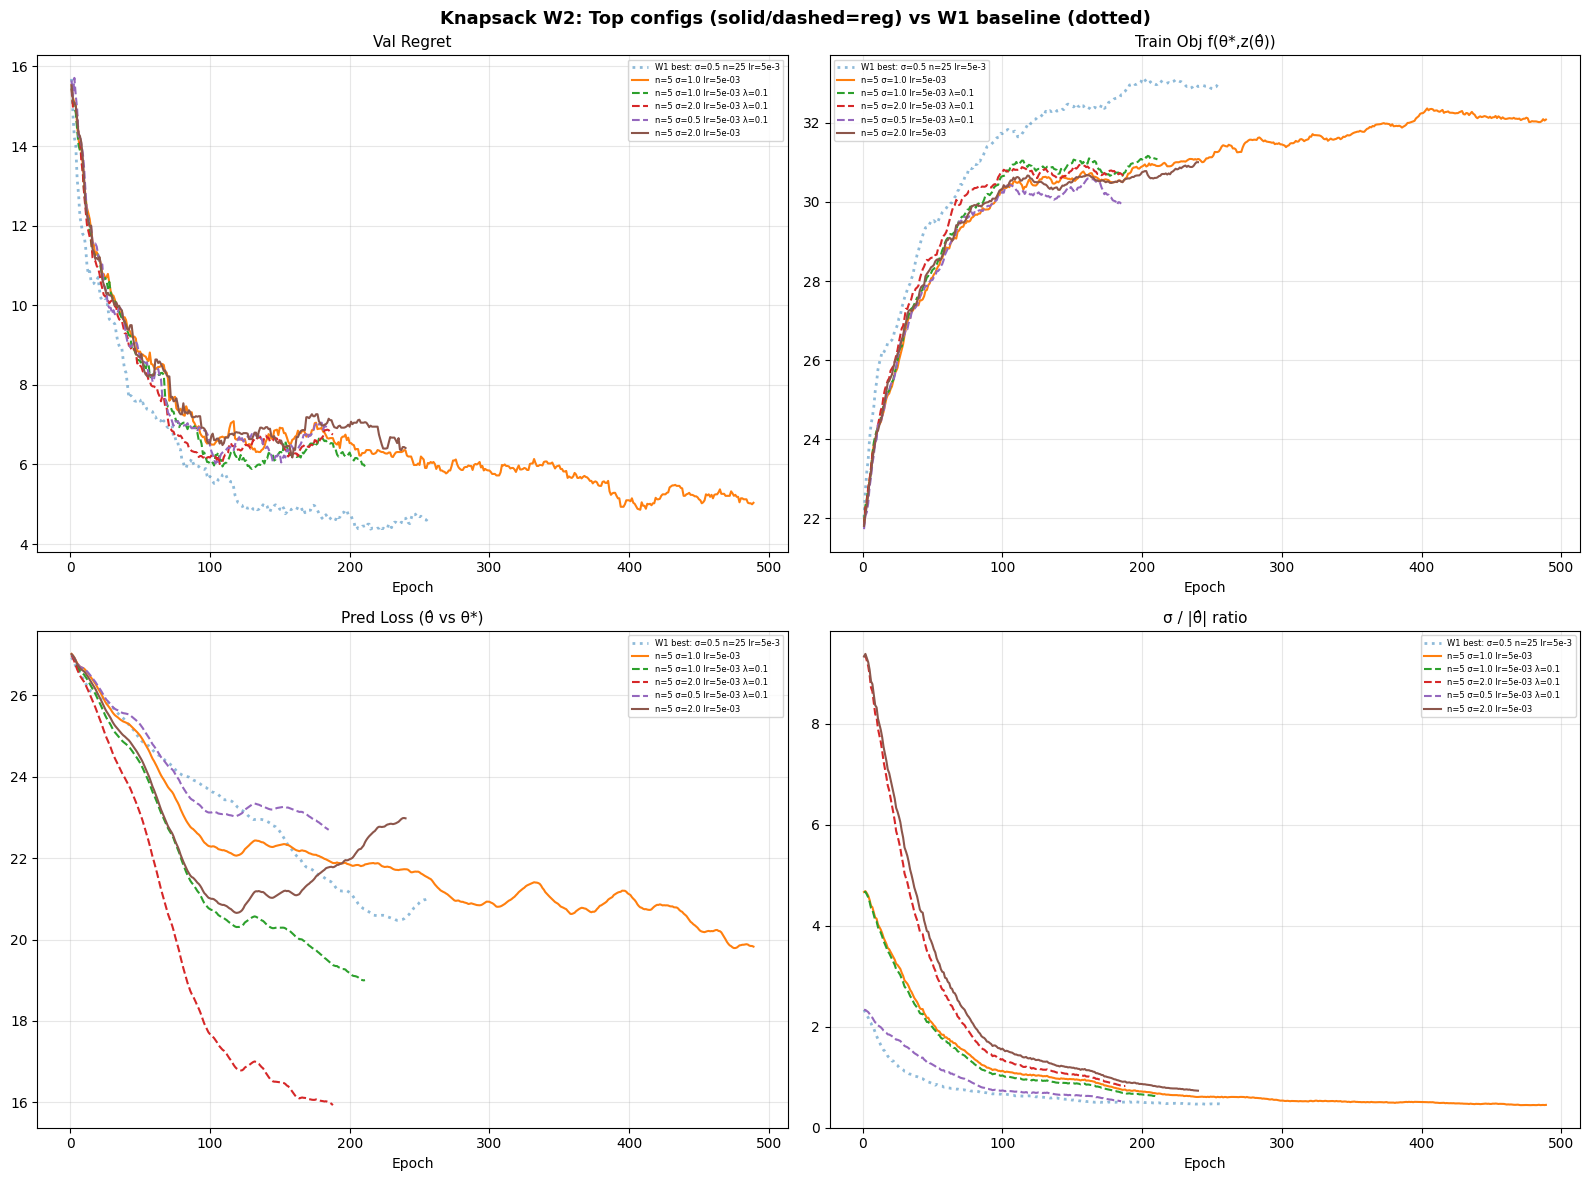


Top Knapsack W2 configs:
  1. n=5 σ=1.0 lr=5e-03                             val_regret=4.8625
  2. n=5 σ=1.0 lr=5e-03 λ=0.1                       val_regret=5.8875
  3. n=5 σ=2.0 lr=5e-03 λ=0.1                       val_regret=6.0125
  4. n=5 σ=0.5 lr=5e-03 λ=0.1                       val_regret=6.0250
  5. n=5 σ=2.0 lr=5e-03                             val_regret=6.1750
  baseline: W1 best: σ=0.5 n=25 lr=5e-3                 val_regret=4.3750


In [57]:
KN_TOP_K = 5

# ── Collect KN W2 traces with diagnostics ────────────────────────────
kn_traces = []
for exp_key, exp in KN_EXPERIMENTS.items():
    tdf, vdf, ddf = read_full_traces(exp["data_name"], exp["prefix"])
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        plw_str = f" λ={exp['pred_loss_weight']}" if exp["pred_loss_weight"] > 0 else ""
        label = f"n={exp['n_samples']} σ={exp['sigma']} lr={exp['lr']:.0e}{plw_str}"
        kn_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val,
            "n_samples": exp["n_samples"],
            "plw": exp["pred_loss_weight"],
        })

# Reference baselines: best W1 knapsack run
kn_baselines = []
tdf, vdf, ddf = read_full_traces("knapsack-gen", "sd1_s05_lr5e3")
if tdf is not None:
    kn_baselines.append({"label": "W1 best: σ=0.5 n=25 lr=5e-3", "train": tdf, "val": vdf, "diag": ddf,
                          "best_val_regret": get_best_val_regret(vdf)})

print(f"KN W2: {len(kn_traces)}/24 traces, {len(kn_baselines)} baselines")

if len(kn_traces) > 0:
    kn_traces.sort(key=lambda t: t["best_val_regret"])
    kn_sel = kn_traces[:KN_TOP_K]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    plot_specs_kn = [
        ("Val Regret", "val", "regret", axes[0, 0]),
        ("Train Obj f(θ*,z(θ̂))", "train", "obj", axes[0, 1]),
        ("Pred Loss (θ̂ vs θ*)", "train", "pred_loss", axes[1, 0]),
        ("σ / |θ̂| ratio", "diag", "sigma_over_coeff", axes[1, 1]),
    ]

    for title, source, col, ax in plot_specs_kn:
        # Baselines (dotted)
        for i, bl in enumerate(kn_baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ep_col = "epoch" if "epoch" in df_bl.columns else "epoch_num"
                ax.plot(df_bl[ep_col], df_bl[col],
                        color="C0", alpha=0.5, linestyle=":", linewidth=2,
                        label=bl["label"])
        # W2 top configs (solid, dashed for plw>0)
        for i, tr in enumerate(kn_sel):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ep_col = "epoch" if "epoch" in df_tr.columns else "epoch_num"
                ls = "--" if tr["plw"] > 0 else "-"
                ax.plot(df_tr[ep_col], df_tr[col],
                        color=f"C{1+i}", linewidth=1.5, linestyle=ls,
                        label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    fig.suptitle("Knapsack W2: Top configs (solid/dashed=reg) vs W1 baseline (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Ranking
    print("\nTop Knapsack W2 configs:")
    for i, tr in enumerate(kn_sel):
        print(f"  {i+1}. {tr['label']:45s}  val_regret={tr['best_val_regret']:.4f}")
    for bl in kn_baselines:
        print(f"  baseline: {bl['label']:42s}  val_regret={bl['best_val_regret']:.4f}")
else:
    print("No KN W2 traces yet.")

### Knapsack W2: SLURM Error Scanner

In [58]:
import glob

kn_err_files = sorted(glob.glob("logs/slurm/pco_knapsack_sd1_kn_*.err"))
print(f"Found {len(kn_err_files)} Knapsack W2 error files\n")

kn_problems = 0
for f in kn_err_files:
    with open(f) as fh:
        content = fh.read()
    lines = content.strip().split("\n")
    error_lines = [l for l in lines
                   if any(kw in l.lower() for kw in ["error", "traceback", "exception", "killed", "oom"])
                   and "deprecat" not in l.lower() and "warning" not in l.lower()]
    if error_lines:
        kn_problems += 1
        short_name = os.path.basename(f)
        print(f"⚠ {short_name}:")
        for l in error_lines[:5]:
            print(f"   {l.strip()}")
        print()

if kn_problems == 0:
    print("✓ No errors detected in any Knapsack W2 SLURM logs.")

Found 73 Knapsack W2 error files

⚠ pco_knapsack_sd1_kn_n1_s05_plw01_lr1e3_32060401.err:
   slurmstepd: error: *** JOB 32060401 ON d1cmp046 CANCELLED AT 2026-03-02T20:29:02 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_n1_s05_plw01_lr1e3_bk_32060402.err:
   slurmstepd: error: *** JOB 32060402 ON s1cmp005 CANCELLED AT 2026-03-03T16:40:35 ***

⚠ pco_knapsack_sd1_kn_n1_s10_plw0_lr1e3_32060405.err:
   slurmstepd: error: *** JOB 32060405 ON d1cmp046 CANCELLED AT 2026-03-02T20:31:02 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_n1_s10_plw0_lr1e3_bk_32060406.err:
   slurmstepd: error: *** JOB 32060406 ON cc1gpu005 CANCELLED AT 2026-03-03T16:40:35 ***

⚠ pco_knapsack_sd1_kn_n1_s20_plw01_lr1e3_32060418.err:
   slurmstepd: error: *** JOB 32060418 ON d1cmp045 CANCELLED AT 2026-03-02T20:57:08 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_n1_s20_plw01_lr1e3_bk_32060419.err:
   slurmstepd: error: *** JOB 32060419 ON p1cmp073 CANCELLED AT 2026-03-03T16:40:35 ***

⚠ pco_knapsack_sd1_kn_n1_s20_plw01_lr5e3

## Wave 5 — Portfolio: σ=0 (Exact CvxpyLayer Gradients)

**Motivation**: The portfolio solver uses `CvxpyLayer`, making it natively differentiable.
At σ=0 we bypass perturbation entirely and differentiate through the QP's KKT conditions.
This is the exact σ→0 limit of the Berthet soft decision — no Monte Carlo noise, no n_samples.

**Key difference from cpLayer**: The loss uses true coefficients θ* in the objective
(decision-focused regret), not predicted coefficients θ̂. This gives the gradient oracle
information about which stocks *actually* have good returns.

**Implementation**: Added `self.sigma == 0` branch in `perturbed.forward()` that calls
`problem.get_decision(coeff_hat, ...)` directly without `.detach()`.

**Grid**: 5 learning rates (wider range since exact gradients may differ in magnitude)

| lr | Prefix |
|----|--------|
| 1e-4 | `sd1_w5_s0_lr1e4` |
| 5e-4 | `sd1_w5_s0_lr5e4` |
| 1e-3 | `sd1_w5_s0_lr1e3` |
| 5e-3 | `sd1_w5_s0_lr5e3` |
| 1e-2 | `sd1_w5_s0_lr1e2` |

All runs: 400 epochs, patience=80, pred_loss_weight=0.

In [59]:
# ── Wave 5 Registry ──────────────────────────────────────────────────
W5_LRS = {
    "lr1e4": 1e-4,
    "lr5e4": 5e-4,
    "lr1e3": 1e-3,
    "lr5e3": 5e-3,
    "lr1e2": 1e-2,
}

W5_EXPERIMENTS = {}
for lr_tag, lr_val in W5_LRS.items():
    prefix = f"sd1_w5_s0_{lr_tag}"
    exp_key = f"w5_s0_{lr_tag}"
    W5_EXPERIMENTS[exp_key] = {
        "data_name": "portfolio-real",
        "prefix": prefix,
        "sigma": 0,
        "lr": lr_val,
        "lr_tag": lr_tag,
    }

print(f"Wave 5: registered {len(W5_EXPERIMENTS)} experiments")
print(f"Grid: {len(W5_LRS)} learning rates, σ=0 (exact CvxpyLayer gradients)")

Wave 5: registered 5 experiments
Grid: 5 learning rates, σ=0 (exact CvxpyLayer gradients)


### Wave 5: Launch & Status

In [60]:
# Dry run
!bash shells/slurm/submit_portfolio_wave5.sh --dry-run 2>&1 | head -15
print("...")
!bash shells/slurm/submit_portfolio_wave5.sh --dry-run 2>&1 | tail -8

Wave 5 — Portfolio: σ=0 (exact CvxpyLayer gradients)
Grid: 5 lr values = 5 experiments
Schedule: n_epochs=400, patience=80
Primary:  preempt
Backup:   hugheslab,gpu (afternotok dependency)
Time: 24:00:00  Mem: 16G  GRES: gpu:1
*** DRY RUN MODE ***
Skip completed: ON
Total experiments: 5

[SKIP] pco_portfolio_sd1_w5_s0_lr1e4 — already completed
[SKIP] pco_portfolio_sd1_w5_s0_lr5e4 — already completed
...

Submitted: 0 experiments
  → 0 primary (preempt) + 0 backup (hugheslab,gpu)
  → Total SLURM jobs: 0
Skipped (completed): 5

Dry run complete. No jobs submitted.


In [61]:
# Submit (uncomment to run):
# !bash shells/slurm/submit_portfolio_wave5.sh

In [62]:
# Job status
!squeue -u $USER --format="%.18i %.30j %.8T %.10M %.6D %R" | grep -E "pco_portfolio_sd1_w5|JOBID" | head -20

             JOBID                           NAME    STATE       TIME  NODES NODELIST(REASON)


### Collect Wave 5 Results

In [63]:
# ── Collect Wave 5 results ────────────────────────────────────────────
w5_rows = []
for exp_key, exp in W5_EXPERIMENTS.items():
    result = read_result(exp["data_name"], exp["prefix"])
    row = {
        "experiment": exp_key,
        "prefix": exp["prefix"],
        "sigma": 0,
        "lr": exp["lr"],
        "lr_tag": exp["lr_tag"],
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    w5_rows.append(row)

w5_df = pd.DataFrame(w5_rows)
w5_done = w5_df[w5_df["status"] == "done"]
w5_pending = w5_df[w5_df["status"] == "pending"]
print(f"Wave 5: {len(w5_done)}/{len(w5_df)} completed")

if len(w5_done) > 0:
    # Reference baselines
    w3_best_regret = 0.2252   # sd1_w3_n5_s10_plw10_lr5e3
    w1_best_regret_port = 0.387   # sd1_s005_lr5e3
    zero_pred_regret = 0.388  # zero-prediction baseline

    print(f"\nBaselines:")
    print(f"  Zero-prediction:  {zero_pred_regret:.4f}")
    print(f"  W1 best (σ=0.05): {w1_best_regret_port:.4f}")
    print(f"  W3 best (σ=1.0):  {w3_best_regret:.4f}")
    print(f"\nWave 5 results (σ=0, exact CvxpyLayer gradients):")
    for _, r in w5_done.sort_values("regret").iterrows():
        flag = " ★" if r["regret"] < w3_best_regret else ""
        print(f"  lr={r['lr']:.0e}  regret={r['regret']:.4f}  obj={r['objective']:.4f}{flag}")
else:
    print("\nNo results available yet.")
    if len(w5_pending) > 0:
        print(f"{len(w5_pending)} experiments pending")

Wave 5: 5/5 completed

Baselines:
  Zero-prediction:  0.3880
  W1 best (σ=0.05): 0.3870
  W3 best (σ=1.0):  0.2252

Wave 5 results (σ=0, exact CvxpyLayer gradients):
  lr=1e-02  regret=0.2548  obj=-0.4382
  lr=5e-03  regret=0.2928  obj=-0.5464
  lr=1e-04  regret=0.3518  obj=-0.6505
  lr=5e-04  regret=0.3544  obj=-0.6517
  lr=1e-03  regret=0.3626  obj=-0.6557


### Wave 5: Regret vs Learning Rate

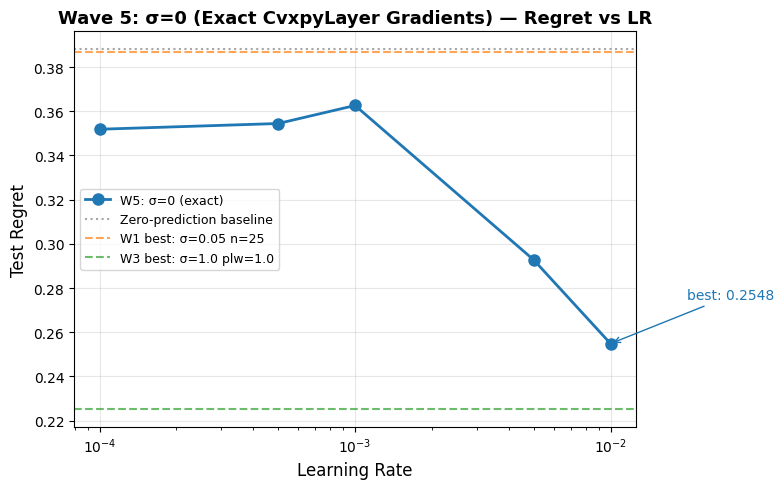


★ Best W5: lr=1e-02  regret=0.2548
  vs W3 best: 0.2252  (Δ=+0.0296)
  vs W1 best: 0.3870  (Δ=-0.1322)


In [64]:
if len(w5_done) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    # Plot W5 regret vs lr
    w5_sorted = w5_done.sort_values("lr")
    ax.plot(w5_sorted["lr"], w5_sorted["regret"], "o-", color="C0",
            linewidth=2, markersize=8, label="W5: σ=0 (exact)")

    # Baseline lines
    ax.axhline(y=0.388, color="gray", linestyle=":", alpha=0.7, label="Zero-prediction baseline")
    ax.axhline(y=0.387, color="C1", linestyle="--", alpha=0.7, label="W1 best: σ=0.05 n=25")
    ax.axhline(y=0.2252, color="C2", linestyle="--", alpha=0.7, label="W3 best: σ=1.0 plw=1.0")

    ax.set_xscale("log")
    ax.set_xlabel("Learning Rate", fontsize=12)
    ax.set_ylabel("Test Regret", fontsize=12)
    ax.set_title("Wave 5: σ=0 (Exact CvxpyLayer Gradients) — Regret vs LR",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Annotate best
    best_w5 = w5_done.loc[w5_done["regret"].idxmin()]
    ax.annotate(f"best: {best_w5['regret']:.4f}",
                xy=(best_w5["lr"], best_w5["regret"]),
                xytext=(best_w5["lr"] * 2, best_w5["regret"] + 0.02),
                arrowprops=dict(arrowstyle="->", color="C0"), fontsize=10, color="C0")

    plt.tight_layout()
    plt.show()

    # Summary
    print(f"\n★ Best W5: lr={best_w5['lr']:.0e}  regret={best_w5['regret']:.4f}")
    print(f"  vs W3 best: {0.2252:.4f}  (Δ={best_w5['regret'] - 0.2252:+.4f})")
    print(f"  vs W1 best: {0.387:.4f}  (Δ={best_w5['regret'] - 0.387:+.4f})")
else:
    print("No W5 results yet — re-run this cell after jobs complete.")

### Wave 5: Training Curves vs W1/W3 Baselines

W5: 5/5 traces, 2 baselines


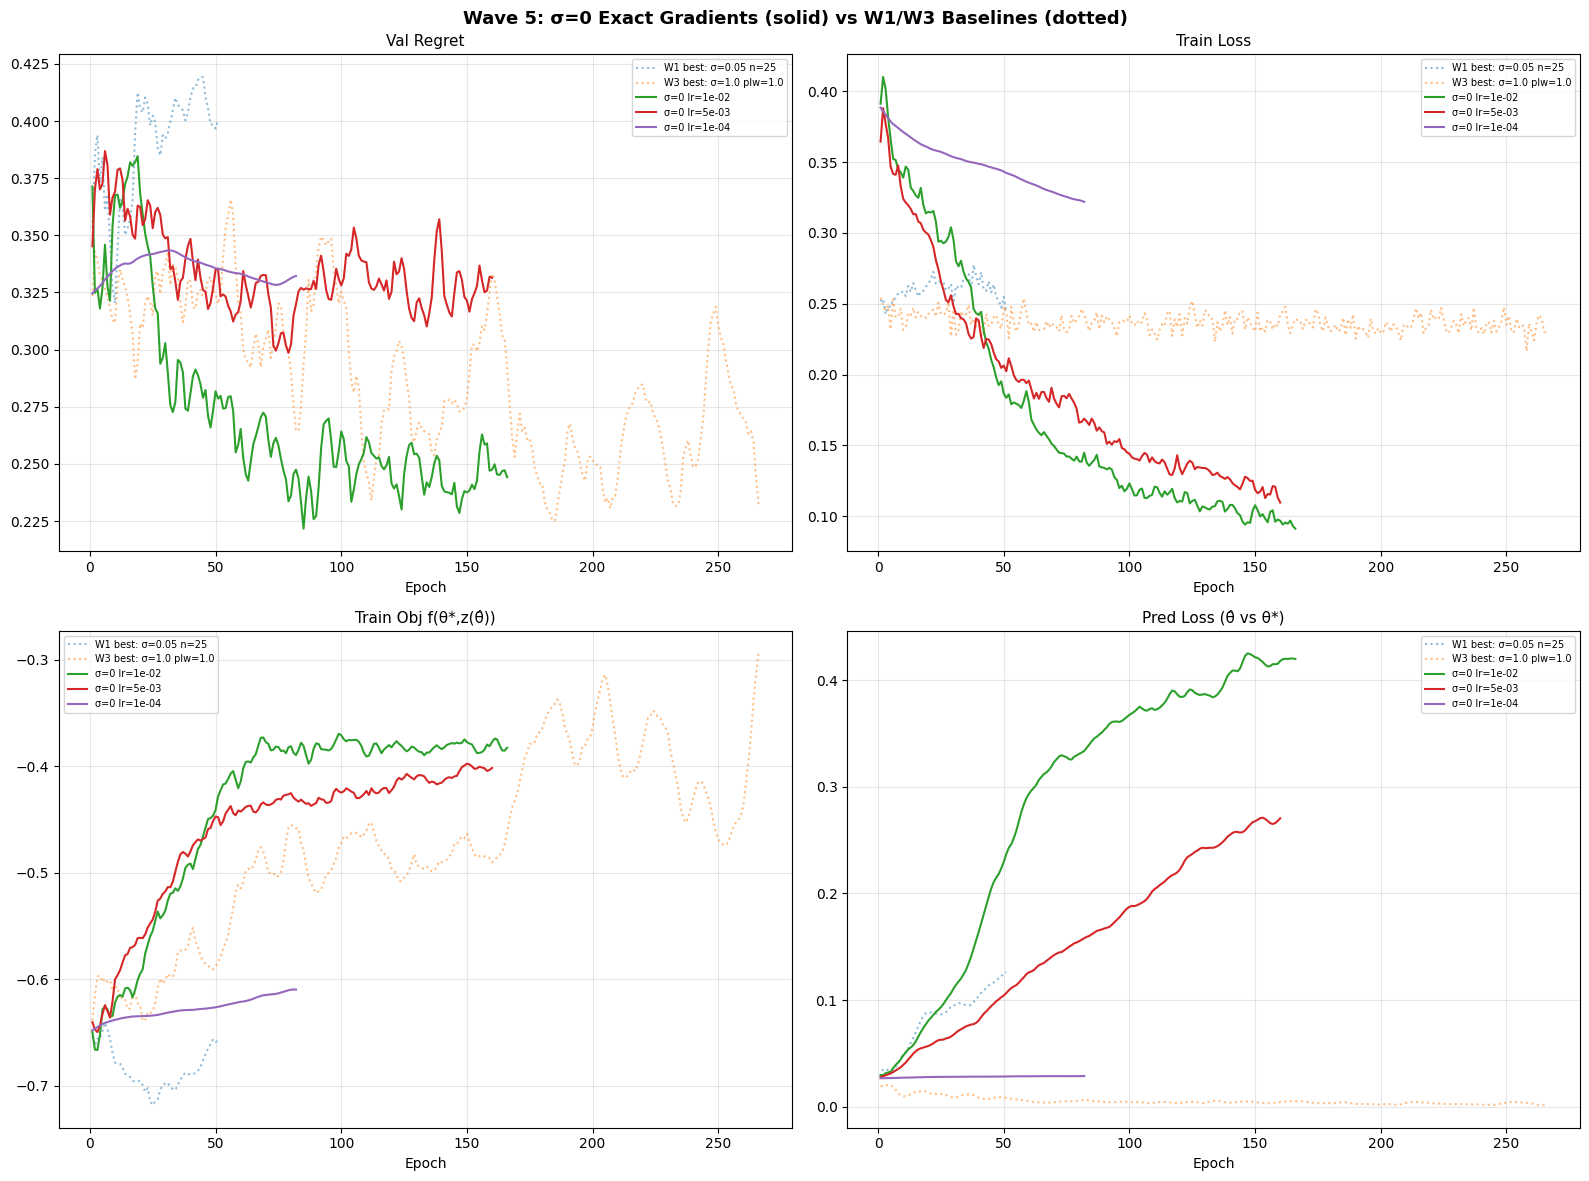


Wave 5 ranking:
  1. σ=0 lr=1e-02               val_regret=0.2217 ★
  2. σ=0 lr=5e-03               val_regret=0.2986
  3. σ=0 lr=1e-04               val_regret=0.3245
  4. σ=0 lr=5e-04               val_regret=0.3275
  5. σ=0 lr=1e-03               val_regret=0.3299
  baseline: W1 best: σ=0.05 n=25    val_regret=0.3204
  baseline: W3 best: σ=1.0 plw=1.0  val_regret=0.2252


In [65]:
W5_TOP_K = 3

# ── Collect W5 traces ────────────────────────────────────────────────
w5_traces = []
for exp_key, exp in W5_EXPERIMENTS.items():
    tdf, vdf, ddf = read_full_traces(exp["data_name"], exp["prefix"])
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        label = f"σ=0 lr={exp['lr']:.0e}"
        w5_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val,
            "lr": exp["lr"],
        })

# Reference baselines
w5_baselines = []
tdf, vdf, ddf = read_full_traces("portfolio-real", "sd1_s005_lr5e3")
if tdf is not None:
    w5_baselines.append({"label": "W1 best: σ=0.05 n=25", "train": tdf, "val": vdf, "diag": ddf,
                         "best_val_regret": get_best_val_regret(vdf)})
tdf, vdf, ddf = read_full_traces("portfolio-real", "sd1_w3_n5_s10_plw10_lr5e3")
if tdf is not None:
    w5_baselines.append({"label": "W3 best: σ=1.0 plw=1.0", "train": tdf, "val": vdf, "diag": ddf,
                         "best_val_regret": get_best_val_regret(vdf)})

print(f"W5: {len(w5_traces)}/5 traces, {len(w5_baselines)} baselines")

if len(w5_traces) > 0:
    w5_traces.sort(key=lambda t: t["best_val_regret"])
    w5_sel = w5_traces[:W5_TOP_K]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    plot_specs_w5 = [
        ("Val Regret", "val", "regret", axes[0, 0]),
        ("Train Loss", "train", "loss", axes[0, 1]),
        ("Train Obj f(θ*,z(θ̂))", "train", "obj", axes[1, 0]),
        ("Pred Loss (θ̂ vs θ*)", "train", "pred_loss", axes[1, 1]),
    ]

    for title, source, col, ax in plot_specs_w5:
        # Baselines (dotted)
        for i, bl in enumerate(w5_baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ep_col = "epoch" if "epoch" in df_bl.columns else "epoch_num"
                ax.plot(df_bl[ep_col], df_bl[col],
                        color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1.5,
                        label=bl["label"])
        # W5 top configs (solid)
        for i, tr in enumerate(w5_sel):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ep_col = "epoch" if "epoch" in df_tr.columns else "epoch_num"
                ax.plot(df_tr[ep_col], df_tr[col],
                        color=f"C{len(w5_baselines)+i}", linewidth=1.5,
                        label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    fig.suptitle("Wave 5: σ=0 Exact Gradients (solid) vs W1/W3 Baselines (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Ranking
    print("\nWave 5 ranking:")
    for i, tr in enumerate(w5_traces):
        marker = " ★" if i == 0 else ""
        print(f"  {i+1}. {tr['label']:25s}  val_regret={tr['best_val_regret']:.4f}{marker}")
    for bl in w5_baselines:
        print(f"  baseline: {bl['label']:22s}  val_regret={bl['best_val_regret']:.4f}")
else:
    print("No W5 traces yet — re-run after jobs complete.")

### Wave 5: SLURM Error Scanner

In [66]:
import glob

w5_err_files = sorted(glob.glob("logs/slurm/pco_portfolio_sd1_w5_*.err"))
print(f"Found {len(w5_err_files)} Wave 5 error files\n")

w5_problems = 0
for f in w5_err_files:
    with open(f) as fh:
        content = fh.read()
    lines = content.strip().split("\n")
    error_lines = [l for l in lines
                   if any(kw in l.lower() for kw in ["error", "traceback", "exception", "killed", "oom"])
                   and "deprecat" not in l.lower() and "warning" not in l.lower()]
    if error_lines:
        w5_problems += 1
        short_name = os.path.basename(f)
        print(f"⚠ {short_name}:")
        for l in error_lines[:5]:
            print(f"   {l.strip()}")
        print()

if w5_problems == 0:
    print("✓ No errors detected in any Wave 5 SLURM logs.")

Found 5 Wave 5 error files

✓ No errors detected in any Wave 5 SLURM logs.


In [67]:
# ── Knapsack Wave 3: Registry ──────────────────────────────────────
KN_W3 = {
    # σ_end=0.05, warmup=50
    "sd1_kn_w3_se005_w50_lr1e3":  dict(se=0.05, warmup=50, lr=1e-3),
    "sd1_kn_w3_se005_w50_lr5e3":  dict(se=0.05, warmup=50, lr=5e-3),
    # σ_end=0.05, warmup=100
    "sd1_kn_w3_se005_w100_lr1e3": dict(se=0.05, warmup=100, lr=1e-3),
    "sd1_kn_w3_se005_w100_lr5e3": dict(se=0.05, warmup=100, lr=5e-3),
    # σ_end=0.01, warmup=50
    "sd1_kn_w3_se001_w50_lr1e3":  dict(se=0.01, warmup=50, lr=1e-3),
    "sd1_kn_w3_se001_w50_lr5e3":  dict(se=0.01, warmup=50, lr=5e-3),
    # σ_end=0.01, warmup=100
    "sd1_kn_w3_se001_w100_lr1e3": dict(se=0.01, warmup=100, lr=1e-3),
    "sd1_kn_w3_se001_w100_lr5e3": dict(se=0.01, warmup=100, lr=5e-3),
}
print(f"Knapsack W3: {len(KN_W3)} experiments registered")

# ── Collect results ───────────────────────────────────────────────────
kn_w3_rows = []
for prefix, hp in KN_W3.items():
    result = read_result("knapsack-gen", prefix)
    row = {
        "prefix": prefix,
        "sigma_end": hp["se"],
        "warmup": hp["warmup"],
        "lr": hp["lr"],
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    kn_w3_rows.append(row)

kn_w3_df = pd.DataFrame(kn_w3_rows)
kn_w3_done = kn_w3_df[kn_w3_df["status"] == "done"]
kn_w3_pending = kn_w3_df[kn_w3_df["status"] == "pending"]
print(f"Completed: {len(kn_w3_done)}/{len(kn_w3_df)}")

# Reference baselines
w1_kn_best = 3.580   # sd1_s05_lr5e3 (n=25)
w2_kn_best = 4.140   # sd1_kn_n5_s10_plw0_lr5e3

if len(kn_w3_done) > 0:
    print(f"\nBaselines:")
    print(f"  W1 best (σ=0.5 const, n=25): {w1_kn_best:.3f}")
    print(f"  W2 best (σ=1.0 const, n=5):  {w2_kn_best:.3f}")
    print(f"\nKnapsack W3 results (sorted by regret):")
    for _, r in kn_w3_done.sort_values("regret").iterrows():
        flag = " ★" if r["regret"] < w1_kn_best else ""
        print(f"  se={r['sigma_end']:<5} w={r['warmup']:<4} lr={r['lr']:.0e}  "
              f"regret={r['regret']:.3f}  obj={r['objective']:.3f}{flag}")
else:
    print(f"\nNo results yet. {len(kn_w3_pending)} experiments pending.")

Knapsack W3: 8 experiments registered
Completed: 7/8

Baselines:
  W1 best (σ=0.5 const, n=25): 3.580
  W2 best (σ=1.0 const, n=5):  4.140

Knapsack W3 results (sorted by regret):
  se=0.05  w=100  lr=5e-03  regret=6.020  obj=30.295
  se=0.01  w=100  lr=5e-03  regret=6.020  obj=30.295
  se=0.01  w=50   lr=5e-03  regret=6.210  obj=30.105
  se=0.05  w=50   lr=5e-03  regret=6.215  obj=30.100
  se=0.05  w=100  lr=1e-03  regret=7.110  obj=29.205
  se=0.05  w=50   lr=1e-03  regret=7.135  obj=29.180
  se=0.01  w=100  lr=1e-03  regret=7.730  obj=28.585


### Knapsack W3: Training Curves

KN W3: 7/8 traces, 2 baselines


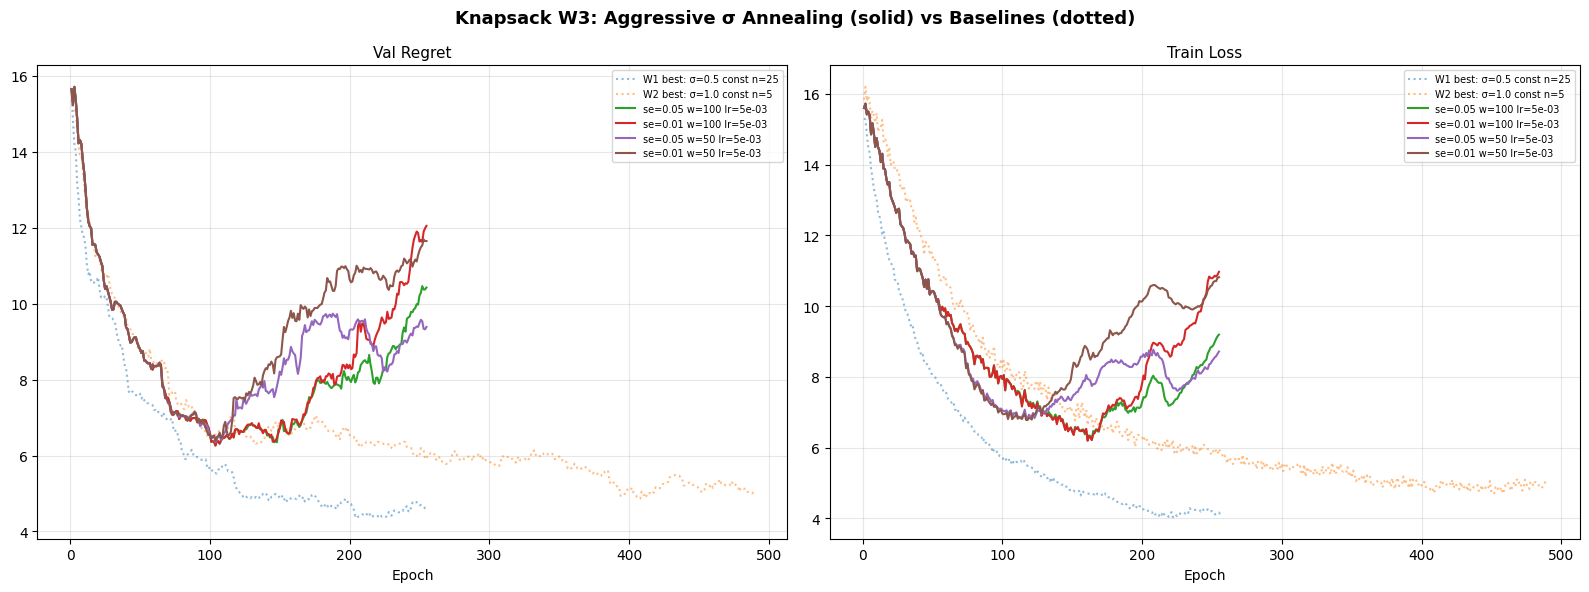


Knapsack W3 ranking:
  1. se=0.05 w=100 lr=5e-03          val_regret=6.263 ★
  2. se=0.01 w=100 lr=5e-03          val_regret=6.263
  3. se=0.05 w=50 lr=5e-03           val_regret=6.350
  4. se=0.01 w=50 lr=5e-03           val_regret=6.388
  5. se=0.05 w=50 lr=1e-03           val_regret=7.213
  6. se=0.05 w=100 lr=1e-03          val_regret=7.225
  7. se=0.01 w=100 lr=1e-03          val_regret=8.325
  baseline: W1 best: σ=0.5 const n=25   val_regret=4.375
  baseline: W2 best: σ=1.0 const n=5    val_regret=4.862


In [68]:
KN_W3_TOP_K = 4

# ── Collect traces ────────────────────────────────────────────────────
kn_w3_traces = []
for prefix, hp in KN_W3.items():
    tdf, vdf, ddf = read_full_traces("knapsack-gen", prefix)
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        label = f"se={hp['se']} w={hp['warmup']} lr={hp['lr']:.0e}"
        kn_w3_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val,
            "prefix": prefix,
        })

# Reference baselines
kn_w3_baselines = []
tdf, vdf, ddf = read_full_traces("knapsack-gen", "sd1_s05_lr5e3")
if tdf is not None:
    kn_w3_baselines.append({"label": "W1 best: σ=0.5 const n=25", "train": tdf, "val": vdf, "diag": ddf,
                             "best_val_regret": get_best_val_regret(vdf)})
tdf, vdf, ddf = read_full_traces("knapsack-gen", "sd1_kn_n5_s10_plw0_lr5e3")
if tdf is not None:
    kn_w3_baselines.append({"label": "W2 best: σ=1.0 const n=5", "train": tdf, "val": vdf, "diag": ddf,
                             "best_val_regret": get_best_val_regret(vdf)})

print(f"KN W3: {len(kn_w3_traces)}/{len(KN_W3)} traces, {len(kn_w3_baselines)} baselines")

if len(kn_w3_traces) > 0:
    kn_w3_traces.sort(key=lambda t: t["best_val_regret"])
    kn_w3_sel = kn_w3_traces[:KN_W3_TOP_K]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plot_specs_knw3 = [
        ("Val Regret", "val", "regret", axes[0]),
        ("Train Loss", "train", "loss", axes[1]),
    ]

    for title, source, col, ax in plot_specs_knw3:
        # Baselines (dotted)
        for i, bl in enumerate(kn_w3_baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ep_col = "epoch" if "epoch" in df_bl.columns else "epoch_num"
                ax.plot(df_bl[ep_col], df_bl[col],
                        color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1.5,
                        label=bl["label"])
        # W3 top configs (solid)
        for i, tr in enumerate(kn_w3_sel):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ep_col = "epoch" if "epoch" in df_tr.columns else "epoch_num"
                ax.plot(df_tr[ep_col], df_tr[col],
                        color=f"C{len(kn_w3_baselines)+i}", linewidth=1.5,
                        label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    fig.suptitle("Knapsack W3: Aggressive σ Annealing (solid) vs Baselines (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Ranking
    print("\nKnapsack W3 ranking:")
    for i, tr in enumerate(kn_w3_traces):
        marker = " ★" if i == 0 else ""
        print(f"  {i+1}. {tr['label']:30s}  val_regret={tr['best_val_regret']:.3f}{marker}")
    for bl in kn_w3_baselines:
        print(f"  baseline: {bl['label']:26s}  val_regret={bl['best_val_regret']:.3f}")
else:
    print("No KN W3 traces yet — re-run after jobs complete.")

### Knapsack W3: SLURM Error Scanner

In [69]:
import glob

kn_w3_err_files = sorted(glob.glob("logs/slurm/pco_knapsack_sd1_kn_w3_*.err"))
print(f"Found {len(kn_w3_err_files)} Knapsack W3 error files\n")

kn_w3_problems = 0
for f in kn_w3_err_files:
    with open(f) as fh:
        content = fh.read()
    lines = content.strip().split("\n")
    error_lines = [l for l in lines
                   if any(kw in l.lower() for kw in ["error", "traceback", "exception", "killed", "oom"])
                   and "deprecat" not in l.lower() and "warning" not in l.lower()]
    if error_lines:
        kn_w3_problems += 1
        short_name = os.path.basename(f)
        print(f"⚠ {short_name}:")
        for l in error_lines[:5]:
            print(f"   {l.strip()}")
        print()

if kn_w3_problems == 0:
    print("✓ No errors detected in any Knapsack W3 SLURM logs.")

Found 8 Knapsack W3 error files

⚠ pco_knapsack_sd1_kn_w3_se001_w50_lr1e3_32116275.err:
   slurmstepd: error: *** JOB 32116275 ON s1cmp014 CANCELLED AT 2026-03-03T01:16:18 DUE TO PREEMPTION ***



## Knapsack Wave 4 — σ Growing & Sigmoid Activation

**Problem**: W3 showed that *reducing* σ is catastrophic — once σ decays, val regret spikes
upward because prediction magnitudes grow until σ/|θ̂| collapses → perturbation stops
inducing decision changes → gradients vanish.

**Two hypotheses to test**:

**Track 1 (σ growing)**: Instead of decay, *grow* σ from 0.5 → {2.0, 5.0} to keep pace
with prediction scale growth. Uses `linear_decay` schedule with `sigma_end > sigma_start`.

**Track 2 (sigmoid activation)**: Bound predictions to (0,1) via sigmoid. Verified on 20/20
test instances: sigmoid-transformed profits give IDENTICAL solver decisions (knapsack MIP is
scale-invariant for positive scaling). With predictions bounded to (0,1), even σ=0.1 gives
10-50% relative perturbation, vs raw predictions ~5-30 where σ=0.5 is only 1.7-10%.

**Grid**: 4 (Track 1) + 8 (Track 2) = **12 experiments**

| Track | Factor | Values | lr |
|-------|--------|--------|----|
| σ growing | σ: 0.5→{2.0, 5.0}, warmup=50 | 2 × 2 lr = 4 | 1e-3, 5e-3 |
| sigmoid | activation=sigmoid, σ∈{0.05, 0.1, 0.5, 1.0} | 4 × 2 lr = 8 | 1e-3, 5e-3 |

All: n_samples=5, n_epochs=500, patience=150

In [70]:
# ── Knapsack Wave 4: Registry ──────────────────────────────────────
KN_W4 = {}

# Track 1: σ growing (linear_decay with sigma_end > sigma_start)
for se, se_tag in [(2.0, "se20"), (5.0, "se50")]:
    for lr_val, lr_tag in [(1e-3, "lr1e3"), (5e-3, "lr5e3")]:
        prefix = f"sd1_kn_w4_grow_{se_tag}_{lr_tag}"
        KN_W4[prefix] = dict(
            track="grow", sigma_end=se, sigma_start=0.5, warmup=50,
            lr=lr_val, activation="none", sigma=0.5,
        )

# Track 2: sigmoid activation + constant σ
for sigma, s_tag in [(0.05, "s005"), (0.1, "s01"), (0.5, "s05"), (1.0, "s10")]:
    for lr_val, lr_tag in [(1e-3, "lr1e3"), (5e-3, "lr5e3")]:
        prefix = f"sd1_kn_w4_sig_{s_tag}_{lr_tag}"
        KN_W4[prefix] = dict(
            track="sigmoid", sigma_end=sigma, sigma_start=sigma, warmup=0,
            lr=lr_val, activation="sigmoid", sigma=sigma,
        )

print(f"Knapsack W4: {len(KN_W4)} experiments registered")
print(f"  Track 1 (σ growing): {sum(1 for v in KN_W4.values() if v['track']=='grow')}")
print(f"  Track 2 (sigmoid):   {sum(1 for v in KN_W4.values() if v['track']=='sigmoid')}")

Knapsack W4: 12 experiments registered
  Track 1 (σ growing): 4
  Track 2 (sigmoid):   8


### Knapsack W4 — Launch / Status

In [71]:
!bash shells/slurm/submit_knapsack_wave4.sh --dry-run 2>&1 | head -15 && echo "..." && bash shells/slurm/submit_knapsack_wave4.sh --dry-run 2>&1 | tail -8

Wave 4 — Knapsack: σ growing & sigmoid activation
Track 1: σ growing (2 σ_end × 2 lr = 4 exps)
Track 2: sigmoid  (4 σ × 2 lr = 8 exps)
Primary:  preempt
Backup:   hugheslab,gpu (afternotok dependency)
Time: 24:00:00  Mem: 16G  GRES: gpu:1
n_epochs=500 | patience=150 | n_samples=5
*** DRY RUN MODE ***
Skip completed: ON
Total experiments: 12

[SKIP] pco_knapsack_sd1_kn_w4_grow_se20_lr1e3 — already completed
...

Submitted: 9 experiments
  → 9 primary (preempt) + 9 backup (hugheslab,gpu)
  → Total SLURM jobs: 18
Skipped (completed): 3

Dry run complete. No jobs submitted.


In [72]:
#!bash shells/slurm/submit_knapsack_wave4.sh

In [73]:
!squeue --me | grep pco_knapsack_sd1_kn_w4 | wc -l && echo "W4 knapsack jobs running" && squeue --me | grep pco_knapsack_sd1_kn_w4 | head -10

0
W4 knapsack jobs running


### Knapsack W4 — Collect Results

In [74]:
# ── Collect Knapsack W4 results ────────────────────────────────────────
kn_w4_rows = []
for prefix, hp in KN_W4.items():
    result = read_result("knapsack-gen", prefix)
    row = {
        "prefix": prefix,
        "track": hp["track"],
        "activation": hp["activation"],
        "sigma": hp["sigma"],
        "sigma_end": hp["sigma_end"],
        "lr": hp["lr"],
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    kn_w4_rows.append(row)

kn_w4_df = pd.DataFrame(kn_w4_rows)
kn_w4_done = kn_w4_df[kn_w4_df["status"] == "done"]
kn_w4_pending = kn_w4_df[kn_w4_df["status"] == "pending"]
print(f"Knapsack W4: {len(kn_w4_done)}/{len(kn_w4_df)} completed")

# Reference baselines
w1_kn_best = 3.580   # sd1_s05_lr5e3 (n=25)
w2_kn_best = 4.140   # sd1_kn_n5_s10_plw0_lr5e3

if len(kn_w4_done) > 0:
    print(f"\nBaselines:")
    print(f"  W1 best (σ=0.5 const, n=25): {w1_kn_best:.3f}")
    print(f"  W2 best (σ=1.0 const, n=5):  {w2_kn_best:.3f}")

    # Track 1 results
    t1 = kn_w4_done[kn_w4_done["track"] == "grow"].sort_values("regret")
    if len(t1) > 0:
        print(f"\nTrack 1 — σ growing ({len(t1)} done):")
        for _, r in t1.iterrows():
            flag = " ★" if r["regret"] < w1_kn_best else ""
            print(f"  σ: 0.5→{r['sigma_end']:<4} lr={r['lr']:.0e}  "
                  f"regret={r['regret']:.3f}  obj={r['objective']:.3f}{flag}")

    # Track 2 results
    t2 = kn_w4_done[kn_w4_done["track"] == "sigmoid"].sort_values("regret")
    if len(t2) > 0:
        print(f"\nTrack 2 — sigmoid activation ({len(t2)} done):")
        for _, r in t2.iterrows():
            flag = " ★" if r["regret"] < w1_kn_best else ""
            print(f"  sigmoid σ={r['sigma']:<5} lr={r['lr']:.0e}  "
                  f"regret={r['regret']:.3f}  obj={r['objective']:.3f}{flag}")

    # Overall best
    print(f"\nOverall W4 best:")
    best = kn_w4_done.sort_values("regret").iloc[0]
    improvement = w1_kn_best - best["regret"]
    print(f"  {best['prefix']}  regret={best['regret']:.3f}  ({improvement:+.3f} vs W1 best)")
else:
    print(f"\nNo results yet. {len(kn_w4_pending)} experiments pending.")

Knapsack W4: 3/12 completed

Baselines:
  W1 best (σ=0.5 const, n=25): 3.580
  W2 best (σ=1.0 const, n=5):  4.140

Track 1 — σ growing (3 done):
  σ: 0.5→2.0  lr=5e-03  regret=6.165  obj=30.150
  σ: 0.5→5.0  lr=5e-03  regret=6.555  obj=29.760
  σ: 0.5→2.0  lr=1e-03  regret=7.230  obj=29.085

Overall W4 best:
  sd1_kn_w4_grow_se20_lr5e3  regret=6.165  (-2.585 vs W1 best)


### Knapsack W4 — Training Curves

KN W4: 12/12 traces, 2 baselines


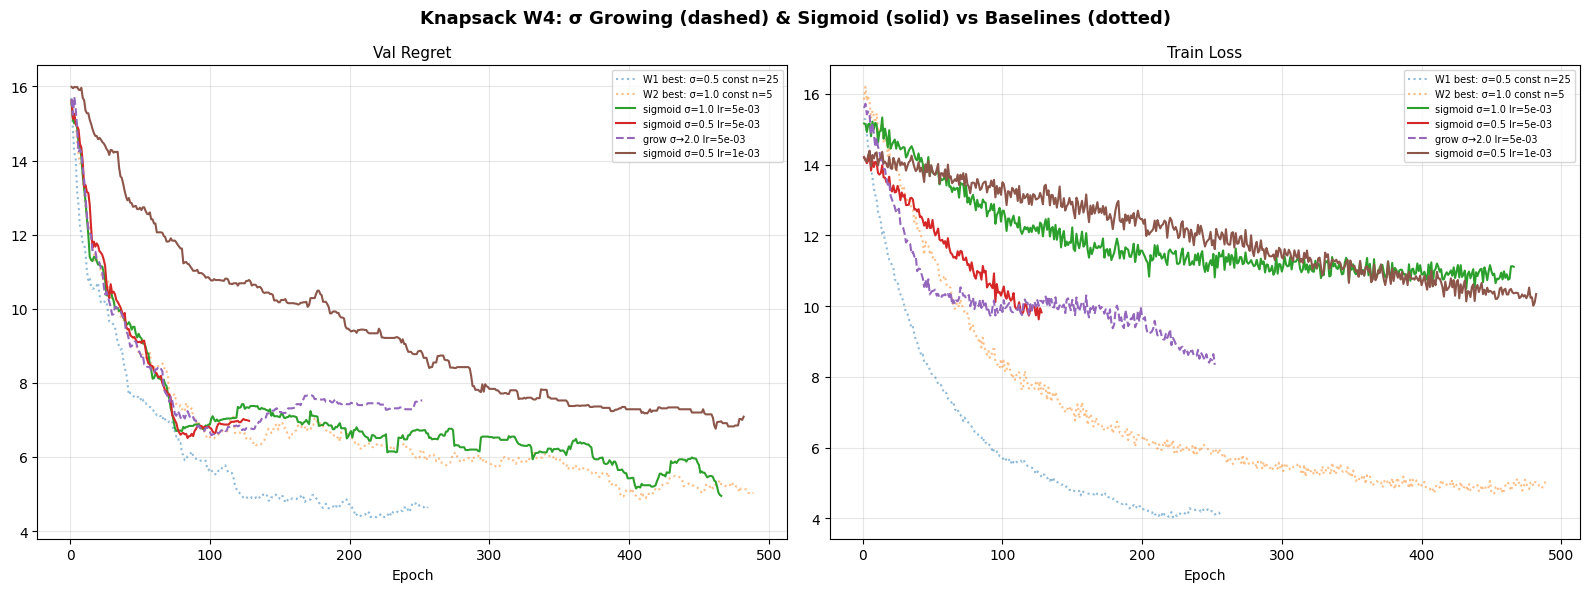


Knapsack W4 ranking:
   1. [sigmoid] sigmoid σ=1.0 lr=5e-03               val_regret=4.950 ★
   2. [sigmoid] sigmoid σ=0.5 lr=5e-03               val_regret=6.513
   3. [grow   ] grow σ→2.0 lr=5e-03                  val_regret=6.588
   4. [sigmoid] sigmoid σ=0.5 lr=1e-03               val_regret=6.763
   5. [grow   ] grow σ→5.0 lr=5e-03                  val_regret=6.912
   6. [sigmoid] sigmoid σ=0.1 lr=5e-03               val_regret=7.188
   7. [sigmoid] sigmoid σ=1.0 lr=1e-03               val_regret=7.800
   8. [grow   ] grow σ→2.0 lr=1e-03                  val_regret=8.075
   9. [grow   ] grow σ→5.0 lr=1e-03                  val_regret=10.363
  10. [sigmoid] sigmoid σ=0.1 lr=1e-03               val_regret=13.350
  11. [sigmoid] sigmoid σ=0.05 lr=5e-03              val_regret=15.675
  12. [sigmoid] sigmoid σ=0.05 lr=1e-03              val_regret=16.025
  baseline: W1 best: σ=0.5 const n=25           val_regret=4.375
  baseline: W2 best: σ=1.0 const n=5            val_regret=4.862


In [75]:
KN_W4_TOP_K = 4

# ── Collect traces ────────────────────────────────────────────────────
kn_w4_traces = []
for prefix, hp in KN_W4.items():
    tdf, vdf, ddf = read_full_traces("knapsack-gen", prefix)
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        if hp["track"] == "grow":
            label = f"grow σ→{hp['sigma_end']} lr={hp['lr']:.0e}"
        else:
            label = f"sigmoid σ={hp['sigma']} lr={hp['lr']:.0e}"
        kn_w4_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val,
            "prefix": prefix, "track": hp["track"],
        })

# Reference baselines
kn_w4_baselines = []
tdf, vdf, ddf = read_full_traces("knapsack-gen", "sd1_s05_lr5e3")
if tdf is not None:
    kn_w4_baselines.append({"label": "W1 best: σ=0.5 const n=25", "train": tdf, "val": vdf, "diag": ddf,
                             "best_val_regret": get_best_val_regret(vdf)})
tdf, vdf, ddf = read_full_traces("knapsack-gen", "sd1_kn_n5_s10_plw0_lr5e3")
if tdf is not None:
    kn_w4_baselines.append({"label": "W2 best: σ=1.0 const n=5", "train": tdf, "val": vdf, "diag": ddf,
                             "best_val_regret": get_best_val_regret(vdf)})

print(f"KN W4: {len(kn_w4_traces)}/{len(KN_W4)} traces, {len(kn_w4_baselines)} baselines")

if len(kn_w4_traces) > 0:
    kn_w4_traces.sort(key=lambda t: t["best_val_regret"])
    kn_w4_sel = kn_w4_traces[:KN_W4_TOP_K]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plot_specs_knw4 = [
        ("Val Regret", "val", "regret", axes[0]),
        ("Train Loss", "train", "loss", axes[1]),
    ]

    for title, source, col, ax in plot_specs_knw4:
        # Baselines (dotted)
        for i, bl in enumerate(kn_w4_baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ep_col = "epoch" if "epoch" in df_bl.columns else "epoch_num"
                ax.plot(df_bl[ep_col], df_bl[col],
                        color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1.5,
                        label=bl["label"])
        # W4 top configs (solid) — color by track
        for i, tr in enumerate(kn_w4_sel):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ep_col = "epoch" if "epoch" in df_tr.columns else "epoch_num"
                ls = "-" if tr["track"] == "sigmoid" else "--"
                ax.plot(df_tr[ep_col], df_tr[col],
                        color=f"C{len(kn_w4_baselines)+i}", linewidth=1.5,
                        linestyle=ls, label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    fig.suptitle("Knapsack W4: σ Growing (dashed) & Sigmoid (solid) vs Baselines (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Ranking
    print("\nKnapsack W4 ranking:")
    for i, tr in enumerate(kn_w4_traces):
        marker = " ★" if i == 0 else ""
        track_tag = f"[{tr['track']:7s}]"
        print(f"  {i+1:2d}. {track_tag} {tr['label']:35s}  val_regret={tr['best_val_regret']:.3f}{marker}")
    for bl in kn_w4_baselines:
        print(f"  baseline: {bl['label']:34s}  val_regret={bl['best_val_regret']:.3f}")
else:
    print("No KN W4 traces yet — re-run after jobs complete.")

### Knapsack W4 — SLURM Error Scanner

In [76]:
import glob

kn_w4_err_files = sorted(glob.glob("logs/slurm/pco_knapsack_sd1_kn_w4_*.err"))
print(f"Found {len(kn_w4_err_files)} Knapsack W4 error files\n")

kn_w4_problems = 0
for f in kn_w4_err_files:
    with open(f) as fh:
        content = fh.read()
    lines = content.strip().split("\n")
    error_lines = [l for l in lines
                   if any(kw in l.lower() for kw in ["error", "traceback", "exception", "killed", "oom"])
                   and "deprecat" not in l.lower() and "warning" not in l.lower()]
    if error_lines:
        kn_w4_problems += 1
        short_name = os.path.basename(f)
        print(f"⚠ {short_name}:")
        for l in error_lines[:5]:
            print(f"   {l.strip()}")
        print()

if kn_w4_problems == 0:
    print("✓ No errors detected in any Knapsack W4 SLURM logs.")

Found 12 Knapsack W4 error files

⚠ pco_knapsack_sd1_kn_w4_grow_se50_lr1e3_32199524.err:
   slurmstepd: error: *** JOB 32199524 ON s1cmp014 CANCELLED AT 2026-03-03T11:37:58 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w4_sig_s005_lr1e3_32199528.err:
   slurmstepd: error: *** JOB 32199528 ON s1cmp014 CANCELLED AT 2026-03-03T11:37:58 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w4_sig_s005_lr5e3_32199530.err:
   slurmstepd: error: *** JOB 32199530 ON s1cmp014 CANCELLED AT 2026-03-03T11:37:58 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w4_sig_s01_lr1e3_32199532.err:
   slurmstepd: error: *** JOB 32199532 ON s1cmp014 CANCELLED AT 2026-03-03T13:07:23 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w4_sig_s01_lr5e3_32199534.err:
   slurmstepd: error: *** JOB 32199534 ON s1cmp014 CANCELLED AT 2026-03-03T16:11:46 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w4_sig_s05_lr1e3_32199536.err:
   slurmstepd: error: *** JOB 32199536 ON d1cmp050 CANCELLED AT 2026-03-03T16:40:35 ***

⚠ pco_knapsack_sd1_k

## Knapsack Wave 5 — Sigmoid/Tanh Activation + Annealing

**Context**: W4 tested sigmoid activation (constant σ) and σ-growing. W5 systematically
explores both sigmoid AND tanh activations paired with σ annealing.

**Key insight**: With bounded activations (sigmoid/tanh), θ̂ stays in a known range, so
σ annealing should be safe — σ/|θ̂| won't collapse like it did in W3 (identity activation).

**Grid**: 2 activations × 4 σ × 3 combos = **24 experiments**

| Activation | σ | lr | Schedule |
|------------|---|-----|----------|
| sigmoid, tanh | 1.0, 0.5, 0.1, 0.05 | 5e-3 | anneal (90ep warmup → 100ep decay to 0.01) |
| sigmoid, tanh | 1.0, 0.5, 0.1, 0.05 | 1e-2 | constant |
| sigmoid, tanh | 1.0, 0.5, 0.1, 0.05 | 1e-2 | anneal (90ep warmup → 100ep decay to 0.01) |

All: n_samples=5, n_epochs=500, patience=150

In [77]:
# ── Knapsack Wave 5: Registry ──────────────────────────────────────
KN_W5 = {}

ACTS_W5 = [("sig", "sigmoid"), ("tanh", "tanh")]
SIGMAS_W5 = [(1.0, "s10"), (0.5, "s05"), (0.1, "s01"), (0.05, "s005")]

for act_tag, act_name in ACTS_W5:
    for sigma, s_tag in SIGMAS_W5:
        # lr=5e-3, anneal
        prefix = f"sd1_kn_w5_{act_tag}_{s_tag}_ann_lr5e3"
        KN_W5[prefix] = dict(
            activation=act_name, sigma=sigma, lr=5e-3,
            schedule="anneal", sigma_end=0.01,
            warmup=90, decay_epochs=100,
        )
        # lr=1e-2, constant
        prefix = f"sd1_kn_w5_{act_tag}_{s_tag}_const_lr1e2"
        KN_W5[prefix] = dict(
            activation=act_name, sigma=sigma, lr=1e-2,
            schedule="constant", sigma_end=sigma,
            warmup=0, decay_epochs=0,
        )
        # lr=1e-2, anneal
        prefix = f"sd1_kn_w5_{act_tag}_{s_tag}_ann_lr1e2"
        KN_W5[prefix] = dict(
            activation=act_name, sigma=sigma, lr=1e-2,
            schedule="anneal", sigma_end=0.01,
            warmup=90, decay_epochs=100,
        )

print(f"Knapsack W5: {len(KN_W5)} experiments registered")
print(f"  sigmoid: {sum(1 for v in KN_W5.values() if v['activation']=='sigmoid')}")
print(f"  tanh:    {sum(1 for v in KN_W5.values() if v['activation']=='tanh')}")
print(f"  anneal:  {sum(1 for v in KN_W5.values() if v['schedule']=='anneal')}")
print(f"  const:   {sum(1 for v in KN_W5.values() if v['schedule']=='constant')}")

Knapsack W5: 24 experiments registered
  sigmoid: 12
  tanh:    12
  anneal:  16
  const:   8


### Knapsack W5 — Launch / Status

In [78]:
!bash shells/slurm/submit_knapsack_wave5.sh --dry-run 2>&1 | head -15 && echo "..." && bash shells/slurm/submit_knapsack_wave5.sh --dry-run 2>&1 | tail -8

Wave 5 — Knapsack: sigmoid/tanh + annealing
2 act × 4 σ × 3 combos = 24 experiments
Primary: preempt
Backup: hugheslab,gpu
n_epochs=500 | patience=150
*** DRY RUN ***
Skip completed: ON

[DRY RUN] pco_knapsack_sd1_kn_w5_sig_s10_ann_lr5e3
  CMD: python rethink_exp/main_results.py --problem=knapsack --opt_model perturb --method_path openpto/config/models/perturb_kn_w5_sig_s10_ann.yaml --prefix sd1_kn_w5_sig_s10_ann_lr5e3 --solver gurobi --n_epochs 500 --patience 150 --lr 0.005 --data_dir ./openpto/data/knapsack --gpu 0

[DRY RUN] pco_knapsack_sd1_kn_w5_sig_s10_const_lr1e2
...
[SKIP] pco_knapsack_sd1_kn_w5_tanh_s005_const_lr1e2 — already completed
[SKIP] pco_knapsack_sd1_kn_w5_tanh_s005_ann_lr1e2 — already completed

Submitted: 10
Total SLURM jobs: 20
Skipped: 14
Dry run complete.


In [79]:
#!bash shells/slurm/submit_knapsack_wave5.sh

In [80]:
!squeue --me | grep pco_knapsack_sd1_kn_w5 | wc -l && echo "W5 knapsack jobs running" && squeue --me | grep pco_knapsack_sd1_kn_w5 | head -10

0
W5 knapsack jobs running


### Knapsack W5 — Collect Results

In [81]:
# ── Collect Knapsack W5 results ────────────────────────────────────────
kn_w5_rows = []
for prefix, hp in KN_W5.items():
    result = read_result("knapsack-gen", prefix)
    row = {
        "prefix": prefix,
        "activation": hp["activation"],
        "sigma": hp["sigma"],
        "lr": hp["lr"],
        "schedule": hp["schedule"],
        "sigma_end": hp["sigma_end"],
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    kn_w5_rows.append(row)

kn_w5_df = pd.DataFrame(kn_w5_rows)
kn_w5_done = kn_w5_df[kn_w5_df["status"] == "done"]
kn_w5_pending = kn_w5_df[kn_w5_df["status"] == "pending"]
print(f"Knapsack W5: {len(kn_w5_done)}/{len(kn_w5_df)} completed")

# Reference baselines
w1_kn_best = 3.580   # sd1_s05_lr5e3 (n=25)
w2_kn_best = 4.140   # sd1_kn_n5_s10_plw0_lr5e3

if len(kn_w5_done) > 0:
    print(f"\nBaselines:")
    print(f"  W1 best (σ=0.5 const, n=25): {w1_kn_best:.3f}")
    print(f"  W2 best (σ=1.0 const, n=5):  {w2_kn_best:.3f}")

    # Group by activation
    for act_name in ["sigmoid", "tanh"]:
        act_df = kn_w5_done[kn_w5_done["activation"] == act_name].sort_values("regret")
        if len(act_df) > 0:
            print(f"\n{act_name.upper()} ({len(act_df)} done):")
            for _, r in act_df.iterrows():
                sched_tag = "ann" if r["schedule"] == "anneal" else "const"
                flag = " ★" if r["regret"] < w1_kn_best else ""
                print(f"  σ={r['sigma']:<5} lr={r['lr']:.0e} {sched_tag:5s}  "
                      f"regret={r['regret']:.3f}  obj={r['objective']:.3f}{flag}")

    # Overall best
    print(f"\nOverall W5 best:")
    best = kn_w5_done.sort_values("regret").iloc[0]
    improvement = w1_kn_best - best["regret"]
    print(f"  {best['prefix']}  regret={best['regret']:.3f}  ({improvement:+.3f} vs W1 best)")
else:
    print(f"\nNo results yet. {len(kn_w5_pending)} experiments pending.")

Knapsack W5: 14/24 completed

Baselines:
  W1 best (σ=0.5 const, n=25): 3.580
  W2 best (σ=1.0 const, n=5):  4.140

SIGMOID (2 done):
  σ=0.5   lr=5e-03 ann    regret=5.890  obj=30.425
  σ=0.1   lr=5e-03 ann    regret=9.275  obj=27.040

TANH (12 done):
  σ=1.0   lr=1e-02 const  regret=5.480  obj=30.835
  σ=1.0   lr=1e-02 ann    regret=5.485  obj=30.830
  σ=1.0   lr=5e-03 ann    regret=5.735  obj=30.580
  σ=0.5   lr=5e-03 ann    regret=6.095  obj=30.220
  σ=0.5   lr=1e-02 ann    regret=6.285  obj=30.030
  σ=0.5   lr=1e-02 const  regret=6.300  obj=30.015
  σ=0.1   lr=1e-02 ann    regret=8.600  obj=27.715
  σ=0.1   lr=1e-02 const  regret=8.650  obj=27.665
  σ=0.1   lr=5e-03 ann    regret=8.765  obj=27.550
  σ=0.05  lr=1e-02 const  regret=9.330  obj=26.985
  σ=0.05  lr=5e-03 ann    regret=9.610  obj=26.705
  σ=0.05  lr=1e-02 ann    regret=10.250  obj=26.065

Overall W5 best:
  sd1_kn_w5_tanh_s10_const_lr1e2  regret=5.480  (-1.900 vs W1 best)


### Knapsack W5 — Training Curves

KN W5: 24/24 traces, 2 baselines


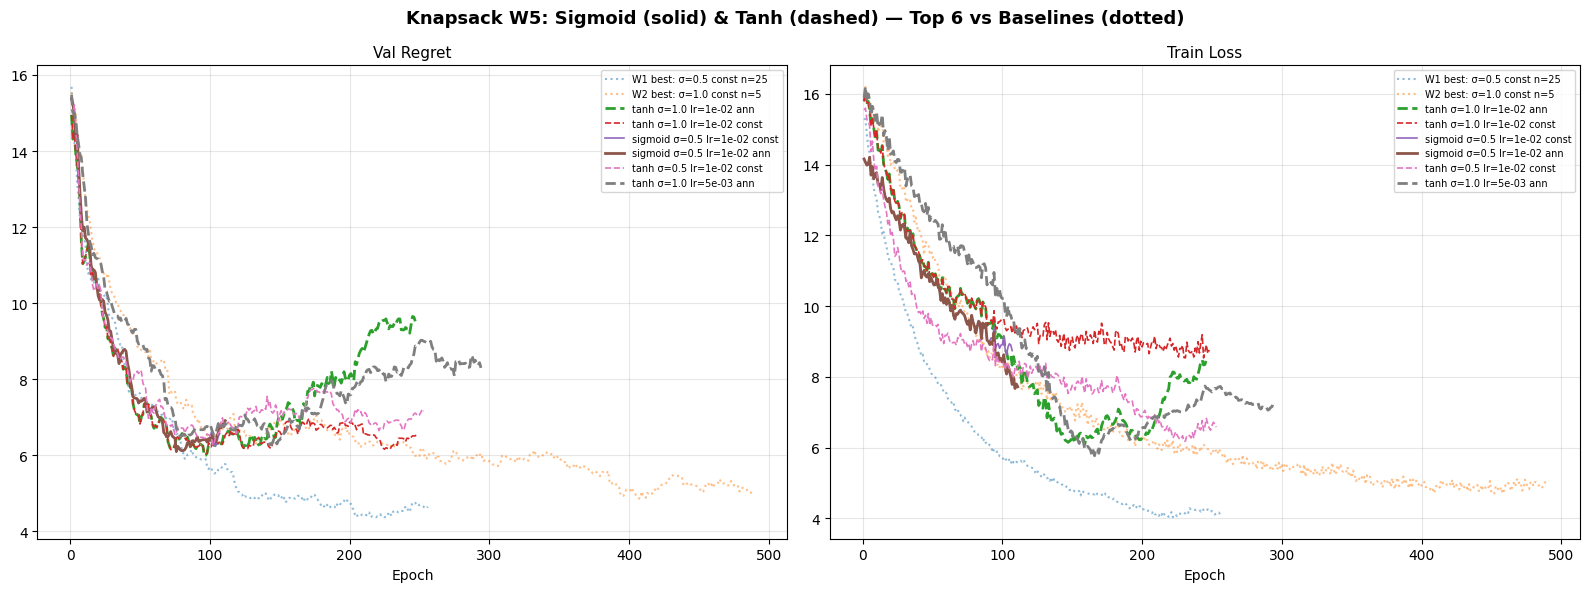


Knapsack W5 ranking:
   1. [tanh    anneal  ] tanh σ=1.0 lr=1e-02 ann                        val_regret=5.987 ★
   2. [tanh    constant] tanh σ=1.0 lr=1e-02 const                      val_regret=6.050
   3. [sigmoid constant] sigmoid σ=0.5 lr=1e-02 const                   val_regret=6.100
   4. [sigmoid anneal  ] sigmoid σ=0.5 lr=1e-02 ann                     val_regret=6.100
   5. [tanh    constant] tanh σ=0.5 lr=1e-02 const                      val_regret=6.263
   6. [tanh    anneal  ] tanh σ=1.0 lr=5e-03 ann                        val_regret=6.275
   7. [tanh    anneal  ] tanh σ=0.5 lr=1e-02 ann                        val_regret=6.312
   8. [sigmoid anneal  ] sigmoid σ=0.5 lr=5e-03 ann                     val_regret=6.513
   9. [tanh    anneal  ] tanh σ=0.5 lr=5e-03 ann                        val_regret=6.562
  10. [sigmoid constant] sigmoid σ=0.1 lr=1e-02 const                   val_regret=7.213
  11. [sigmoid constant] sigmoid σ=1.0 lr=1e-02 const                   val_regret=7.5

In [92]:
KN_W5_TOP_K = 6

# ── Collect traces ────────────────────────────────────────────────────
kn_w5_traces = []
for prefix, hp in KN_W5.items():
    tdf, vdf, ddf = read_full_traces("knapsack-gen", prefix)
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        sched_tag = "ann" if hp["schedule"] == "anneal" else "const"
        label = f"{hp['activation']} σ={hp['sigma']} lr={hp['lr']:.0e} {sched_tag}"
        kn_w5_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val,
            "prefix": prefix, "activation": hp["activation"],
            "schedule": hp["schedule"],
        })

# Reference baselines
kn_w5_baselines = []
for bl_prefix, bl_label in [
    ("sd1_s05_lr5e3", "W1 best: σ=0.5 const n=25"),
    ("sd1_kn_n5_s10_plw0_lr5e3", "W2 best: σ=1.0 const n=5"),
]:
    tdf, vdf, ddf = read_full_traces("knapsack-gen", bl_prefix)
    if tdf is not None:
        kn_w5_baselines.append({"label": bl_label, "train": tdf, "val": vdf, "diag": ddf,
                                 "best_val_regret": get_best_val_regret(vdf)})

print(f"KN W5: {len(kn_w5_traces)}/{len(KN_W5)} traces, {len(kn_w5_baselines)} baselines")

if len(kn_w5_traces) > 0:
    kn_w5_traces.sort(key=lambda t: t["best_val_regret"])
    kn_w5_sel = kn_w5_traces[:KN_W5_TOP_K]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plot_specs = [
        ("Val Regret", "val", "regret", axes[0]),
        ("Train Loss", "train", "loss", axes[1]),
    ]

    for title, source, col, ax in plot_specs:
        # Baselines (dotted)
        for i, bl in enumerate(kn_w5_baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ep_col = "epoch" if "epoch" in df_bl.columns else "epoch_num"
                ax.plot(df_bl[ep_col], df_bl[col],
                        color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1.5,
                        label=bl["label"])
        # W5 top configs — sigmoid solid, tanh dashed; anneal thick, const thin
        for i, tr in enumerate(kn_w5_sel):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ep_col = "epoch" if "epoch" in df_tr.columns else "epoch_num"
                ls = "-" if tr["activation"] == "sigmoid" else "--"
                lw = 2.0 if tr["schedule"] == "anneal" else 1.2
                ax.plot(df_tr[ep_col], df_tr[col],
                        color=f"C{len(kn_w5_baselines)+i}", linewidth=lw,
                        linestyle=ls, label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    fig.suptitle("Knapsack W5: Sigmoid (solid) & Tanh (dashed) — Top 6 vs Baselines (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Ranking
    print("\nKnapsack W5 ranking:")
    for i, tr in enumerate(kn_w5_traces):
        marker = " ★" if i == 0 else ""
        print(f"  {i+1:2d}. [{tr['activation']:7s} {tr['schedule']:8s}] "
              f"{tr['label']:45s}  val_regret={tr['best_val_regret']:.3f}{marker}")
    for bl in kn_w5_baselines:
        print(f"  baseline: {bl['label']:44s}  val_regret={bl['best_val_regret']:.3f}")
else:
    print("No KN W5 traces yet — re-run after jobs complete.")

### Knapsack W5 — SLURM Error Scanner

In [83]:
import glob

kn_w5_err_files = sorted(glob.glob("logs/slurm/pco_knapsack_sd1_kn_w5_*.err"))
print(f"Found {len(kn_w5_err_files)} Knapsack W5 error files\n")

kn_w5_problems = 0
for f in kn_w5_err_files:
    with open(f) as fh:
        content = fh.read()
    lines = content.strip().split("\n")
    error_lines = [l for l in lines
                   if any(kw in l.lower() for kw in ["error", "traceback", "exception", "killed", "oom"])
                   and "deprecat" not in l.lower() and "warning" not in l.lower()]
    if error_lines:
        kn_w5_problems += 1
        short_name = os.path.basename(f)
        print(f"⚠ {short_name}:")
        for l in error_lines[:5]:
            print(f"   {l.strip()}")
        print()

if kn_w5_problems == 0:
    print("✓ No errors detected in any Knapsack W5 SLURM logs.")

Found 24 Knapsack W5 error files

⚠ pco_knapsack_sd1_kn_w5_sig_s05_ann_lr1e2_32249224.err:
   slurmstepd: error: *** JOB 32249224 ON s1cmp012 CANCELLED AT 2026-03-03T18:43:25 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w5_sig_s10_ann_lr1e2_32249218.err:
   slurmstepd: error: *** JOB 32249218 ON s1cmp014 CANCELLED AT 2026-03-03T17:44:28 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w5_sig_s10_ann_lr5e3_32249213.err:
   slurmstepd: error: *** JOB 32249213 ON d1cmp050 CANCELLED AT 2026-03-03T17:45:06 DUE TO PREEMPTION ***

⚠ pco_knapsack_sd1_kn_w5_sig_s10_const_lr1e2_32249215.err:
   slurmstepd: error: *** JOB 32249215 ON s1cmp014 CANCELLED AT 2026-03-03T17:44:28 DUE TO PREEMPTION ***



## Energy Wave 1 — Sigmoid Activation + Sigma Sweep

**First dedicated energy experiments** with the SoftDecision approach. Energy uses
identity output activation by default (unbounded predictions), so sigmoid
in `SoftDecisionPerturbed` bounds the solver input to (0,1).

**Grid**: 3 lr × (3 constant σ + 1 anneal) = **12 experiments**

| σ | lr | Schedule |
|---|-----|----------|
| 0.5, 0.1, 0.05 | 0.05, 0.01, 0.005 | constant |
| 0.5 → 0.01 | 0.05, 0.01, 0.005 | anneal (200ep, no warmup) |

All: sigmoid activation, n_samples=1, n_epochs=300, patience=40 (default)

In [84]:
# ── Energy Wave 1: Registry ────────────────────────────────────────
EN_W1 = {}

EN_LRS = [(0.05, "lr5e2"), (0.01, "lr1e2"), (0.005, "lr5e3")]
EN_SIGMAS = [(0.5, "s05"), (0.1, "s01"), (0.05, "s005")]

# Constant-sigma experiments: 3 σ × 3 lr = 9
for sigma, s_tag in EN_SIGMAS:
    for lr_val, lr_tag in EN_LRS:
        prefix = f"sd1_en_w1_sig_{s_tag}_{lr_tag}"
        EN_W1[prefix] = dict(
            activation="sigmoid", sigma=sigma, lr=lr_val,
            schedule="constant", sigma_end=sigma,
        )

# Annealing experiments: σ=0.5→0.01, 3 lr = 3
for lr_val, lr_tag in EN_LRS:
    prefix = f"sd1_en_w1_sig_s05_ann_{lr_tag}"
    EN_W1[prefix] = dict(
        activation="sigmoid", sigma=0.5, lr=lr_val,
        schedule="anneal", sigma_end=0.01,
    )

print(f"Energy W1: {len(EN_W1)} experiments registered")
print(f"  constant: {sum(1 for v in EN_W1.values() if v['schedule']=='constant')}")
print(f"  anneal:   {sum(1 for v in EN_W1.values() if v['schedule']=='anneal')}")

Energy W1: 12 experiments registered
  constant: 9
  anneal:   3


### Energy W1 — Launch / Status

In [85]:
!bash shells/slurm/submit_energy_wave1.sh --dry-run 2>&1 | head -15 && echo "..." && bash shells/slurm/submit_energy_wave1.sh --dry-run 2>&1 | tail -8

Wave 1 — Energy: sigmoid + sigma sweep
3 lr × (3 constant + 1 anneal) = 12 experiments
Primary: preempt
Backup: hugheslab,gpu
n_epochs=300 | patience=40 (default)
*** DRY RUN ***
Skip completed: ON

[DRY RUN] pco_energy_sd1_en_w1_sig_s05_lr5e2
  CMD: python rethink_exp/main_results.py --problem=energy --opt_model perturb --method_path openpto/config/models/perturb_en_w1_sig_s05.yaml --prefix sd1_en_w1_sig_s05_lr5e2 --solver gurobi --n_epochs 300 --lr 0.05 --data_dir ./openpto/data/energy --gpu 0

[DRY RUN] pco_energy_sd1_en_w1_sig_s01_lr5e2
...
[DRY RUN] pco_energy_sd1_en_w1_sig_s05_ann_lr5e3
  CMD: python rethink_exp/main_results.py --problem=energy --opt_model perturb --method_path openpto/config/models/perturb_en_w1_sig_s05_ann.yaml --prefix sd1_en_w1_sig_s05_ann_lr5e3 --solver gurobi --n_epochs 300 --lr 0.005 --data_dir ./openpto/data/energy --gpu 0


Submitted: 12
Total SLURM jobs: 24
Dry run complete.


In [86]:
#!bash shells/slurm/submit_energy_wave1.sh

In [87]:
!squeue --me | grep pco_energy_sd1_en_w1 | wc -l && echo "EN-W1 energy jobs running" && squeue --me | grep pco_energy_sd1_en_w1 | head -10

0
EN-W1 energy jobs running


### Energy W1 — Collect Results

In [88]:
# ── Collect Energy W1 results ──────────────────────────────────────────
en_w1_rows = []
for prefix, hp in EN_W1.items():
    result = read_result("energy-energy", prefix)
    row = {
        "prefix": prefix,
        "activation": hp["activation"],
        "sigma": hp["sigma"],
        "lr": hp["lr"],
        "schedule": hp["schedule"],
        "sigma_end": hp["sigma_end"],
    }
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    en_w1_rows.append(row)

en_w1_df = pd.DataFrame(en_w1_rows)
en_w1_done = en_w1_df[en_w1_df["status"] == "done"]
en_w1_pending = en_w1_df[en_w1_df["status"] == "pending"]
print(f"Energy W1: {len(en_w1_done)}/{len(en_w1_df)} completed")

# Baseline: W1 sweep energy results (no activation)
en_baselines = {}
for sigma_tag in ["005", "01", "05"]:
    for lr_tag in ["lr1e3", "lr5e3", "lr1e2"]:
        bl_prefix = f"sd1_s{sigma_tag}_{lr_tag}"
        bl_result = read_result("energy-energy", bl_prefix)
        if bl_result:
            en_baselines[bl_prefix] = bl_result

if en_baselines:
    best_bl = min(en_baselines.items(), key=lambda x: x[1]["regret"])
    print(f"\nW1-sweep baseline best: {best_bl[0]}  regret={best_bl[1]['regret']:.3f}")

if len(en_w1_done) > 0:
    # Group by schedule
    for sched in ["constant", "anneal"]:
        sdf = en_w1_done[en_w1_done["schedule"] == sched].sort_values("regret")
        if len(sdf) > 0:
            print(f"\n{sched.upper()} ({len(sdf)} done):")
            for _, r in sdf.iterrows():
                flag = ""
                if en_baselines:
                    flag = " ★" if r["regret"] < best_bl[1]["regret"] else ""
                print(f"  σ={r['sigma']:<5} lr={r['lr']:.3f} σ_end={r['sigma_end']:<5}  "
                      f"regret={r['regret']:.3f}  obj={r['objective']:.3f}{flag}")

    # Overall best
    print(f"\nOverall EN-W1 best:")
    best = en_w1_done.sort_values("regret").iloc[0]
    print(f"  {best['prefix']}  regret={best['regret']:.3f}")
else:
    print(f"\nNo results yet. {len(en_w1_pending)} experiments pending.")

Energy W1: 0/12 completed

W1-sweep baseline best: sd1_s05_lr1e2  regret=42940.252

No results yet. 12 experiments pending.


### Energy W1 — Training Curves

In [89]:
EN_W1_TOP_K = 6

# ── Collect traces ────────────────────────────────────────────────────
en_w1_traces = []
for prefix, hp in EN_W1.items():
    tdf, vdf, ddf = read_full_traces("energy-energy", prefix)
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        sched_tag = "ann" if hp["schedule"] == "anneal" else "const"
        label = f"σ={hp['sigma']} lr={hp['lr']:.3f} {sched_tag}"
        en_w1_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val,
            "prefix": prefix, "schedule": hp["schedule"],
        })

# Reference baselines from W1 sweep (no activation)
en_w1_baselines = []
for bl_prefix, bl_label in [
    ("sd1_s05_lr1e2", "W1-sweep: σ=0.5 lr=1e-2 (no act)"),
    ("sd1_s01_lr5e3", "W1-sweep: σ=0.1 lr=5e-3 (no act)"),
]:
    tdf, vdf, ddf = read_full_traces("energy-energy", bl_prefix)
    if tdf is not None:
        en_w1_baselines.append({"label": bl_label, "train": tdf, "val": vdf, "diag": ddf,
                                 "best_val_regret": get_best_val_regret(vdf)})

print(f"EN W1: {len(en_w1_traces)}/{len(EN_W1)} traces, {len(en_w1_baselines)} baselines")

if len(en_w1_traces) > 0:
    en_w1_traces.sort(key=lambda t: t["best_val_regret"])
    en_w1_sel = en_w1_traces[:EN_W1_TOP_K]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plot_specs = [
        ("Val Regret", "val", "regret", axes[0]),
        ("Train Loss", "train", "loss", axes[1]),
    ]

    for title, source, col, ax in plot_specs:
        # Baselines (dotted)
        for i, bl in enumerate(en_w1_baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ep_col = "epoch" if "epoch" in df_bl.columns else "epoch_num"
                ax.plot(df_bl[ep_col], df_bl[col],
                        color=f"C{i}", alpha=0.5, linestyle=":", linewidth=1.5,
                        label=bl["label"])
        # EN-W1 top configs — anneal thick, const thin
        for i, tr in enumerate(en_w1_sel):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ep_col = "epoch" if "epoch" in df_tr.columns else "epoch_num"
                lw = 2.0 if tr["schedule"] == "anneal" else 1.2
                ls = "--" if tr["schedule"] == "anneal" else "-"
                ax.plot(df_tr[ep_col], df_tr[col],
                        color=f"C{len(en_w1_baselines)+i}", linewidth=lw,
                        linestyle=ls, label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    fig.suptitle("Energy W1: Sigmoid Activation — Top 6 vs Baselines (dotted)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Ranking
    print("\nEnergy W1 ranking:")
    for i, tr in enumerate(en_w1_traces):
        marker = " ★" if i == 0 else ""
        sched = "anneal " if tr["schedule"] == "anneal" else "const  "
        print(f"  {i+1:2d}. [{sched}] {tr['label']:35s}  val_regret={tr['best_val_regret']:.3f}{marker}")
    for bl in en_w1_baselines:
        print(f"  baseline: {bl['label']:34s}  val_regret={bl['best_val_regret']:.3f}")
else:
    print("No EN W1 traces yet — re-run after jobs complete.")

EN W1: 0/12 traces, 2 baselines
No EN W1 traces yet — re-run after jobs complete.


### Energy W1 — SLURM Error Scanner

In [90]:
import glob

en_w1_err_files = sorted(glob.glob("logs/slurm/pco_energy_sd1_en_w1_*.err"))
print(f"Found {len(en_w1_err_files)} Energy W1 error files\n")

en_w1_problems = 0
for f in en_w1_err_files:
    with open(f) as fh:
        content = fh.read()
    lines = content.strip().split("\n")
    error_lines = [l for l in lines
                   if any(kw in l.lower() for kw in ["error", "traceback", "exception", "killed", "oom"])
                   and "deprecat" not in l.lower() and "warning" not in l.lower()]
    if error_lines:
        en_w1_problems += 1
        short_name = os.path.basename(f)
        print(f"⚠ {short_name}:")
        for l in error_lines[:5]:
            print(f"   {l.strip()}")
        print()

if en_w1_problems == 0:
    print("✓ No errors detected in any Energy W1 SLURM logs.")

Found 12 Energy W1 error files

⚠ pco_energy_sd1_en_w1_sig_s005_lr1e2_32249294.err:
   Traceback (most recent call last):
   FileNotFoundError: [Errno 2] No such file or directory: './openpto/data/energy/energy/prices2013.dat'

⚠ pco_energy_sd1_en_w1_sig_s005_lr5e2_32249288.err:
   Traceback (most recent call last):
   FileNotFoundError: [Errno 2] No such file or directory: './openpto/data/energy/energy/prices2013.dat'

⚠ pco_energy_sd1_en_w1_sig_s005_lr5e3_32249300.err:
   Traceback (most recent call last):
   FileNotFoundError: [Errno 2] No such file or directory: './openpto/data/energy/energy/prices2013.dat'

⚠ pco_energy_sd1_en_w1_sig_s01_lr1e2_32249292.err:
   Traceback (most recent call last):
   FileNotFoundError: [Errno 2] No such file or directory: './openpto/data/energy/energy/prices2013.dat'

⚠ pco_energy_sd1_en_w1_sig_s01_lr5e2_32249285.err:
   Traceback (most recent call last):
   FileNotFoundError: [Errno 2] No such file or directory: './openpto/data/energy/energy/prices2

## Knapsack Wave 6 — Tanh n=50, σ∈{0.5, 1.0}, lr∈{1e-2, 5e-2}

**Rationale**: W5 showed tanh works well with bounded predictions. Now scale up
n_samples from 5→50 for better gradient estimates, and try a higher lr=5e-2.

**Grid**: 2 σ × 2 lr = **4 experiments**
- activation=tanh, n_samples=50, n_epochs=500, patience=150

In [ ]:
# ── Knapsack Wave 6: Registry ──────────────────────────────────────
KN_W6 = {}

for sigma, s_tag in [(0.5, "s05"), (1.0, "s10")]:
    for lr_val, lr_tag in [(0.01, "lr1e2"), (0.05, "lr5e2")]:
        prefix = f"sd1_kn_w6_tanh_{s_tag}_{lr_tag}"
        KN_W6[prefix] = dict(
            activation="tanh", sigma=sigma, lr=lr_val,
            n_samples=50, schedule="constant",
        )

print(f"Knapsack W6: {len(KN_W6)} experiments registered")
for p, hp in KN_W6.items():
    print(f"  {p}: σ={hp['sigma']} lr={hp['lr']} n={hp['n_samples']}")

### Knapsack W6 — Launch / Status

In [ ]:
!bash shells/slurm/submit_knapsack_wave6.sh --dry-run 2>&1

In [ ]:
#!bash shells/slurm/submit_knapsack_wave6.sh

In [ ]:
!squeue --me | grep pco_knapsack_sd1_kn_w6 | wc -l && echo "W6 knapsack jobs" && squeue --me | grep pco_knapsack_sd1_kn_w6

### Knapsack W6 — Collect Results

In [ ]:
# ── Collect Knapsack W6 results ────────────────────────────────────────
kn_w6_rows = []
for prefix, hp in KN_W6.items():
    result = read_result("knapsack-gen", prefix)
    row = {"prefix": prefix, **hp}
    if result:
        row.update(result)
        row["status"] = "done"
    else:
        row["status"] = "pending"
    kn_w6_rows.append(row)

kn_w6_df = pd.DataFrame(kn_w6_rows)
kn_w6_done = kn_w6_df[kn_w6_df["status"] == "done"]
kn_w6_pending = kn_w6_df[kn_w6_df["status"] == "pending"]
print(f"Knapsack W6: {len(kn_w6_done)}/{len(kn_w6_df)} completed")

w1_kn_best = 3.580   # sd1_s05_lr5e3 (n=25)

if len(kn_w6_done) > 0:
    print(f"\nBaseline W1 best (σ=0.5 n=25): {w1_kn_best:.3f}\n")
    for _, r in kn_w6_done.sort_values("regret").iterrows():
        flag = " ★" if r["regret"] < w1_kn_best else ""
        print(f"  σ={r['sigma']:<5} lr={r['lr']:.2f} n={r['n_samples']}  "
              f"regret={r['regret']:.3f}  obj={r['objective']:.3f}{flag}")
else:
    print(f"\nNo results yet. {len(kn_w6_pending)} experiments pending.")

### Knapsack W6 — Training Curves

In [ ]:
# ── Collect traces ────────────────────────────────────────────────────
kn_w6_traces = []
for prefix, hp in KN_W6.items():
    tdf, vdf, ddf = read_full_traces("knapsack-gen", prefix)
    if tdf is not None:
        best_val = get_best_val_regret(vdf)
        label = f"tanh σ={hp['sigma']} lr={hp['lr']:.2f} n=50"
        kn_w6_traces.append({
            "label": label, "train": tdf, "val": vdf, "diag": ddf,
            "best_val_regret": best_val, "prefix": prefix,
        })

# Baselines
kn_w6_baselines = []
for bl_prefix, bl_label in [
    ("sd1_s05_lr5e3", "W1 best: σ=0.5 n=25 lr=5e-3"),
    ("sd1_kn_n5_s10_plw0_lr5e3", "W2 best: σ=1.0 n=5 lr=5e-3"),
]:
    tdf, vdf, ddf = read_full_traces("knapsack-gen", bl_prefix)
    if tdf is not None:
        kn_w6_baselines.append({"label": bl_label, "train": tdf, "val": vdf, "diag": ddf,
                                 "best_val_regret": get_best_val_regret(vdf)})

print(f"KN W6: {len(kn_w6_traces)}/{len(KN_W6)} traces, {len(kn_w6_baselines)} baselines")

if len(kn_w6_traces) > 0:
    kn_w6_traces.sort(key=lambda t: t["best_val_regret"])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for title, source, col, ax in [
        ("Val Regret", "val", "regret", axes[0]),
        ("Train Loss", "train", "loss", axes[1]),
    ]:
        for i, bl in enumerate(kn_w6_baselines):
            df_bl = bl[source]
            if df_bl is not None and col in df_bl.columns:
                ep_col = "epoch" if "epoch" in df_bl.columns else "epoch_num"
                ax.plot(df_bl[ep_col], df_bl[col], color=f"C{i}", alpha=0.5,
                        linestyle=":", linewidth=1.5, label=bl["label"])
        for i, tr in enumerate(kn_w6_traces):
            df_tr = tr[source]
            if df_tr is not None and col in df_tr.columns:
                ep_col = "epoch" if "epoch" in df_tr.columns else "epoch_num"
                ax.plot(df_tr[ep_col], df_tr[col], color=f"C{len(kn_w6_baselines)+i}",
                        linewidth=2.0, label=tr["label"])
        ax.set_xlabel("Epoch"); ax.set_title(title, fontsize=11)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    fig.suptitle("Knapsack W6: Tanh n=50 vs Baselines (dotted)", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

    print("\nKnapsack W6 ranking:")
    for i, tr in enumerate(kn_w6_traces):
        marker = " ★" if i == 0 else ""
        print(f"  {i+1}. {tr['label']:35s}  val_regret={tr['best_val_regret']:.3f}{marker}")
    for bl in kn_w6_baselines:
        print(f"  baseline: {bl['label']:34s}  val_regret={bl['best_val_regret']:.3f}")
else:
    print("No KN W6 traces yet — re-run after jobs complete.")

### Knapsack W6 — SLURM Error Scanner

In [ ]:
import glob

kn_w6_err_files = sorted(glob.glob("logs/slurm/pco_knapsack_sd1_kn_w6_*.err"))
print(f"Found {len(kn_w6_err_files)} Knapsack W6 error files\n")

kn_w6_problems = 0
for f in kn_w6_err_files:
    with open(f) as fh:
        content = fh.read()
    lines = content.strip().split("\n")
    error_lines = [l for l in lines
                   if any(kw in l.lower() for kw in ["error", "traceback", "exception", "killed", "oom"])
                   and "deprecat" not in l.lower() and "warning" not in l.lower()]
    if error_lines:
        kn_w6_problems += 1
        short_name = os.path.basename(f)
        print(f"⚠ {short_name}:")
        for l in error_lines[:5]:
            print(f"   {l.strip()}")
        print()

if kn_w6_problems == 0:
    print("✓ No errors detected in any Knapsack W6 SLURM logs.")